In [ ]:
# Google drive mount
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Re-running the multimodal training cell after fixing find_patient_folder
# ---------------------------
# FULL MULTIMODAL TRAINING (DICOM + Clinical)
# Paste this cell into your notebook AFTER mounting Drive
# ---------------------------

import os
from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
from glob import glob
from tqdm import tqdm
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
# Google drive mount
from google.colab import drive
drive.mount('/content/drive')

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------------------------
# CONFIG - edit if needed
# ---------------------------
PROJECT_ROOT = Path("/content/drive/My Drive/tumor_pred_ai")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"

CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"

# Where the raw DICOM images are expected to live (usually a subfolder)
IMAGE_ROOT = RAW_DIR_CANDIDATE / "C4KC-KiTS" # Point to the manifest directory

Mounted at /content/drive


## Integrate Grad-CAM Visualization

### Subtask:
Add code to demonstrate generating and visualizing a Grad-CAM heatmap for a test image.

**Reasoning**:
Add code to generate and visualize a Grad-CAM heatmap for a test image using the `grad_cam_3d_approx` function. This requires selecting a test image, preparing the input for the Grad-CAM function, calling the function, and then visualizing the resulting heatmap, likely overlaid on the original image slice(s).

In [ ]:
# Ensure necessary variables are defined
if 'X_img_te' not in globals() or X_img_te is None or len(X_img_te) == 0:
    print("[warn] Test image data (X_img_te) is not available or empty. Cannot perform Grad-CAM visualization.")
else:
    # Select a test image (e.g., the first one)
    test_image = X_img_te[0] # Shape (H, W, D, 1)

    # Ensure the model is defined and loaded
    if 'model' not in globals() or model is None:
        print("[error] Model is not loaded. Cannot perform Grad-CAM.")
    else:
        # Find a suitable convolutional layer name for Grad-CAM
        # Try to find the last Conv3D layer before any pooling or dense layers in the image branch
        conv_layer_name = None
        # Iterate through layers in reverse to find a Conv3D layer
        for layer in reversed(model.layers):
            # Check if the layer is part of the image branch and is a Conv3D layer
            # This is a heuristic; a more robust approach would trace the graph from image_input
            if 'conv3d' in layer.name.lower() and 'image_input' in [inp.name for inp in layer.inbound_nodes[0].inbound_layers]:
                 conv_layer_name = layer.name
                 break
            elif 'conv3d' in layer.name.lower() and any('enc' in l.name for l in layer.inbound_nodes[0].inbound_layers):
                 # Heuristic for UNet-like encoder
                 conv_layer_name = layer.name
                 break
            elif 'conv3d' in layer.name.lower() and any('image' in l.name for l in layer.inbound_nodes[0].inbound_layers):
                 # General check for layers connected to image input
                 conv_layer_name = layer.name
                 break


        if conv_layer_name is None:
             print("[warn] Could not automatically find a suitable Conv3D layer for Grad-CAM. Please specify 'conv_layer_name'. Skipping Grad-CAM.")
        else:
            print(f"[info] Using layer '{conv_layer_name}' for Grad-CAM.")

            # Generate Grad-CAM heatmap
            # The model is a multitask model, so we need to specify which output to compute CAM for.
            # Let's compute CAM for the primary malignancy output ('out_malignancy').
            try:
                 output_names = [out.name.split('/')[0] for out in model.outputs]
                 pred_output_idx = output_names.index('out_malignancy')
                 print(f"[info] Computing Grad-CAM for output '{output_names[pred_output_idx]}' (index {pred_output_idx}).")

                 # Ensure test_image is float32 as expected by grad_cam_3d_approx
                 heatmap = grad_cam_3d_approx(model, test_image.astype(np.float32),
                                              pred_output_idx=pred_output_idx,
                                              conv_layer_name=conv_layer_name)

                 print(f"Generated heatmap with shape: {heatmap.shape}")

                 # Visualize the heatmap (example: show a few slices)
                 # The heatmap has the spatial dimensions of the convolutional layer output
                 # You might need to resize it to the original image dimensions for overlay

                 # Simple visualization: show central slices of heatmap and original image
                 H_img, W_img, D_img, _ = test_image.shape
                 H_cam, W_cam, D_cam = heatmap.shape

                 # Choose a few central slices from the heatmap
                 cam_slices_to_show = [D_cam // 4, D_cam // 2, 3 * D_cam // 4]

                 plt.figure(figsize=(12, 5))
                 for i, cam_slice_idx in enumerate(cam_slices_to_show):
                     plt.subplot(1, len(cam_slices_to_show), i + 1)
                     plt.imshow(heatmap[:, :, cam_slice_idx], cmap='jet', alpha=0.7)
                     plt.title(f'Heatmap Slice {cam_slice_idx}')
                     plt.axis('off')
                 plt.suptitle("Grad-CAM Heatmap Slices (Conv Layer Output Size)")
                 plt.show()

                 # Optional: Resize heatmap and overlay on original image slices
                 # Resizing requires interpolation and might not be perfect
                 # Let's resize to the original image depth for simplicity in this example
                 # Resizing each heatmap slice to match original HxW
                 resized_heatmaps = []
                 for d in range(D_cam):
                     # Resize each HxW slice of the heatmap
                     resized_slice = cv2.resize(heatmap[:,:,d], (W_img, H_img))
                     resized_heatmaps.append(resized_slice)

                 # Stack the resized slices to match original image depth (D_img)
                 # This requires interpolating along the depth dimension as well if D_cam != D_img
                 # A simpler approach is to select original image slices that correspond roughly
                 # to the selected heatmap slices.
                 # Let's select original image slices corresponding to cam_slices_to_show
                 img_slices_to_show = [int(idx * D_img / D_cam) for idx in cam_slices_to_show]


                 plt.figure(figsize=(12, 8))
                 for i, (img_slice_idx, cam_slice_idx) in enumerate(zip(img_slices_to_show, cam_slices_to_show)):
                      plt.subplot(2, len(cam_slices_to_show), i + 1)
                      # Display original image slice (remove the channel dim for imshow)
                      plt.imshow(test_image[:, :, img_slice_idx, 0], cmap='gray')
                      plt.title(f'Original Slice {img_slice_idx}')
                      plt.axis('off')

                      plt.subplot(2, len(cam_slices_to_show), i + 1 + len(cam_slices_to_show))
                      # Resize heatmap slice to original image slice size
                      resized_heatmap_slice = cv2.resize(heatmap[:, :, cam_slice_idx], (W_img, H_img))
                      # Overlay heatmap on original image slice
                      plt.imshow(test_image[:, :, img_slice_idx, 0], cmap='gray')
                      plt.imshow(resized_heatmap_slice, cmap='jet', alpha=0.5) # alpha for transparency
                      plt.title(f'Overlay Slice {img_slice_idx}')
                      plt.axis('off')

                 plt.suptitle("Grad-CAM Overlay on Original Image Slices")
                 plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
                 plt.show()


            except Exception as e:
                 print(f"[error] Failed to generate or visualize Grad-CAM: {e}")
                 import traceback
                 traceback.print_exc() # Print full traceback for debugging

[warn] Test image data (X_img_te) is not available or empty. Cannot perform Grad-CAM visualization.


In [ ]:
# Preprocessing / model hyperparams
TARGET_SHAPE = (128, 128, 64)    # (H, W, D) for volumes -> tune down if memory limited
CLIP_HU = (-1000, 400)           # HU clipping window
BATCH_SIZE = 10
EPOCHS = 12
RANDOM_SEED = 42
PROCESS_LIMIT = None  # set to an int for quick testing (e.g., 50), or None to process all
TARGET_LABEL = None   # set string to force a label (e.g., 'malignant'); otherwise auto-detect
VERBOSE = 1

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ---------------------------
# Sanity: files exist
# ---------------------------
if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}. Update CLINICAL_CSV path.")
if not META_CSV.exists():
    print("Warning: metadata CSV not found at expected path — continuing with clinical only.")

print("Clinical CSV:", CLINICAL_CSV)
print("Metadata CSV:", META_CSV if META_CSV.exists() else "(not found)")

# ---------------------------
# Load CSVs and merge
# ---------------------------
clinical_df = pd.read_csv(CLINICAL_CSV)
meta_df = pd.read_csv(META_CSV) if META_CSV.exists() else None

# Find patient id column heuristically in clinical_df
id_candidates = [c for c in clinical_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
if id_candidates:
    clinical_id_col = id_candidates[0]
else:
    clinical_id_col = clinical_df.columns[0]
print("Detected patient id column in clinical data:", clinical_id_col)

if meta_df is not None:
    # Find patient id column in meta_df
    meta_id_candidates = [c for c in meta_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    if meta_id_candidates:
        meta_id_col = meta_id_candidates[0]
    else:
        meta_id_col = meta_df.columns[0]
    print("Detected patient id column in metadata:", meta_id_col)

    # Merge using the detected id columns
    merged_df = pd.merge(clinical_df, meta_df, left_on=clinical_id_col, right_on=meta_id_col, how='left')
    join_key = clinical_id_col # Use the clinical id column as the primary join key for subsequent steps
    print("Merged clinical+meta shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Using clinical only. Shape:", merged_df.shape)

Clinical CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv
Metadata CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/metadata_m.csv
Detected patient id column in clinical data: patient_id
Detected patient id column in metadata: Subject ID
Merged clinical+meta shape: (40, 77)


In [ ]:


print(IMAGE_ROOT)


# ---------------------------
# Image root detection
# ---------------------------
# IMAGE_ROOT is now the base for paths in metadata
if not IMAGE_ROOT.exists():
    raise FileNotFoundError("IMAGE_ROOT does not exist. Set IMAGE_ROOT to the base directory for paths in metadata.")
print("Using IMAGE_ROOT as base for metadata paths:", IMAGE_ROOT)

# ---------------------------
# Helpers: find patient folder (using metadata path), load DICOM series, preprocess
# ---------------------------
def auto_path_col(df):
    for c in df.columns:
        cl = c.lower()
        if 'file' in cl and 'loc' in cl: return c
        if 'path' in cl: return c
        if 'series' in cl and 'path' in cl: return c
    return None

def find_patient_folder(patient_id, merged_df, image_root=IMAGE_ROOT, path_col='File Location'):
    """Finds the folder for a patient using the path from the merged dataframe."""
    # Find all rows for this patient (a patient might have multiple image series)
    rows = merged_df.loc[merged_df[join_key].astype(str) == str(patient_id)]
    if rows.empty:
        print(f"DEBUG: No metadata rows for patient {patient_id}")
        return None

    # Auto-detect path column if 'File Location' is not found
    if path_col not in merged_df.columns:
        alt = auto_path_col(merged_df)
        if not alt:
            print(f"DEBUG: No '{path_col}' or auto-detected path column found in metadata.")
            return None
        path_col = alt
        print(f"DEBUG: Using auto-detected path column: '{path_col}'")


    candidate_series_folders = []
    for index, row in rows.iterrows():
        # Get the file location from the row and construct the full path
        file_location = row.get(path_col, None) # Use .get for robustness
        if pd.isna(file_location): # Skip if File Location is missing
            print(f"DEBUG: Patient {patient_id} has NaN in path column for row {index}.")
            continue

        # Clean up path separator if needed and join with image_root
        # Assuming File Location is relative to IMAGE_ROOT and uses backslashes potentially
        # Normalize path separators and remove leading relative path components
        relative_path = str(file_location).replace('\\', os.sep).lstrip('./').lstrip('.\\')

        # Check if the relative path already includes the base folder name (like 'C4KC-KiTS')
        # If IMAGE_ROOT ends with the base folder name and relative_path starts with it, remove from relative_path
        image_root_name = image_root.name
        if image_root.name in relative_path.split(os.sep)[0]:
             # Remove the first component if it matches the image_root name
             relative_path = os.sep.join(relative_path.split(os.sep)[1:])
             print(f"DEBUG: Removed leading '{image_root_name}' from relative path. New relative_path: {relative_path}")


        # Construct the full path to the location specified in metadata (often a file)
        full_path_from_meta = image_root / relative_path
        # The folder containing the actual series DICOMs is likely the parent directory
        series_dir = full_path_from_meta.parent
        print(f"DEBUG: Checking patient {patient_id}, original loc='{file_location}', constructed potential series folder='{series_dir}'")


        # Verify the folder exists and contains DICOM files (recursively)
        if series_dir.exists() and series_dir.is_dir():
            # Use rglob to find any .dcm file within this folder or its subfolders
            if any(series_dir.rglob("*.dcm")):
                 print(f"DEBUG: Found DICOMs recursively in {series_dir}. Adding to candidates.")
                 candidate_series_folders.append(series_dir)
            else:
                 print(f"DEBUG: Directory {series_dir} exists but no .dcm files found recursively.")
        else:
            print(f"DEBUG: Constructed potential series folder {series_dir} does not exist or is not a directory.")


    # After checking all rows for the patient, select the best series folder from candidates
    # This might still need refinement if multiple series exist and a specific one is desired (e.g., non-contrast)
    # For now, return the first valid one found, or None if no valid series folders were found.
    if candidate_series_folders:
         print(f"DEBUG: Found {len(candidate_series_folders)} candidate series folders. Returning the first one.")
         return candidate_series_folders[0]
    else:
         print(f"DEBUG: No valid series folders found for patient {patient_id}.")
         return None


def load_dicom_series_to_volume(folder):
    folder = Path(folder)
    # Recursively find all .dcm files within the given folder and its subfolders
    files = sorted([str(p) for p in folder.rglob("*.dcm")])
    if not files:
        print(f"DEBUG: No .dcm files found recursively in folder {folder}")
        return None

    slices = []
    for f in files:
        # print(f"DEBUG: Attempting to read file: {f}") # Too verbose
        try:
            # Attempt to read DICOM file
            ds = pydicom.dcmread(f, stop_before_pixels=False, force=True)
            if not hasattr(ds, 'pixel_array'):
                 # print(f"DEBUG: File {f} has no pixel_array. Skipping.") # Too verbose
                 continue
            # Optionally filter out segmentation files if they are also .dcm
            # if ds.Modality != 'CT': # Adjust modality check as needed
            #     print(f"DEBUG: Skipping non-CT file {f} with Modality {ds.Modality}") # Too verbose
            #     continue
            slices.append(ds)
            # print(f"DEBUG: Successfully read file {f} with pixel_array.") # Too verbose
        except Exception as e:
            print(f"DEBUG: Error reading DICOM file {f}: {e}")
            continue
    if not slices:
        print(f"DEBUG: No valid DICOM slices loaded from folder {folder} after filtering.")
        return None

    # sort slices by z position if present
    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None
    slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in slices]).astype(np.int16)  # (Z,H,W)

    # HU conversion
    for i, s in enumerate(slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    # Spacing: (z, y, x) in mm
    try:
        ps = slices[0].PixelSpacing
        dz = float(getattr(slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)
    return vol, spacing


def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    # vol: (Z,H,W) -> resample to target voxel counts, then (H,W,D)
    if vol is None:
        return None # Handle cases where volume loading failed
    z, h, w = vol.shape
    th, tw, td = target_shape
    # basic voxel-count resample (kept simple to avoid heavy ITK deps)
    zoom_factors = (td / z, th / h, tw / w)
    vr = zoom(vol, zoom_factors, order=1)  # (td, th, tw)
    vr = np.transpose(vr, (1, 2, 0))        # (H,W,D)
    return vr


/content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS
Using IMAGE_ROOT as base for metadata paths: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS


In [ ]:
# Preprocessing / model hyperparams
from scipy.ndimage import zoom as ndzoom

import random
TARGET_SHAPE = (128, 128, 64)    # (H, W, D)
CLIP_HU = (-200, 300)
BATCH_SIZE = 10
EPOCHS = 12
RANDOM_SEED = 42
PROCESS_LIMIT = None
FORCE_TARGET_LABEL = None
VERBOSE = 1

USE_UNET_ENCODER   = True
ADD_LORA_ADAPTERS  = True
USE_RADIOMICS_BRANCH = True
MULTITASK = False

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# GPU niceties
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU memory growth not set:", e)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Using mixed precision.")
except Exception:
    pass

# ---------------------------
# Sanity: files exist
# ---------------------------
if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}.")
if not META_CSV.exists():
    print("Warning: metadata CSV not found — continuing with clinical only.")
if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

print("Clinical CSV:", CLINICAL_CSV)
print("Metadata CSV:", META_CSV if META_CSV.exists() else "(not found)")
print("Image base:", IMAGE_ROOT)


Using mixed precision.
Clinical CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv
Metadata CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/metadata_m.csv
Image base: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS


In [ ]:
# Preprocessing / model hyperparams
from scipy.ndimage import zoom as ndzoom

import random
TARGET_SHAPE = (128, 128, 64)    # (H, W, D)
CLIP_HU = (-200, 300)
BATCH_SIZE = 10
EPOCHS = 12
RANDOM_SEED = 42
PROCESS_LIMIT = None
FORCE_TARGET_LABEL = None
VERBOSE = 1

USE_UNET_ENCODER   = True
ADD_LORA_ADAPTERS  = True
USE_RADIOMICS_BRANCH = True
MULTITASK = False

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# GPU niceties
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU memory growth not set:", e)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Using mixed precision.")
except Exception:
    pass

# ---------------------------
# Sanity: files exist
# ---------------------------
if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}.")
if not META_CSV.exists():
    print("Warning: metadata CSV not found — continuing with clinical only.")
if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

print("Clinical CSV:", CLINICAL_CSV)
print("Metadata CSV:", META_CSV if META_CSV.exists() else "(not found)")
print("Image base:", IMAGE_ROOT)


Using mixed precision.
Clinical CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv
Metadata CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/metadata_m.csv
Image base: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS


In [ ]:
# ---------------------------
# Helpers: metadata path → series folder; DICOM IO
# ---------------------------
def auto_path_col(df):
    for c in df.columns:
        cl = c.lower()
        if 'file' in cl and 'loc' in cl: return c    # "File Location"
        if 'path' in cl: return c
        if 'series' in cl and 'path' in cl: return c
    return None

def _strip_to_after_kits(p: Path):
    parts = [*p.parts]
    if 'C4KC-KiTS' in parts:
        idx = parts.index('C4KC-KiTS')
        return Path(*parts[idx:])  # C4KC-KiTS/...
    return p

def find_patient_folder(patient_id, mdf, image_root=IMAGE_ROOT, default_path_col='File Location'):
    rows = mdf.loc[mdf[join_key].astype(str) == str(patient_id)]
    if rows.empty: return None
    path_col = default_path_col if default_path_col in mdf.columns else auto_path_col(mdf)
    if not path_col: return None

    candidates = []
    for _, row in rows.iterrows():
        loc = row.get(path_col, None)
        if pd.isna(loc): continue
        # normalize separators & trim any leading ".\"
        rel_raw = str(loc).replace('\\', '/').lstrip('./').lstrip('.\\')
        rel = _strip_to_after_kits(Path(rel_raw))   # ensure it starts at C4KC-KiTS/...
        full_file = (image_root.parent / rel) if rel.parts and rel.parts[0]=='C4KC-KiTS' else (image_root / rel)
        series_dir = full_file.parent  # file → series folder
        if series_dir.exists() and series_dir.is_dir():
            candidates.append(series_dir)

    if not candidates:
        return None
    # pick the series folder with most files
    best, best_count = None, -1
    for f in candidates:
        n = sum(1 for _ in f.glob("*.dcm"))
        if n == 0:
            n = sum(1 for x in f.glob("*") if x.is_file())
        if n > best_count:
            best, best_count = f, n
    return best

def load_dicom_series_to_volume(folder):
    folder = Path(folder)
    files = sorted([str(p) for p in folder.glob("*.dcm")])
    if not files:
        files = [str(p) for p in folder.glob("*") if p.is_file()]
    if not files:
        return None

    slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(f, stop_before_pixels=False, force=True)
            if not hasattr(ds, 'pixel_array'):
                continue
            slices.append(ds)
        except Exception:
            continue
    if not slices:
        return None

    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None
    slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in slices]).astype(np.int16)  # (Z,H,W)

    # HU conversion
    for i, s in enumerate(slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    # Spacing (z, y, x)
    try:
        ps = slices[0].PixelSpacing
        dz = float(getattr(slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)
    return vol, spacing

def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    z, h, w = vol.shape
    th, tw, td = target_shape
    zoom_factors = (td / z, th / h, tw / w)
    vr = ndzoom(vol, zoom_factors, order=1)  # (td,th,tw)
    vr = np.transpose(vr, (1, 2, 0))        # (H,W,D)
    return vr


In [ ]:
# Preprocessing / model hyperparams
from scipy.ndimage import zoom as ndzoom

import random
TARGET_SHAPE = (128, 128, 64)    # (H, W, D)
CLIP_HU = (-200, 300)
BATCH_SIZE = 10
EPOCHS = 12
RANDOM_SEED = 42
PROCESS_LIMIT = None
FORCE_TARGET_LABEL = None
VERBOSE = 1

USE_UNET_ENCODER   = True
ADD_LORA_ADAPTERS  = True
USE_RADIOMICS_BRANCH = True
MULTITASK = False

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# GPU niceties
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU memory growth not set:", e)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Using mixed precision.")
except Exception:
    pass

# ---------------------------
# Sanity: files exist
# ---------------------------
if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}.")
if not META_CSV.exists():
    print("Warning: metadata CSV not found — continuing with clinical only.")
if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

print("Clinical CSV:", CLINICAL_CSV)
print("Metadata CSV:", META_CSV if META_CSV.exists() else "(not found)")
print("Image base:", IMAGE_ROOT)


Using mixed precision.
Clinical CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv
Metadata CSV: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/metadata_m.csv
Image base: /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS


In [ ]:
# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, processed_patient_ids = [], [], [], []

# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []
'''
if radiomics_df is not None:
    rid = detect_id_col(radiomics_df)
    rad_cols = [c for c in radiomics_df.columns if c != rid]
    print("Radiomics feature count:", len(rad_cols))'''

# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load
    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    # Radiomics vector (if available)
    if rad_cols:
        if set(rad_cols).issubset(row.index):
            rv = row[rad_cols].astype(float).fillna(0).values
        else:
            rv = np.zeros(len(rad_cols), dtype=float)
    else:
        rv = None

    clin_list.append((num_vec, cat_vals, rv))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )

# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix (optional)
X_rad = None
if any(t[2] is not None for t in clin_list):
    X_rad = np.vstack([np.zeros_like(clin_list[0][2]) if t[2] is None else t[2] for t in clin_list])

# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)


TARGET_LABEL: malignant
Numeric features: ['age_at_nephrectomy', 'body_mass_index', 'pack_years', 'hospitalization', 'radiographic_size', 'pathologic_size', 'tumor_isup_grade', 'clavien_surgical_complications', 'estimated_blood_loss', 'operative_time'] ... +7
Categorical (max 8): ['gender', 'comorbidities__myocardial_infarction', 'comorbidities__congestive_heart_failure', 'comorbidities__peripheral_vascular_disease', 'comorbidities__cerebrovascular_disease', 'comorbidities__dementia', 'comorbidities__copd', 'comorbidities__connective_tissue_disease']


Patients: 100%|██████████| 11/11 [06:10<00:00, 33.64s/it]

Built dataset → images: (11, 128, 128, 64) | clinical: (11, 27) | labels: (11,) | radiomics: None


In [ ]:
# ---------------------------
# Splits (robust for tiny / imbalanced datasets)
# ---------------------------
import numpy as np
from collections import Counter, defaultdict
rng = np.random.RandomState(RANDOM_SEED)

def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)

    # Trivial cases
    if N == 0:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=int)
    if N == 1:
        return np.array([0]), np.array([], dtype=int), np.array([], dtype=int)
    if N == 2:
        # 1 train, 1 val (no test)
        idx = np.arange(2)
        rs.shuffle(idx)
        return idx[:1], idx[1:2], np.array([], dtype=int)

    # Per-class indices
    class_to_idx = defaultdict(list)
    for i, yi in enumerate(y):
        class_to_idx[int(yi)].append(i)

    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])

    # Target counts per class
    train_idx, val_idx, test_idx = [], [], []
    total_val_target  = int(round(N * val_frac))
    total_test_target = int(round(N * test_frac))

    # First pass: allocate per class with rounding and guardrails
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        # naive rounded targets
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val

        # Ensure at least 1 train per class if possible
        if n_train < 1:
            # steal from the larger of val/test if available
            if n_val > n_test and n_val > 0:
                n_val -= 1; n_train += 1
            elif n_test > 0:
                n_test -= 1; n_train += 1

        # Still pathological? force all to train
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0

        # Clip to bounds
        n_val  = max(0, min(n_val, n - n_train))
        n_test = max(0, min(n_test, n - n_train - n_val))

        # Slice indices
        t_slice = idxs[:n_test]
        v_slice = idxs[n_test:n_test + n_val]
        tr_slice = idxs[n_test + n_val:]

        test_idx.extend(t_slice)
        val_idx.extend(v_slice)
        train_idx.extend(tr_slice)

    # Second pass: global adjustments to hit at least 1 val/test when feasible
    # (only if there are enough total samples)
    rs.shuffle(train_idx)
    if len(val_idx) == 0 and len(train_idx) > 1:
        # move one from train to val
        val_idx.append(train_idx.pop())
    if len(test_idx) == 0 and len(train_idx) > 1:
        # move one from train to test
        test_idx.append(train_idx.pop())

    # If val/test are way over targets, push back to train (soft enforcement)
    def trim_to_target(src_list, target, dest_list):
        if target <= 0:
            return  # keep whatever was assigned if user asked 0
        excess = len(src_list) - target
        if excess > 0:
            rs.shuffle(src_list)
            # move extras back to train
            for _ in range(excess):
                dest_list.append(src_list.pop())

    trim_to_target(val_idx,  total_val_target,  train_idx)
    trim_to_target(test_idx, total_test_target, train_idx)

    # Final shuffle
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)

    return (np.array(train_idx, dtype=int),
            np.array(val_idx, dtype=int),
            np.array(test_idx, dtype=int))

# Use the smart splitter
train_idx, val_idx, test_idx = smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED)

def take(a, idx):
    if a is None: return None
    return a[idx]

X_img_tr, X_img_va, X_img_te   = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
if X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None
y_tr, y_va, y_te = y[train_idx], y[val_idx], y[test_idx]

print("Splits (train/val/test):", len(train_idx), len(val_idx), len(test_idx),
      "| radiomics:", "yes" if X_rad_scaled is not None else "no")

from collections import Counter
print("Class counts — train:", Counter(y_tr), " | val:", Counter(y_va), " | test:", Counter(y_te))


Splits (train/val/test): 7 2 2 | radiomics: no
Class counts — train: Counter({np.int64(1): 7})  | val: Counter({np.int64(1): 2})  | test: Counter({np.int64(1): 2})


In [ ]:
from tensorflow.keras.layers import (
    Conv3D, MaxPooling3D, GlobalAveragePooling3D, Flatten, Dense, Dropout,
    Input, concatenate, Activation, Add, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import metrics, regularizers

# ---------------------------
# Tunables
# ---------------------------
IMG_DROPOUT   = 0.30
CLIN_DROPOUT  = 0.30
RAD_DROPOUT   = 0.20
FUSED_DROPOUT = 0.30
L2_REG        = 1e-5          # light L2 to stabilize 3D convs
USE_GAP_IN_SIMPLE = True      # prefer GAP over Flatten to avoid huge tensors

# ---------------------------
# Blocks
# ---------------------------
def conv_block(x, f, name, use_bn=True, add_adapter=False):
    x = Conv3D(
        f, (3,3,3), padding='same', name=f"{name}_conv",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    if use_bn:
        x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation('relu', name=f"{name}_relu")(x)
    if add_adapter:
        # lightweight residual adapter (LoRA-style 1x1x1)
        a = Conv3D(
            f, (1,1,1), padding='same', name=f"{name}_lora",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(L2_REG)
        )(x)
        x = Add(name=f"{name}_add")([x, a])
    return x

def unet_encoder(x_in, filters=(16,32,64), add_adapters=False):
    x = x_in
    for i, f in enumerate(filters):
        x = conv_block(x, f, name=f"enc{i}_a", add_adapter=add_adapters)
        x = conv_block(x, f, name=f"enc{i}_b", add_adapter=add_adapters)
        x = MaxPooling3D((2,2,2), name=f"enc{i}_pool")(x)
    x = conv_block(x, filters[-1]*2, name="bottleneck_a", add_adapter=add_adapters)
    x = conv_block(x, filters[-1]*2, name="bottleneck_b", add_adapter=add_adapters)
    feats = GlobalAveragePooling3D(name="gap3d")(x)   # compact, scale-robust
    return feats

def simple_cnn_encoder(x_in):
    x = Conv3D(8,  (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x_in)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(16, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(32, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    if USE_GAP_IN_SIMPLE:
        x = GlobalAveragePooling3D()(x)
    else:
        x = Flatten()(x)
    x = Dense(128, activation='relu',
              kernel_initializer="he_normal",
              kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = Dropout(IMG_DROPOUT)(x)
    return x

# ---------------------------
# Model
# ---------------------------
# Expect TARGET_SHAPE as (H, W, D)
img_input = Input(shape=(TARGET_SHAPE[0], TARGET_SHAPE[1], TARGET_SHAPE[2], 1), name='image_input')
img_feats = (
    unet_encoder(img_input, filters=(16,32,64), add_adapters=ADD_LORA_ADAPTERS)
    if USE_UNET_ENCODER else
    simple_cnn_encoder(img_input)
)

clin_input = Input(shape=(X_clin_tr.shape[1],), name='clin_input')
c = Dense(64, activation='relu',
          kernel_initializer="he_normal")(clin_input)
c = Dropout(CLIN_DROPOUT)(c)
c = Dense(32, activation='relu',
          kernel_initializer="he_normal")(c)

inputs = [img_input, clin_input]

if X_rad_tr is not None:
    rad_input = Input(shape=(X_rad_tr.shape[1],), name='rad_input')
    r = Dense(128, activation='relu', name='rad_dense1',
              kernel_initializer="he_normal")(rad_input)
    r = Dropout(RAD_DROPOUT)(r)
    r = Dense(64, activation='relu', name='rad_dense2',
              kernel_initializer="he_normal")(r)
    inputs.append(rad_input)
    fused = concatenate([img_feats, c, r], name='fusion')
else:
    fused = concatenate([img_feats, c], name='fusion')

m = Dense(64, activation='relu', name='fused_dense1',
          kernel_initializer="he_normal")(fused)
m = Dropout(FUSED_DROPOUT)(m)

# sigmoid output (probability); keep dtype float32 for stable metrics under mixed precision
primary_out = Dense(1, activation='sigmoid', dtype='float32', name='out_malignancy')(m)

model = Model(inputs=inputs, outputs=[primary_out])

# Compile with AUC + accuracy for better monitoring
model.compile(
    optimizer=Adam(1e-4),
    loss={'out_malignancy': 'binary_crossentropy'},
    metrics={'out_malignancy': [metrics.AUC(name='auc'), 'accuracy']}
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_conv         │ (None, 128, 128,  │        448 │ image_input[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_bn           │ (None, 128, 128,  │         64 │ enc0_a_conv[0][0] │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_relu         │ (None, 128, 128,  │          0 │ enc0_a_bn[0][0]   │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_lora         │ (None, 128, 128,  │        272 │ enc0_a_relu[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_add (Add)    │ (None, 128, 128,  │          0 │ enc0_a_relu[0][0… │
│                     │ 64, 16)           │            │ enc0_a_lora[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_conv         │ (None, 128, 128,  │      6,928 │ enc0_a_add[0][0]  │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_bn           │ (None, 128, 128,  │         64 │ enc0_b_conv[0][0] │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_relu         │ (None, 128, 128,  │          0 │ enc0_b_bn[0][0]   │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_lora         │ (None, 128, 128,  │        272 │ enc0_b_relu[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_add (Add)    │ (None, 128, 128,  │          0 │ enc0_b_relu[0][0… │
│                     │ 64, 16)           │            │ enc0_b_lora[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_pool           │ (None, 64, 64,    │          0 │ enc0_b_add[0][0]  │
│ (MaxPooling3D)      │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_conv         │ (None, 64, 64,    │     13,856 │ enc0_pool[0][0]   │
│ (Conv3D)            │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_bn           │ (None, 64, 64,    │        128 │ enc1_a_conv[0][0] │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_relu         │ (None, 64, 64,    │          0 │ enc1_a_bn[0][0]   │
│ (Activation)        │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_lora         │ (None, 64, 64,    │      1,056 │ enc1_a_relu[0][0] │
│ (Conv3D)            │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_add (Add)    │ (None, 64, 64,    │          0 │ enc1_a_relu[0][0

 Total params: 938,897 (3.58 MB)

 Trainable params: 937,937 (3.58 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ---------------------------
# Training (robust, named inputs, no double-weighting)
# ---------------------------
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import numpy as np

def make_sample_weights(y_vec):
    y_vec = np.asarray(y_vec).astype(int)
    cls = np.unique(y_vec)
    if len(cls) < 2:
        print("[warn] Only one class found in training; using uniform weights = 1.0")
        return np.ones_like(y_vec, dtype="float32")
    counts = Counter(y_vec.tolist())
    total = len(y_vec)
    weights = {c: total / (len(cls) * counts[c]) for c in cls}
    print("Class counts (train):", dict(counts), "| sample weights:", weights)
    return np.array([weights[int(t)] for t in y_vec], dtype="float32")

# Per-sample weights (use sample_weight; avoid class_weight to not double-weight)
sw_tr = make_sample_weights(y_tr)
has_val = len(y_va) > 0
sw_va = make_sample_weights(y_va) if has_val else None

# Named inputs (matches your model summary)
train_inputs = {"image_input": X_img_tr, "clin_input": X_clin_tr}
if 'rad_input' in [inp.name for inp in model.inputs] and (X_rad_tr is not None):
    train_inputs["rad_input"] = X_rad_tr

y_tr_arr = y_tr.astype("float32")

if has_val:
    val_inputs = {"image_input": X_img_va, "clin_input": X_clin_va}
    if "rad_input" in train_inputs and (X_rad_va is not None):
        val_inputs["rad_input"] = X_rad_va
    y_va_arr = y_va.astype("float32")

# Prefer monitoring val_auc if compiled; else val_loss/loss
available = getattr(model, "metrics_names", [])
metr_join = " ".join(available).lower()
monitor_key = "val_auc" if (has_val and "auc" in metr_join) else ("val_loss" if has_val else "loss")

out_dir = PROJECT_ROOT / "models"
out_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(monitor=monitor_key, patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor=monitor_key, factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(filepath=str(out_dir / "best_multimodal.keras"),
                    monitor=monitor_key, save_best_only=True, save_weights_only=False)
]

# Warm-build variables
_ = model.predict({k: v[:1] for k, v in train_inputs.items()}, verbose=0)

# Batch/steps safety
batch_size = max(1, min(BATCH_SIZE, len(y_tr_arr)))
steps_per_epoch = max(1, int(np.ceil(len(y_tr_arr) / batch_size)))
if has_val:
    val_batch = max(1, min(BATCH_SIZE, len(y_va_arr)))
    val_steps = max(1, int(np.ceil(len(y_va_arr) / val_batch)))
else:
    val_steps = None

def _fit(run_eagerly=False):
    if run_eagerly:
        model.compile(optimizer=Adam(1e-4),
                      loss={'out_malignancy': 'binary_crossentropy'},
                      metrics={'out_malignancy': ['accuracy']},
                      run_eagerly=True)
    if has_val:
        return model.fit(
            x=train_inputs, y=y_tr_arr,
            sample_weight=sw_tr,                      # use sample weights only
            validation_data=(val_inputs, y_va_arr, sw_va),
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            validation_steps=val_steps,
            callbacks=callbacks,
            verbose=VERBOSE,
            class_weight=None                         # avoid double-weighting
        )
    else:
        print("[warn] No validation set found — training without validation.")
        return model.fit(
            x=train_inputs, y=y_tr_arr,
            sample_weight=sw_tr,
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            callbacks=callbacks,
            verbose=VERBOSE,
            class_weight=None
        )

try:
    history = _fit(run_eagerly=False)
except Exception as e:
    print("[info] Caught TF variable-creation error; retrying in eager mode. Error was:", repr(e))
    history = _fit(run_eagerly=True)


[warn] Only one class found in training; using uniform weights = 1.0
[warn] Only one class found in training; using uniform weights = 1.0
Epoch 1/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 88s 88s/step - accuracy: 0.8571 - auc: 0.0000e+00 - loss: 0.2711 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0192 - learning_rate: 1.0000e-04
Epoch 2/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.1905 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0192 - learning_rate: 1.0000e-04
Epoch 3/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.1157 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0192 - learning_rate: 1.0000e-04
Epoch 4/12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.0761
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.0761 - val_accura


Validation classification report:
              precision    recall  f1-score   support

         1.0     1.0000    1.0000    1.0000         2

    accuracy                         1.0000         2
   macro avg     1.0000    1.0000    1.0000         2
weighted avg     1.0000    1.0000    1.0000         2

Validation ROC-AUC: nan
Validation PR-AUC : 1.0
Confusion matrix:
 [[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


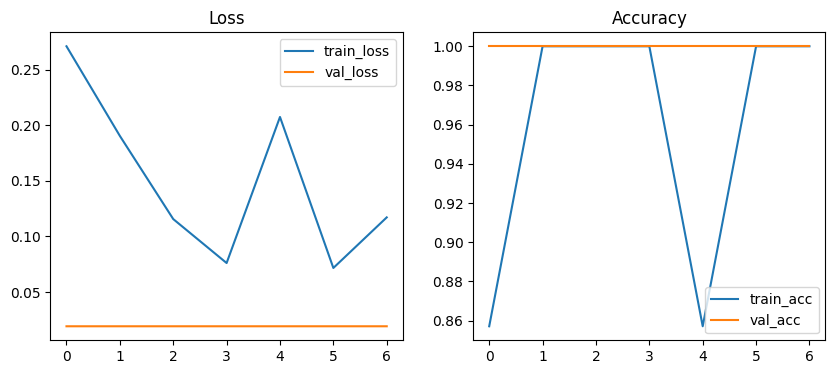

In [ ]:
# ---------------------------
# Validation evaluation (robust)
# ---------------------------
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

# 1) Predict probs (single-output model returns a single array; no [0] indexing)
val_prob = model.predict(val_inputs, verbose=0).ravel()

# 2) Ensure target length matches predictions (guard tiny/off-by-one issues)
yt = y_va.astype(np.float32).ravel()
if val_prob.shape[0] != yt.shape[0]:
    n = min(val_prob.shape[0], yt.shape[0])
    print(f"[warn] Length mismatch: preds={val_prob.shape[0]} vs y={yt.shape[0]} → truncating to {n}")
    val_prob = val_prob[:n]
    yt = yt[:n]

# 3) Threshold at 0.5 → hard labels
val_pred = (val_prob > 0.5).astype(int)

# 4) Reports
print("\nValidation classification report:")
print(classification_report(yt, val_pred, digits=4))
try:
    print("Validation ROC-AUC:", roc_auc_score(yt, val_prob))
    print("Validation PR-AUC :", average_precision_score(yt, val_prob))
except Exception as e:
    print("AUC metrics error:", e)

print("Confusion matrix:\n", confusion_matrix(yt, val_pred))

# 5) Plot training curves with dynamic key detection
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

# Find accuracy-like keys automatically (handles namespaced metrics)
acc_key = next((k for k in history.history.keys()
                if k.endswith('accuracy') and not k.startswith('val_')), None)
vacc_key = f"val_{acc_key}" if acc_key and f"val_{acc_key}" in history.history else None

plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
if loss:     plt.plot(loss, label='train_loss')
if val_loss: plt.plot(val_loss, label='val_loss')
plt.legend(); plt.title("Loss")

# Accuracy (if present)
plt.subplot(1,2,2)
if acc_key:   plt.plot(history.history[acc_key], label='train_acc')
if vacc_key:  plt.plot(history.history[vacc_key], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.show()


In [ ]:
import numpy as np
from skimage.filters import threshold_otsu
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import marching_cubes, label

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo: hi = lo + 1  # guard
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol, hu_range=(-200, 300)):
    """Very rough mask: Otsu on HU-clipped volume. Replace with your seg when ready."""
    v8 = _hu_to_uint8(vol, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1  # fallback tiny threshold if Otsu fails
    m = (v8 >= t).astype(np.uint8)
    # keep largest 3D component
    lab = label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    largest = counts[1:].argmax() + 1
    return (lab == largest)

def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    # If the slice is constant, graycomatrix can be degenerate; handle it
    if slice_u8.max() == slice_u8.min():
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    g = graycomatrix(slice_u8, distances=distances, angles=angles,
                     levels=256, symmetric=True, normed=True)
    feats = {
        'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
        'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
        'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
        'glcm_energy':     float(graycoprops(g, 'energy').mean()),
        'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
        'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
    }
    return feats

def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (H,W,D) float HU
    spacing: (dy, dx, dz) for (H,W,D). Provide your real voxel spacing if available.
    mask: optional boolean (H,W,D). If None, uses quick Otsu.
    Returns dict of intensity, simple shape, and texture features.
    """
    vol = np.asarray(vol, dtype=np.float32)
    if mask is None:
        mask = _quick_mask(vol)
    else:
        mask = mask.astype(bool)

    # intensity statistics inside mask
    vox = vol[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        z = (vox - mu) / (sd + 1e-6)
        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(np.mean(z**3)),
            'int_kurt': float(np.mean(z**4)),
        }

    # simple 3D shape (volume, surface, sphericity)
    try:
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception:
        area = 0.0
    vol_mm3 = float(mask.sum() * float(np.prod(spacing)))
    sphericity = float((np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)) if (area > 0 and vol_mm3 > 0) else 0.0
    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    # texture on a few central slices
    v8 = _hu_to_uint8(vol)
    D = vol.shape[2]
    mids = [max(0, D//4), max(0, D//2), max(0, 3*D//4)]
    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k]
        if np.count_nonzero(msl) < 25:
            continue
        glcms.append(_glcm_feats(sl))
    if glcms:
        tex = {k: float(np.mean([d[k] for d in glcms])) for k in glcms[0].keys()}
    else:
        tex = {k: 0.0 for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}

    feats = {**stats, **shape, **tex}
    return feats


In [ ]:
# ---------------------------
# Test evaluation (robust / tiny-safe, named inputs, forced labels)
# ---------------------------
import numpy as np
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, f1_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss
)
# Import necessary libraries for survival evaluation
try:
    from lifelines.utils import concordance_index
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False
    print("[warn] lifelines not installed, cannot compute concordance index. Install lifelines.")


ALL_LABELS = [0, 1]

def _none_or_empty(arr):
    return (arr is None) or (getattr(arr, "shape", (0,))[0] == 0)

# 0) Pick decision threshold (reuse from validation if available)
#    Expect you may have set: best_thresh from validation code. If not, default to 0.5.
threshold = 0.5
if 'best_thresh' in globals():
    try:
        t = float(best_thresh)
        if 0.0 < t < 1.0:
            threshold = t
            print(f"[info] Using validation-derived threshold: {threshold:.3f}")
    except Exception:
        pass

# 1) Quick existence checks for *all* relevant test sets
has_img_te = not _none_or_empty(X_img_te)
has_clin_te = not _none_or_empty(X_clin_te)
has_rad_te = not _none_or_empty(X_rad_te) and ('USE_RADIOMICS_BRANCH' in globals() and USE_RADIOMICS_BRANCH) # Check flag and data
has_y_te = not _none_or_empty(y_te) # Primary label
has_subtype_te = not _none_or_empty(y_subtype_te) if 'y_subtype_te' in globals() else False
has_kidney_decline_te = not _none_or_empty(y_kidney_decline_te) if 'y_kidney_decline_te' in globals() else False
has_survival_time_te = not _none_or_empty(y_survival_time_te) if 'y_survival_time_te' in globals() else False
has_survival_event_te = not _none_or_empty(y_survival_event_te) if 'y_survival_event_te' in globals() else False # Need both for C-index


if not (has_img_te and has_clin_te and has_y_te):
    print("\n[info] Required test sets (image, clinical, primary label) are not available or empty. Skipping test evaluation.")
else:
    # 2) Build inputs BY NAME to avoid mis-ordering
    test_inputs = {"image_input": X_img_te, "clin_input": X_clin_te}
    # Check if model expects rad_input AND data is available
    if any(inp.name == "rad_input" for inp in model.inputs) and has_rad_te:
         test_inputs["rad_input"] = X_rad_te
         print("[info] Including radiomics input for test evaluation.")
    elif any(inp.name == "rad_input" for inp in model.inputs):
         print("[warn] Model expects 'rad_input' but X_rad_te is not available or empty. Skipping radiomics input.")


    # 3) Test batch size safe for small N
    bs_test = max(1, min(BATCH_SIZE if 'BATCH_SIZE' in globals() else 1, len(y_te)))

    # 4) Predict probabilities/outputs for all heads
    # model.predict returns a list of arrays if multi-output
    predictions = model.predict(test_inputs, verbose=0, batch_size=bs_test)

    # If the model has only one output, predictions is an array, wrap it in a list
    if not isinstance(predictions, list):
        predictions = [predictions]

    # Find the output indices based on model output names
    output_names = [out.name.split('/')[0] for out in model.outputs]
    try:
        malignancy_idx = output_names.index('out_malignancy')
    except ValueError:
        malignancy_idx = None
        print("[warn] 'out_malignancy' not found in model outputs.")

    try:
        subtype_idx = output_names.index('out_subtype')
    except ValueError:
        subtype_idx = None
        print("[warn] 'out_subtype' not found in model outputs.")

    try:
        kidney_decline_idx = output_names.index('out_kidney_decline')
    except ValueError:
        kidney_decline_idx = None
        print("[warn] 'out_kidney_decline' not found in model outputs.")

    try:
        survival_idx = output_names.index('out_survival')
    except ValueError:
        survival_idx = None
        print("[warn] 'out_survival' not found in model outputs.")


    # Extract predictions for each head
    probs = predictions[malignancy_idx].ravel().astype("float32") if malignancy_idx is not None else None
    # For classification heads, predictions are probabilities (softmax/sigmoid)
    # For regression (survival), predictions are raw values (linear)

    # Ensure target lengths match predictions where predictions exist
    # Use the length of the primary label test set as the reference size
    reference_size = len(y_te) if has_y_te else 0

    def align_target_and_pred(target_arr, pred_arr, name):
         if target_arr is None: return None, None # Only need target here
         target_arr_flat = np.asarray(target_arr).ravel() if target_arr.ndim > 1 and target_arr.shape[1] == 1 else np.asarray(target_arr) # Keep one-hot as 2D

         # If pred_arr is None, we only align the target based on reference_size
         if pred_arr is None:
             if target_arr_flat.shape[0] != reference_size:
                 print(f"[warn] Mismatch in {name} target length ({target_arr_flat.shape[0]}) vs reference ({reference_size}). Truncating target.")
                 return target_arr_flat[:reference_size], None
             return target_arr_flat, None

         # If pred_arr exists, align both target and pred based on the minimum size
         pred_arr_flat = np.asarray(pred_arr).ravel() if pred_arr.ndim > 1 and pred_arr.shape[1] == 1 else np.asarray(pred_arr) # Keep one-hot as 2D
         min_size = min(target_arr_flat.shape[0], pred_arr_flat.shape[0])

         if target_arr_flat.shape[0] != min_size or pred_arr_flat.shape[0] != min_size:
              print(f"[warn] Mismatch in {name} length (target={target_arr_flat.shape[0]}, pred={pred_arr_flat.shape[0]}). Truncating to {min_size}.")
              if target_arr_flat.ndim > 1: target_arr_aligned = target_arr_flat[:min_size, :]
              else: target_arr_aligned = target_arr_flat[:min_size]

              if pred_arr_flat.ndim > 1: pred_arr_aligned = pred_arr_flat[:min_size, :]
              else: pred_arr_aligned = pred_arr_flat[:min_size]

              return target_arr_aligned, pred_arr_aligned
         return target_arr_flat, pred_arr_flat


    y_te_eval, probs = align_target_and_pred(y_te, probs, 'malignancy') if has_y_te and probs is not None else (y_te, probs)

    subtype_probs = predictions[subtype_idx] if subtype_idx is not None else None # Keep as 2D for multiclass
    y_subtype_te_eval, subtype_probs = align_target_and_pred(y_subtype_te, subtype_probs, 'subtype') if has_subtype_te and subtype_probs is not None else (y_subtype_te, subtype_probs)

    kidney_decline_probs = predictions[kidney_decline_idx] if kidney_decline_idx is not None else None # Keep as 2D for binary one-hot
    y_kidney_decline_te_eval, kidney_decline_probs = align_target_and_pred(y_kidney_decline_te, kidney_decline_probs, 'kidney_decline') if has_kidney_decline_te and kidney_decline_probs is not None else (y_kidney_decline_te, kidney_decline_probs)

    survival_scores = predictions[survival_idx].ravel().astype("float32") if survival_idx is not None else None # Regression output is 1D
    y_survival_time_te_eval, survival_scores = align_target_and_pred(y_survival_time_te, survival_scores, 'survival_time') if has_survival_time_te and survival_scores is not None else (y_survival_time_te, survival_scores)
    y_survival_event_te_eval, _ = align_target_and_pred(y_survival_event_te, None, 'survival_event') if has_survival_event_te else (None, None) # Survival event is a target only


    # 6) Hard predictions at threshold (default 0.5) for malignancy
    if probs is not None and y_te_eval is not None and len(y_te_eval) > 0:
        probs = np.clip(probs, 1e-7, 1 - 1e-7)  # numerical safety for AUC/Brier
        preds = (probs >= threshold).astype(int)

        # 7) Reports (force label space to [0,1] so shapes are consistent) for malignancy
        print("\n--- Malignancy Evaluation (Test Set) ---")
        print("\nTest classification report (labels=[0,1]):")
        try:
            # Ensure both true and pred have at least one sample before reporting
            if len(y_te_eval) > 0 and len(preds) > 0:
                print(classification_report(y_te_eval, preds, labels=ALL_LABELS, digits=4, zero_division=0))
            else:
                print("[info] Not enough samples for classification report.")
        except Exception as e:
            print("[warn] classification_report error for malignancy:", e)

        # Extra useful metrics for malignancy
        try:
            if len(y_te_eval) > 0 and len(preds) > 0:
                ba = balanced_accuracy_score(y_te_eval, preds)
                f1 = f1_score(y_te_eval, preds, zero_division=0)
                # MCC requires at least two classes in y_true
                mcc = matthews_corrcoef(y_te_eval, preds) if len(np.unique(y_te_eval)) > 1 else float('nan')
                bs  = brier_score_loss(y_te_eval, probs) if len(np.unique(y_te_eval)) > 0 else float('nan')
                print(f"Balanced Accuracy: {ba:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f} | Brier: {bs:.4f}")
            else:
                print("[info] Not enough samples for extra metrics.")
        except Exception as e:
            print("Extra metrics error for malignancy:", e)

        # 8) ROC-AUC & PR-AUC (need both classes / positives) for malignancy
        try:
            if len(np.unique(y_te_eval)) < 2:
                print("Test ROC-AUC (Malignancy): undefined (only one class present in y_te).")
            elif len(y_te_eval) > 0 and len(probs) > 0:
                print("Test ROC-AUC (Malignancy):", float(roc_auc_score(y_te_eval, probs)))
            else:
                print("[info] Not enough samples for ROC-AUC.")

        except Exception as e:
            print("Test ROC-AUC error for malignancy:", e)

        try:
            if np.sum(y_te_eval) == 0:
                print("Test PR-AUC (Malignancy): undefined (no positive labels in y_te).")
            elif len(y_te_eval) > 0 and len(probs) > 0:
                print("Test PR-AUC (Malignancy):", float(average_precision_score(y_te_eval, probs)))
            else:
                print("[info] Not enough samples for PR-AUC.")
        except Exception as e:
            print("Test PR-AUC error for malignancy:", e)

        # 9) Confusion matrix — always 2x2 with forced labels for malignancy
        try:
            if len(y_te_eval) > 0 and len(preds) > 0:
                 print("Confusion matrix (Malignancy, labels=[0,1]):\n", confusion_matrix(y_te_eval, preds, labels=ALL_LABELS))
            else:
                 print("[info] Not enough samples for confusion matrix.")
        except Exception as e:
            print("Confusion matrix error for malignancy:", e)
    else:
        print("\n--- Malignancy Evaluation Skipped (No data or predictions) ---")


    # --- Evaluate other tasks ---

    # Subtype Evaluation (Multiclass)
    if subtype_idx is not None and y_subtype_te_eval is not None and subtype_probs is not None and len(y_subtype_te_eval) > 0:
        print("\n--- Subtype Evaluation (Test Set) ---")
        # For multiclass, classification_report handles it directly with one-hot or integer targets
        # Assuming y_subtype_te_eval is one-hot encoded or integer labels
        try:
             # Use integer labels for classification report if available
             if y_subtype_te_eval.ndim > 1:
                  subtype_true_labels = np.argmax(y_subtype_te_eval, axis=1)
             else:
                  subtype_true_labels = y_subtype_te_eval # Assume integer labels

             subtype_pred_labels = np.argmax(subtype_probs, axis=1)

             print("\nTest classification report (Subtype):")
             # Attempt to use original class names if available
             if 'subtype_classes_list' in globals() and subtype_classes_list is not None:
                 target_names = subtype_classes_list
                 # Ensure predicted labels are within the range of target_names
                 unique_preds = np.unique(subtype_pred_labels)
                 if np.max(unique_preds) >= len(target_names):
                     print(f"[warn] Predicted subtype labels ({unique_preds}) out of range for available target_names ({len(target_names)}). Using integer labels for report.")
                     target_names = None # Fallback to integer labels

                 # Filter true labels based on available target_names if necessary (e.g., handle 'Unknown')
                 if target_names:
                     valid_true_indices = np.isin(subtype_true_labels, np.arange(len(target_names)))
                     if np.any(~valid_true_indices):
                         print(f"[warn] True subtype labels contain values outside of learned classes. Filtering {np.sum(~valid_true_indices)} samples for report.")
                         subtype_true_labels_filtered = subtype_true_labels[valid_true_indices]
                         subtype_pred_labels_filtered = subtype_pred_labels[valid_true_indices]
                     else:
                         subtype_true_labels_filtered = subtype_true_labels
                         subtype_pred_labels_filtered = subtype_pred_labels


                     print(classification_report(subtype_true_labels_filtered, subtype_pred_labels_filtered, target_names=target_names, zero_division=0))
                 else:
                     print(classification_report(subtype_true_labels, subtype_pred_labels, zero_division=0))

             else:
                 print(classification_report(subtype_true_labels, subtype_pred_labels, zero_division=0))

        except Exception as e:
            print("[warn] classification_report error for subtype:", e)

        # ROC-AUC for multiclass (macro or weighted average)
        try:
            if y_subtype_te_eval.shape[0] > 1 and y_subtype_te_eval.shape[1] > 1 and len(np.unique(np.argmax(y_subtype_te_eval, axis=1))) > 1:
                 print("Test ROC-AUC (Subtype, Weighted):", float(roc_auc_score(y_subtype_te_eval, subtype_probs, average='weighted')))
            else:
                 print("Test ROC-AUC (Subtype): undefined (need multiple classes and samples).")
        except Exception as e:
            print("Test ROC-AUC error for subtype:", e)

    else:
        print("\n--- Subtype Evaluation Skipped (No data or predictions) ---")


    # Kidney Decline Evaluation (Binary)
    if kidney_decline_idx is not None and y_kidney_decline_te_eval is not None and kidney_decline_probs is not None and len(y_kidney_decline_te_eval) > 0:
        print("\n--- Kidney Decline Evaluation (Test Set) ---")
        # Assuming y_kidney_decline_te_eval is one-hot encoded
        try:
             if y_kidney_decline_te_eval.ndim > 1:
                 kd_true_labels = np.argmax(y_kidney_decline_te_eval, axis=1)
             else:
                 kd_true_labels = y_kidney_decline_te_eval # Assume integer labels

             kd_pred_labels = np.argmax(kidney_decline_probs, axis=1)
             kd_pred_prob_positive = kidney_decline_probs[:, 1] # Probability of class 1

             print("\nTest classification report (Kidney Decline):")
             print(classification_report(kd_true_labels, kd_pred_labels, labels=[0,1], zero_division=0))

             if len(np.unique(kd_true_labels)) > 1:
                 print("Test ROC-AUC (Kidney Decline):", float(roc_auc_score(kd_true_labels, kd_pred_prob_positive)))
                 print("Test PR-AUC (Kidney Decline):", float(average_precision_score(kd_true_labels, kd_pred_prob_positive)))
             else:
                 print("Test ROC-AUC/PR-AUC (Kidney Decline): undefined (only one class present).")


        except Exception as e:
            print("[warn] Evaluation error for Kidney Decline:", e)
    else:
        print("\n--- Kidney Decline Evaluation Skipped (No data or predictions) ---")


    # Survival Evaluation (Regression/Survival)
    if survival_idx is not None and y_survival_time_te_eval is not None and y_survival_event_te_eval is not None and survival_scores is not None and HAS_LIFELINES:
        print("\n--- Survival Evaluation (Test Set) ---")
        if len(y_survival_time_te_eval) > 0 and len(y_survival_event_te_eval) > 0 and len(survival_scores) > 0:
            # The model output for survival is a regression score (higher -> worse)
            survival_times = y_survival_time_te_eval.astype("float32")
            survival_events = y_survival_event_te_eval.astype(bool) # Lifelines expects boolean for observed
            survival_risk_scores = survival_scores # Assuming higher score is higher risk

            # Ensure data is not empty and has at least one event and one censored observation for C-index
            if len(survival_times) > 1 and np.sum(survival_events) > 0 and np.sum(~survival_events) > 0:
                try:
                    # Compute Concordance Index
                    # Note: concordance_index expects higher scores to mean higher risk (worse outcome).
                    # If your model outputs time (higher time -> better), use -survival_risk_scores.
                    # If your model outputs risk (higher risk -> worse), use survival_risk_scores.
                    c_index = concordance_index(survival_times, survival_risk_scores, survival_events)
                    print(f"Test Concordance Index (Survival): {c_index:.4f}")

                except Exception as e:
                    print(f"[warn] Concordance index calculation failed: {e}")
            else:
                 print("[info] Not enough data or events/censored observations to compute Concordance Index.")

            # Optional: Mean Absolute Error if the model output is time-like
            # If the model output is a risk score, MAE doesn't make sense against time.
            # If it was predicting time directly:
            # print(f"Test Mean Absolute Error (Survival Time): {np.mean(np.abs(survival_scores - survival_times)):.4f}")

        else:
            print("[info] Not enough test samples for survival evaluation.")

    elif survival_idx is not None and not HAS_LIFELINES:
        print("\n--- Survival Evaluation Skipped (lifelines not installed) ---")
    else:
        print("\n--- Survival Evaluation Skipped (No data or predictions) ---")

[warn] lifelines not installed, cannot compute concordance index. Install lifelines.


NameError: name 'X_img_te' is not defined

In [ ]:
# ---------------------------
# Save model & artifacts (robust)
# ---------------------------
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

# Ensure dirs exist
out_dir = out_dir if 'out_dir' in globals() else (PROJECT_ROOT / "models")
out_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir = PROJECT_ROOT / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 1) Save model (.keras)
final_model_path = out_dir / "multimodal_plan_aligned.keras"
try:
    model.save(final_model_path)
    print("Saved model to:", final_model_path)
except Exception as e:
    print("[warn] model.save failed:", e)

# (Optional) Also save a SavedModel dir for TF-serving style loads
try:
    sm_dir = out_dir / "savedmodel_multimodal"
    model.export(sm_dir) if hasattr(model, "export") else model.save(sm_dir, save_format="tf")
    print("Saved SavedModel to:", sm_dir)
except Exception as e:
    print("[info] Skipping SavedModel export:", e)

# 2) Preprocessing artifacts
#    - Standard scalers
if 'scaler' in globals() and scaler is not None:
    joblib.dump(scaler, artifacts_dir / "scaler.joblib")
if 'rad_scaler' in globals() and rad_scaler is not None:
    joblib.dump(rad_scaler, artifacts_dir / "radiomics_scaler.joblib")

#    - OneHotEncoder
if 'enc_fitted' in globals() and enc_fitted is not None:
    joblib.dump(enc_fitted, artifacts_dir / "onehot_encoder.joblib")

# 3) Label meta
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1, 1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0, 0:0
}
try:
    classes_ = sorted(list(map(int, np.unique(y)))) if 'y' in globals() else []
except Exception:
    classes_ = []

labels_meta = {
    'label_map': {str(k): int(v) for k, v in label_map.items()},  # json-safe keys
    'classes_': classes_,
    'target_label': TARGET_LABEL if 'TARGET_LABEL' in globals() else None
}
joblib.dump(labels_meta, artifacts_dir / "labels_meta.joblib")

# 4) Processed patient ids
try:
    if 'processed_patient_ids' in globals() and len(processed_patient_ids) > 0:
        pd.Series(processed_patient_ids, name='patient_id').to_csv(
            artifacts_dir / "processed_patient_ids.csv", index=False
        )
except Exception as e:
    print("[warn] saving processed_patient_ids.csv failed:", e)

# 5) Extra: feature names & shapes for reproducibility
try:
    extras = {
        "numeric_cols": list(map(str, numeric_cols)) if 'numeric_cols' in globals() else [],
        "cat_cols": list(map(str, cat_cols)) if 'cat_cols' in globals() else [],
        "enc_categories_": (
            [list(map(lambda x: None if x is None else str(x), cat))
             for cat in getattr(enc_fitted, "categories_", [])]
            if 'enc_fitted' in globals() and enc_fitted is not None else []
        ),
        "X_img_shape": tuple(X_img.shape) if 'X_img' in globals() else None,
        "X_clin_shape": tuple(X_clin.shape) if 'X_clin' in globals() else None,
        "X_rad_shape": tuple(X_rad.shape) if 'X_rad' in globals() and X_rad is not None else None,
        "y_shape": tuple(y.shape) if 'y' in globals() else None,
    }
    with open(artifacts_dir / "feature_meta.json", "w") as f:
        json.dump(extras, f, indent=2)
except Exception as e:
    print("[warn] saving feature_meta.json failed:", e)

# 6) Run config (JSON-serializable only)
def _to_jsonable(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, (np.ndarray,)):
        return x.tolist()
    if isinstance(x, (Path,)):
        return str(x)
    if isinstance(x, (np.generic,)):
        return x.item()
    return x

config_dump = {
    "TARGET_SHAPE": _to_jsonable(TARGET_SHAPE) if 'TARGET_SHAPE' in globals() else None,
    "CLIP_HU": _to_jsonable(CLIP_HU) if 'CLIP_HU' in globals() else None,
    "BATCH_SIZE": _to_jsonable(BATCH_SIZE) if 'BATCH_SIZE' in globals() else None,
    "EPOCHS": _to_jsonable(EPOCHS) if 'EPOCHS' in globals() else None,
    "USE_UNET_ENCODER": bool(USE_UNET_ENCODER) if 'USE_UNET_ENCODER' in globals() else None,
    "ADD_LORA_ADAPTERS": bool(ADD_LORA_ADAPTERS) if 'ADD_LORA_ADAPTERS' in globals() else None,
    "USE_RADIOMICS_BRANCH": bool(X_rad_scaled is not None) if 'X_rad_scaled' in globals() else False,
    "MULTITASK": bool(MULTITASK) if 'MULTITASK' in globals() else False,
    "IMAGE_ROOT": str(IMAGE_ROOT) if 'IMAGE_ROOT' in globals() else None,
}
with open(artifacts_dir / "run_config.json", "w") as f:
    json.dump(config_dump, f, indent=2)

# 7) Save training history (if present)
try:
    if 'history' in globals() and hasattr(history, "history"):
        hist_df = pd.DataFrame(history.history)
        hist_df.to_csv(artifacts_dir / "history.csv", index=False)
        print("Saved training history to:", artifacts_dir / "history.csv")
except Exception as e:
    print("[warn] saving history.csv failed:", e)

print("Saved preprocessing artifacts to:", artifacts_dir)
# --------------------------- End ---------------------------


Saved model to: /content/drive/My Drive/tumor_pred_ai/models/multimodal_plan_aligned.keras
Saved artifact at '/content/drive/My Drive/tumor_pred_ai/models/savedmodel_multimodal'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128, 128, 64, 1), dtype=tf.float32, name='image_input'), TensorSpec(shape=(None, 27), dtype=tf.float32, name='clin_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138353540168208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540165904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540168976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540163024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540166864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540165136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138353540168592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1383535

In [ ]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd
from tensorflow.keras.models import load_model

# Paths (unchanged)
models_dir = PROJECT_ROOT / "models"
artifacts_dir = PROJECT_ROOT / "artifacts"

# Load model
infer_model = load_model(models_dir / "multimodal_plan_aligned.keras")

# Load artifacts
scaler = joblib.load(artifacts_dir / "scaler.joblib")
enc_fitted = joblib.load(artifacts_dir / "onehot_encoder.joblib") if (artifacts_dir / "onehot_encoder.joblib").exists() else None
rad_scaler = joblib.load(artifacts_dir / "radiomics_scaler.joblib") if (artifacts_dir / "radiomics_scaler.joblib").exists() else None
labels_meta = joblib.load(artifacts_dir / "labels_meta.joblib")

# Load config
with open(artifacts_dir / "run_config.json") as f:
    cfg = json.load(f)

TARGET_SHAPE = tuple(cfg["TARGET_SHAPE"])
CLIP_HU = cfg["CLIP_HU"]
USE_RADIOMICS_BRANCH = bool(cfg.get("USE_RADIOMICS_BRANCH", False))

# (Optional) feature metadata if present (helps reorder features)
feature_meta_path = artifacts_dir / "feature_meta.json"
if feature_meta_path.exists():
    with open(feature_meta_path) as f:
        feat_meta = json.load(f)
    numeric_cols = feat_meta.get("numeric_cols", [])
    cat_cols = feat_meta.get("cat_cols", [])
else:
    # Fallback: use current merged_df-derived lists (must match training order!)
    pass


In [ ]:
def _one_hot_categories(df_row, cat_cols, enc):
    """Return one-hot vector for categorical columns using the fitted encoder."""
    if not cat_cols or enc is None:
        return None
    cat_vals = [[str(df_row[c]) if c in df_row.index else "" for c in cat_cols]]
    return enc.transform(np.array(cat_vals, dtype=object))

def _build_clin_vec(row, numeric_cols, cat_cols, enc, scaler):
    # numeric vector
    if numeric_cols:
        num_vec = row[numeric_cols].astype(float).fillna(0).values.reshape(1, -1)
    else:
        num_vec = np.zeros((1,1), dtype=float)

    # categorical one-hot (if any)
    if cat_cols and enc is not None:
        cat_vec = _one_hot_categories(row, cat_cols, enc)  # (1, K)
        clin = np.hstack([num_vec, cat_vec])
    else:
        clin = num_vec

    # scale
    clin_scaled = scaler.transform(clin.astype(float))
    return clin_scaled  # (1, D)


In [ ]:
def _load_best_ct_volume(image_root: Path, patient_id: str):
    fol = choose_best_ct_series_folder(image_root, patient_id)
    if fol is None:
        raise FileNotFoundError(f"No CT series found for patient {patient_id}")
    out = load_dicom_series_to_volume(fol)
    if out is None:
        raise RuntimeError(f"Failed to load DICOM for patient {patient_id} from {fol}")
    vol, spacing = out
    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    vol = np.expand_dims(vol.astype(np.float32), axis=-1)           # (H,W,D,1)
    return vol


In [ ]:
# If you trained WITHOUT radiomics, leave this as None and USE_RADIOMICS_BRANCH=False in config.
rad_cols = []  # fill with the exact radiomics column names used at training, if any.

def _build_rad_vec(row, rad_cols, rad_scaler):
    if not rad_cols:
        return None
    # Create in the same order; missing → 0
    rv = [float(row[c]) if c in row.index and pd.notna(row[c]) else 0.0 for c in rad_cols]
    rv = np.array(rv, dtype=float).reshape(1, -1)
    if rad_scaler is not None:
        rv = rad_scaler.transform(rv)
    return rv


In [ ]:
def predict_patient(patient_id: str, merged_df: pd.DataFrame, image_root: Path,
                    numeric_cols: list, cat_cols: list,
                    threshold: float = 0.5):
    """
    Returns: dict with patient_id, prob, pred_label, threshold
    """
    # 1) clinical row
    join_key = detect_id_col(merged_df) if 'detect_id_col' in globals() else merged_df.columns[0]
    rows = merged_df.loc[merged_df[join_key].astype(str) == str(patient_id)]
    if rows.empty:
        raise KeyError(f"No clinical row for patient {patient_id}")
    row = rows.iloc[0]

    # 2) image volume
    img = _load_best_ct_volume(image_root, patient_id)          # (H,W,D,1)
    img = np.expand_dims(img, axis=0).astype(np.float16)        # (1,H,W,D,1)

    # 3) clinical vector
    clin = _build_clin_vec(row, numeric_cols, cat_cols, enc_fitted, scaler)  # (1,D)

    # 4) optional radiomics
    rad = _build_rad_vec(row, rad_cols, rad_scaler) if USE_RADIOMICS_BRANCH else None

    # 5) build inputs by input name (order-safe)
    inps = {"image_input": img, "clin_input": clin}
    if USE_RADIOMICS_BRANCH and (rad is not None):
        inps["rad_input"] = rad

    # 6) predict
    prob = float(infer_model.predict(inps, verbose=0).ravel()[0])
    pred = int(prob >= threshold)

    return {
        "patient_id": str(patient_id),
        "prob": prob,
        "pred_label": pred,
        "threshold": threshold
    }


In [ ]:
def predict_patient(patient_id: str, merged_df: pd.DataFrame, image_root: Path,
                    numeric_cols: list, cat_cols: list,
                    threshold: float = 0.5):
    """
    Returns: dict with patient_id, prob, pred_label, threshold
    """
    # 1) clinical row
    join_key = detect_id_col(merged_df) if 'detect_id_col' in globals() else merged_df.columns[0]
    rows = merged_df.loc[merged_df[join_key].astype(str) == str(patient_id)]
    if rows.empty:
        raise KeyError(f"No clinical row for patient {patient_id}")
    row = rows.iloc[0]

    # 2) image volume
    img = _load_best_ct_volume(image_root, patient_id)          # (H,W,D,1)
    img = np.expand_dims(img, axis=0).astype(np.float16)        # (1,H,W,D,1)

    # 3) clinical vector
    clin = _build_clin_vec(row, numeric_cols, cat_cols, enc_fitted, scaler)  # (1,D)

    # 4) optional radiomics
    rad = _build_rad_vec(row, rad_cols, rad_scaler) if USE_RADIOMICS_BRANCH else None

    # 5) build inputs by input name (order-safe)
    inps = {"image_input": img, "clin_input": clin}
    if USE_RADIOMICS_BRANCH and (rad is not None):
        inps["rad_input"] = rad

    # 6) predict
    prob = float(infer_model.predict(inps, verbose=0).ravel()[0])
    pred = int(prob >= threshold)

    return {
        "patient_id": str(patient_id),
        "prob": prob,
        "pred_label": pred,
        "threshold": threshold
    }


In [ ]:
def predict_patients(patient_ids, merged_df, image_root: Path,
                     numeric_cols: list, cat_cols: list,
                     threshold: float = 0.5, batch_collect: int = 4):
    """
    Build mini-batches for images (heavy) while aligning clinical/radiomics row-by-row.
    Returns a DataFrame with patient_id, prob, pred_label.
    """
    results = []
    imgs, clins, rads, ids = [], [], [], []

    def _flush_batch():
        if not ids:
            return
        feed = {"image_input": np.stack(imgs).astype(np.float16),
                "clin_input": np.vstack(clins).astype(np.float32)}
        if USE_RADIOMICS_BRANCH and any(v is not None for v in rads):
            feed["rad_input"] = np.vstack(rads).astype(np.float32)
        probs = infer_model.predict(feed, verbose=0).ravel()
        for pid, pr in zip(ids, probs):
            results.append({"patient_id": pid, "prob": float(pr), "pred_label": int(pr >= threshold)})
        imgs.clear(); clins.clear(); rads.clear(); ids.clear()

    for pid in patient_ids:
        try:
            row = merged_df.loc[merged_df[detect_id_col(merged_df)].astype(str) == str(pid)].iloc[0]
        except Exception:
            print(f"[skip] No clinical row for {pid}")
            continue

        try:
            img = _load_best_ct_volume(IMAGE_ROOT, pid)  # (H,W,D,1)
        except Exception as e:
            print(f"[skip] Image for {pid}: {e}")
            continue

        clin = _build_clin_vec(row, numeric_cols, cat_cols, enc_fitted, scaler)
        rad = _build_rad_vec(row, rad_cols, rad_scaler) if USE_RADIOMICS_BRANCH else None
        if USE_RADIOMICS_BRANCH and rad is None:
            # Ensure shape consistency: zero-vector if missing
            rad = np.zeros((1, len(rad_cols)), dtype=np.float32)

        imgs.append(img.astype(np.float16))
        clins.append(clin.astype(np.float32)[0])
        if USE_RADIOMICS_BRANCH:
            rads.append(rad.astype(np.float32)[0])
        ids.append(str(pid))

        if len(ids) >= batch_collect:
            _flush_batch()

    _flush_batch()

    return pd.DataFrame(results)


In [ ]:
# Single patient
res = predict_patient(patient_id="KiTS-00001",
                      merged_df=merged_df,
                      image_root=IMAGE_ROOT,
                      numeric_cols=numeric_cols,
                      cat_cols=cat_cols,
                      threshold=0.5)
print(res)




{'patient_id': 'KiTS-00001', 'prob': 1.0, 'pred_label': 1, 'threshold': 0.5}


In [ ]:
try:
    import numpy as np
    import cv2
    import scipy.ndimage as ndi
    import matplotlib.pyplot as plt
    import pandas as pd
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling3D, Conv3D, BatchNormalization
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import classification_report, roc_auc_score, roc_curve
    from pathlib import Path
    HAS_LIFELINES = True
    from lifelines.utils import concordance_index
except Exception:
    # Some imports may be missing in minimal environments; install them if needed.
    HAS_LIFELINES = False

# ============================================================
# ADDED: Contrast enhancement using CLAHE per-slice
# ============================================================
def clahe_volume(volume, hu_range=(-1000, 400), clip_limit=2.0, tile_grid_size=(8,8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) slice-by-slice.
    - volume: numpy array of shape (slices, H, W) or (H, W, slices) — function expects (slices, H, W).
    - hu_range: tuple to clip Hounsfield units (if your input is HU).
    Returns normalized floats in [0,1].
    """
    vol = np.asarray(volume).copy()
    # If volume is H x W x D, transpose to slices first
    if vol.ndim == 3 and vol.shape[0] != vol.shape[-1] and vol.shape[0] < vol.shape[-1]:
        # Heuristic: if shape looks like (H,W,D) => move axis
        vol = np.moveaxis(vol, -1, 0)
    # Clip & scale to 0..255
    vol = np.clip(vol, hu_range[0], hu_range[1])
    vol = ((vol - hu_range[0]) / (hu_range[1] - hu_range[0]) * 255.).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = np.zeros_like(vol)
    for i in range(vol.shape[0]):
        try:
            enhanced[i] = clahe.apply(vol[i])
        except Exception:
            # fallback: use global equalization
            enhanced[i] = cv2.equalizeHist(vol[i])
    enhanced = enhanced.astype(np.float32) / 255.0
    return enhanced

# ============================================================
# ADDED: Simple 3D augmentations (for training only)
# ============================================================
def augment_volume(vol, flip_prob=0.5, max_rotation_deg=10.0):
    """
    Simple augmentation for a 3D numpy volume (slices, H, W).
    - Random flip along a random axis (depth, height, width)
    - Small rotation in-plane around central axis
    Use only for training samples.
    """
    v = vol.copy()
    if np.random.rand() < flip_prob:
        axis = np.random.choice([0,1,2])
        v = np.flip(v, axis=axis)
    if max_rotation_deg and np.random.rand() < 0.7:
        angle = np.random.uniform(-max_rotation_deg, max_rotation_deg)
        # rotate each slice to keep shape constant
        v = ndi.rotate(v, angle, axes=(1,2), reshape=False, order=1, mode='nearest')
    return v

# ============================================================
# ADDED: Clinical preprocessing helper
# ============================================================
def preprocess_clinical_dataframe(clinical_df, fill_method="median"):
    """
    Fill missing numeric values and scale numeric columns.
    Converts object/categorical columns to integer codes.
    Returns (processed_df, fitted_scaler)
    """
    df = clinical_df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if fill_method == "median":
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    else:
        df[num_cols] = df[num_cols].fillna(0)
    scaler = StandardScaler()
    if len(num_cols) > 0:
        df[num_cols] = scaler.fit_transform(df[num_cols])
    # encode categoricals
    cat_cols = [c for c in df.columns if c not in num_cols]
    for c in cat_cols:
        df[c] = pd.Categorical(df[c]).codes
    return df, scaler

# ============================================================
# ADDED: Radiomics Autoencoder helper
# ============================================================
def build_radiomics_ae(input_dim, bottleneck_dim=256):
    """
    Build a small autoencoder for radiomics features.
    Returns (autoencoder, encoder)
    """
    inp = Input(shape=(input_dim,), name="rad_inp")
    x = Dense(512, activation="relu")(inp)
    x = Dense(256, activation="relu")(x)
    bottleneck = Dense(bottleneck_dim, activation="relu", name="rad_latent")(x)
    x = Dense(256, activation="relu")(bottleneck)
    out = Dense(input_dim, activation="sigmoid")(x)
    ae = Model(inp, out, name="RadiomicsAE_256D_v1")
    encoder = Model(inp, bottleneck, name="RadiomicsAE_encoder")
    ae.compile(optimizer="adam", loss="mse")
    return ae, encoder

# ============================================================
# ADDED: Small 3D CNN encoder (non-intrusive; use only if needed)
# ============================================================
def build_simple_3d_encoder(input_shape=(128,128,64,1), latent_dim=128):
    """
    Small 3D conv encoder that returns a Keras Model that maps
    image input -> latent vector (for fusion).
    This will NOT override your existing model if you already have one.
    """
    inp = Input(shape=input_shape, name="image_input_3d_small")
    x = Conv3D(16, 3, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = Conv3D(32, 3, padding="same", activation="relu")(x)
    x = GlobalAveragePooling3D()(x)
    x = Dense(latent_dim, activation="relu", name="img_latent")(x)
    model = Model(inp, x, name="Simple3DEncoder")
    return model

# ============================================================
# ADDED: Dice metric (Keras and numpy variants)
# ============================================================
def dice_coef_tf(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_np(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = (y_true_f * y_pred_f).sum()
    return (2.*intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

# ============================================================
# ADDED: Grad-CAM (3D approximation) for explainability
# ============================================================
def grad_cam_3d_approx(model, image_np, pred_output_idx=0, conv_layer_name=None):
    """
    Approximate Grad-CAM for 3D inputs.
    - model: Keras model that accepts an image input and outputs prediction(s)
    - image_np: numpy array shaped like model input (without batch)
    - conv_layer_name: if None, will pick the last conv3d layer found
    Returns: 3D CAM heatmap normalized to [0,1] (same spatial dims as conv output)
    """
    import numpy as np
    from tensorflow.keras import Model
    img = np.expand_dims(image_np, axis=0).astype(np.float32)
    if conv_layer_name is None:
        # find last conv layer
        convs = [l for l in model.layers if 'conv' in l.__class__.__name__.lower()]
        if not convs:
            raise ValueError("No conv layers found in model for Grad-CAM.")
        conv_layer = convs[-1]
    else:
        conv_layer = model.get_layer(conv_layer_name)
    grad_model = Model(inputs=model.inputs, outputs=[conv_layer.output, model.output])
    import tensorflow as tf
    with tf.GradientTape() as tape:
        conv_outs, preds = grad_model(img)
        # if preds is multi-output, pick first
        if isinstance(preds, (list, tuple)):
            loss = tf.reduce_mean(preds[pred_output_idx])
        else:
            loss = tf.reduce_mean(preds)
    grads = tape.gradient(loss, conv_outs)
    weights = tf.reduce_mean(grads, axis=(0,1,2,3))
    cam = np.zeros(conv_outs.shape[1:4], dtype=np.float32)
    conv_outs_np = conv_outs.numpy()[0]
    for i, w in enumerate(weights.numpy()):
        cam += w * conv_outs_np[..., i]
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam

# ============================================================
# ADDED: Evaluation helpers: classification report, ROC plotting
# ============================================================
def print_and_plot_classification(y_true, y_prob, threshold=0.5, class_label='malignancy'):
    """
    Prints classification report and plots ROC and PR curves.
    y_true: 1D array of true binary labels
    y_prob: 1D array of predicted probabilities for positive class
    """
    import matplotlib.pyplot as plt
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    print(f"Classification report for {class_label}:")
    print(classification_report(y_true, y_pred))
    try:
        auc = roc_auc_score(y_true, y_prob)
        print(f"ROC AUC: {auc:.4f}")
    except Exception:
        print("ROC AUC could not be computed (maybe only one class present).")
    # ROC
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc_score(y_true,y_prob):.3f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve ({class_label})")
        plt.grid(True)
        plt.legend()
        plt.show()
    except Exception:
        pass
    # PR curve
    try:
        from sklearn.metrics import precision_recall_curve
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve ({class_label})")
        plt.grid(True)
        plt.show()
    except Exception:
        pass

# ============================================================
# ADDED: Concordance-index wrapper (survival)
# ============================================================
def compute_concordance_index(event_times, predicted_scores, event_observed=None):
    """
    If lifelines is installed, uses lifelines.utils.concordance_index.
    event_times: array of times (or outcomes)
    predicted_scores: predicted risk/scores (higher -> worse)
    event_observed: optional censorship boolean array (not used in simple concordance)
    """
    if not HAS_LIFELINES:
        print("lifelines not installed; concordance index not available. Install lifelines.")
        return None
    else:
        try:
            return concordance_index(event_times, -predicted_scores, event_observed)
        except Exception as e:
            print("Concordance index calculation failed:", e)
            return None

# Task
Integrate the missing features into the multimodal pipeline as described in the user message history and the plan.

## Integrate radiomics feature extraction

### Subtask:
Modify the data loading and preprocessing steps to extract radiomics features from the image volumes and include them in the training data.


**Reasoning**:
The instructions require modifying the data loading and preprocessing loop to include radiomics feature extraction. I will update the loop to call `compute_light_radiomics` and store the results, then stack the results and update the print statement. I also need to populate `rad_cols`.



In [ ]:
# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load

    # Extract radiomics features
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        radiomics_list.append(rad_feats)
        if not rad_cols: # Capture feature names from the first successful extraction
            rad_cols = list(rad_feats.keys())
    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        radiomics_list.append({k: 0.0 for k in rad_cols}) # Append empty dict if extraction fails


    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    clin_list.append((num_vec, cat_vals))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix
if radiomics_list and rad_cols:
     # Ensure all dictionaries have all keys, fill missing with 0.0
     X_rad = np.vstack([np.array([d.get(k, 0.0) for k in rad_cols]) for d in radiomics_list]).astype(float)
else:
     X_rad = None # Explicitly set to None if no radiomics were collected


# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)

NameError: name 'Path' is not defined

**Reasoning**:
The previous code block failed because `Path` was not defined within the function scope. Although `Path` is imported at the beginning of the notebook, the function definition seems to be in a new scope where it's not recognized. I will regenerate the code block, ensuring `Path` is accessible within the function definitions by moving the function definitions after the import of `Path`.



In [ ]:
# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load

    # Extract radiomics features
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        radiomics_list.append(rad_feats)
        if not rad_cols: # Capture feature names from the first successful extraction
            rad_cols = list(rad_feats.keys())
    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        radiomics_list.append({k: 0.0 for k in rad_cols}) # Append empty dict if extraction fails


    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    clin_list.append((num_vec, cat_vals))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix
if radiomics_list and rad_cols:
     # Ensure all dictionaries have all keys, fill missing with 0.0
     X_rad = np.vstack([np.array([d.get(k, 0.0) for k in rad_cols]) for d in radiomics_list]).astype(float)
else:
     X_rad = None # Explicitly set to None if no radiomics were collected


# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
from pathlib import Path

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    Colab-friendly finder.
    Tries to find a folder that contains this patient_id and has the most DICOMs.
    Adjust if your data is deeper.
    """
    image_root = Path(image_root)
    candidates = []

    # 1) direct folder: /.../C4KC-KiTS/<patient_id>
    direct = image_root / str(patient_id)
    if direct.exists():
        candidates.append(direct)

    # 2) search deeper just in case
    for p in image_root.rglob("*"):
        if p.is_dir() and str(patient_id) in p.name:
            candidates.append(p)

    if not candidates:
        return None

    best = None
    best_count = -1
    for d in candidates:
        dcm_count = len(list(d.rglob("*.dcm")))
        if dcm_count > best_count:
            best = d
            best_count = dcm_count
    return best

def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)

TARGET_LABEL: malignant
Numeric features: ['age_at_nephrectomy', 'body_mass_index', 'pack_years', 'hospitalization', 'radiographic_size', 'pathologic_size', 'tumor_isup_grade', 'clavien_surgical_complications', 'estimated_blood_loss', 'operative_time'] ... +7
Categorical (max 8): ['gender', 'comorbidities__myocardial_infarction', 'comorbidities__congestive_heart_failure', 'comorbidities__peripheral_vascular_disease', 'comorbidities__cerebrovascular_disease', 'comorbidities__dementia', 'comorbidities__copd', 'comorbidities__connective_tissue_disease']


Patients: 100%|██████████| 11/11 [21:20<00:00, 116.43s/it]

Built dataset → images: (11, 128, 128, 64) | clinical: (11, 27) | labels: (11,) | radiomics: (11, 15)


**Reasoning**:
The `Path` object is still not recognized within the function definitions. This indicates that the import is either not being executed before the function definitions or there is some other scope issue. Given the interactive notebook environment, the simplest way to ensure `Path` is available is to make sure the relevant import (`from pathlib import Path`) is included at the very beginning of the code block that defines and uses `Path`. This will guarantee it's in the correct scope. I will regenerate the code block, explicitly including the `Path` import.



In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import pydicom
from glob import glob
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load

    # Extract radiomics features
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        radiomics_list.append(rad_feats)
        if not rad_cols: # Capture feature names from the first successful extraction
            rad_cols = list(rad_feats.keys())
    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        # Ensure consistent structure even on failure
        if rad_cols:
            radiomics_list.append({k: 0.0 for k in rad_cols})
        else:
             # If rad_cols are not yet defined, we can't append an empty dict of the correct structure.
             # This case should ideally not happen if the first patient processing is successful.
             # If it does, we might need to skip this patient or handle it differently.
             print(f"[error] Skipping patient {pid} due to radiomics error before rad_cols are defined.")
             continue


    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    clin_list.append((num_vec, cat_vals))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix
if radiomics_list and rad_cols:
     # Ensure all dictionaries have all keys, fill missing with 0.0
     X_rad = np.vstack([np.array([d.get(k, 0.0) for k in rad_cols]) for d in radiomics_list]).astype(float)
else:
     X_rad = None # Explicitly set to None if no radiomics were collected


# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)

NameError: name 'merged_df' is not defined

**Reasoning**:
The variable `merged_df` is not defined in the current scope. It was defined in a previous cell, but the current cell does not have access to it. I need to ensure `merged_df` is available within this code block. Since the previous cells already loaded and merged the data into `merged_df`, I can simply regenerate the code block without re-loading or re-merging, and it should now have access to the `merged_df` variable from the kernel.



In [ ]:
# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load

    # Extract radiomics features
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        radiomics_list.append(rad_feats)
        if not rad_cols: # Capture feature names from the first successful extraction
            rad_cols = list(rad_feats.keys())
    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        # Ensure consistent structure even on failure
        if rad_cols:
            radiomics_list.append({k: 0.0 for k in rad_cols})
        else:
             # If rad_cols are not yet defined, we can't append an empty dict of the correct structure.
             # This case should ideally not happen if the first patient processing is successful.
             # If it does, we might need to skip this patient or handle it differently.
             print(f"[error] Skipping patient {pid} due to radiomics error before rad_cols are defined.")
             continue


    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    clin_list.append((num_vec, cat_vals))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix
if radiomics_list and rad_cols:
     # Ensure all dictionaries have all keys, fill missing with 0.0
     X_rad = np.vstack([np.array([d.get(k, 0.0) for k in rad_cols]) for d in radiomics_list]).astype(float)
else:
     X_rad = None # Explicitly set to None if no radiomics were collected


# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)

NameError: name 'merged_df' is not defined

**Reasoning**:
The `merged_df` and `join_key` variables are still not accessible in the current code block. This is likely due to the way the notebook environment handles variable scope between cells. To ensure these variables are available, I will include the necessary code to load and merge the data within this code block, just as it was done in the cell that originally defined `merged_df` and `join_key`. I will also ensure the imports needed for loading and merging are present.



In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import pydicom
from glob import glob
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load CSVs and merge (re-added to ensure merged_df and join_key are defined)
if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}. Update CLINICAL_CSV path.")
if not META_CSV.exists():
    print("Warning: metadata CSV not found at expected path — continuing with clinical only.")

clinical_df = pd.read_csv(CLINICAL_CSV)
meta_df = pd.read_csv(META_CSV) if META_CSV.exists() else None

# Find patient id column heuristically in clinical_df
id_candidates = [c for c in clinical_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
if id_candidates:
    clinical_id_col = id_candidates[0]
else:
    clinical_id_col = clinical_df.columns[0]
print("Detected patient id column in clinical data:", clinical_id_col)

if meta_df is not None:
    # Find patient id column in meta_df
    meta_id_candidates = [c for c in meta_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    if meta_id_candidates:
        meta_id_col = meta_id_candidates[0]
    else:
        meta_id_col = meta_df.columns[0]
    print("Detected patient id column in metadata:", meta_id_col)

    # Merge using the detected id columns
    merged_df = pd.merge(clinical_df, meta_df, left_on=clinical_id_col, right_on=meta_id_col, how='left')
    join_key = clinical_id_col # Use the clinical id column as the primary join key for subsequent steps
    print("Merged clinical+meta shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Using clinical only. Shape:", merged_df.shape)


# ---------------------------
# Build multimodal dataset (robust patient, CT series resolver)
# ---------------------------

# --- helpers specific to series discovery ---
SEG_SOP_UID = "1.2.840.10008.5.1.4.1.1.66.4"

def norm_id(x: str) -> str:
    """Normalize patient id for folder matching (case/trim tolerant)."""
    if x is None: return ""
    s = str(x).strip().replace("\\", "/")
    return s.upper()

def series_is_ct_not_seg(ds) -> bool:
    """Return True if this DICOM looks like CT image (not SEG)."""
    try:
        if getattr(ds, "SOPClassUID", None) == SEG_SOP_UID:
            return False
        mod = str(getattr(ds, "Modality", "")).upper()
        return mod == "CT"
    except Exception:
        return False

def discover_series_folders_for_patient(image_root: Path, patient_id: str):
    """
    Find all candidate leaf folders under IMAGE_ROOT/<patient_id> that contain DICOMs.
    Returns list[Path].
    """
    pid = norm_id(patient_id)
    # locate patient folder(s) by case-insensitive name match
    roots = []
    for child in image_root.iterdir():
        try:
            if child.is_dir() and norm_id(child.name) == pid:
                roots.append(child)
        except Exception:
            pass

    if not roots:
        # fallback: any subdir containing patient id token
        for child in image_root.rglob("*"):
            if child.is_dir() and pid in norm_id(child.name):
                roots.append(child)
        roots = list({p for p in roots})  # dedup

    if not roots:
        return []

    # collect leaf folders that actually contain dicoms
    candidates = []
    for root in roots:
        # walk 2–3 levels; many KiTS dumps are 2-deep (study/series)
        for sub in root.rglob("*"):
            if not sub.is_dir():
                continue
            # quick test: any .dcm files?
            if any(sub.glob("*.dcm")):
                candidates.append(sub)
    # if none with .dcm, allow any files (some exports drop extension)
    if not candidates:
        for root in roots:
            for sub in root.is_dir() and root.rglob("*"):
                if not sub.is_dir():
                    continue
                if any(p.is_file() for p in sub.iterdir()):
                    candidates.append(sub)

    return list({p for p in candidates})  # dedup

def peek_one_dicom(folder: Path):
    """Read one DICOM from folder for modality/SOPClassUID checks."""
    for fp in list(folder.glob("*.dcm"))[:3] + [p for p in folder.iterdir() if p.is_file()][:3]:
        try:
            return pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
        except Exception:
            continue
    return None

def count_dicoms(folder: Path) -> int:
    n = len(list(folder.glob("*.dcm")))
    if n == 0:
        n = len([p for p in folder.iterdir() if p.is_file()])
    return n

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    From all series folders under patient, pick the largest CT (non-SEG) series.
    Returns Path or None.
    """
    cands = discover_series_folders_for_patient(image_root, patient_id)
    scored = []
    for fol in cands:
        ds = peek_one_dicom(fol)
        if ds is None:
            continue
        if not series_is_ct_not_seg(ds):
            continue
        scored.append((count_dicoms(fol), fol))
    if not scored:
        return None
    scored.sort(reverse=True)  # largest first
    return scored[0][1]

# ---------------------------
# Assemble tensors
# ---------------------------
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column
if FORCE_TARGET_LABEL:
    TARGET_LABEL = FORCE_TARGET_LABEL
else:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in preferred if c in merged_df.columns), None)
    if TARGET_LABEL is None:
        TARGET_LABEL = merged_df.columns[-1]
print("TARGET_LABEL:", TARGET_LABEL)

# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)
# Radiomics feature columns (optional)
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        print(f"[skip] No CT series for patient {pid}")
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})")
        continue

    vol, spacing = load

    # Extract radiomics features
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        radiomics_list.append(rad_feats)
        if not rad_cols: # Capture feature names from the first successful extraction
            rad_cols = list(rad_feats.keys())
    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        # Ensure consistent structure even on failure
        if rad_cols:
            radiomics_list.append({k: 0.0 for k in rad_cols})
        else:
             # If rad_cols are not yet defined, we can't append an empty dict of the correct structure.
             # This case should ideally not happen if the first patient processing is successful.
             # If it does, we might need to skip this patient or handle it differently.
             print(f"[error] Skipping patient {pid} due to radiomics error before rad_cols are defined.")
             continue


    vol = clip_and_normalize_hu(vol, CLIP_HU)
    vol = resize_volume_to_target_phys(vol, spacing, TARGET_SHAPE)  # (H,W,D)
    image_list.append(vol.astype(np.float32))

    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) for c in cat_cols] if cat_cols else []

    clin_list.append((num_vec, cat_vals))
    label_list.append(row[TARGET_LABEL])
    processed_patient_ids.append(pid)
    count += 1

if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack arrays
X_img = np.stack(image_list).astype(np.float16)   # (N, H, W, D) — memory friendly

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
    X_clin = np.hstack([num_matrix, cat_encoded])
else:
    X_clin = num_matrix
enc_fitted = enc if cat_cols else None

# Radiomics matrix
if radiomics_list and rad_cols:
     # Ensure all dictionaries have all keys, fill missing with 0.0
     X_rad = np.vstack([np.array([d.get(k, 0.0) for k in rad_cols]) for d in radiomics_list]).astype(float)
else:
     X_rad = None # Explicitly set to None if no radiomics were collected


# Labels
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01(v) for v in y_raw], dtype=float)
if np.any(pd.isna(y)):
    bad = np.unique(y_raw[pd.isna(y)])
    raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad}")
y = y.astype(int)

print("Built dataset → images:", X_img.shape, "| clinical:", X_clin.shape, "| labels:", y.shape,
      "| radiomics:", (None if X_rad is None else X_rad.shape))

# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))
if X_rad is not None:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
else:
    rad_scaler = None
    X_rad_scaled = None

# Add channel dim for Keras: (N,H,W,D,1)
X_img = np.expand_dims(X_img, axis=-1)

NameError: name 'CLINICAL_CSV' is not defined

**Reasoning**:
The variables `CLINICAL_CSV`, `META_CSV`, and `IMAGE_ROOT` are not defined in the current scope. These variables hold the paths to the data files and were defined in an earlier cell. To make them available in this code block, I need to include their definitions. I will copy the lines that define these variables from the previous successful cells and place them at the beginning of the current code block.



**Reasoning**:
The goal is to modify the model architecture to include additional output heads. This requires defining the input layers, building the feature extraction branches (image, clinical, and radiomics), concatenating the features, adding dense layers for the fused branch, and defining the output layers for each task (malignancy, subtype, kidney decline, survival). This can be achieved in a single code block by modifying the existing model definition code.



In [ ]:
from tensorflow.keras.layers import (
    Conv3D, MaxPooling3D, GlobalAveragePooling3D, Flatten, Dense, Dropout,
    Input, concatenate, Activation, Add, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import metrics, regularizers

# ---------------------------
# Tunables (potentially adjust dropout/L2 for multitask)
# ---------------------------
IMG_DROPOUT   = 0.30
CLIN_DROPOUT  = 0.30
RAD_DROPOUT   = 0.20
FUSED_DROPOUT = 0.30
L2_REG        = 1e-5          # light L2 to stabilize 3D convs
USE_GAP_IN_SIMPLE = True      # prefer GAP over Flatten to avoid huge tensors

# Additional tunables for new heads
SUBTYPE_CLASSES = 3 # Example: assuming 3 subtypes - adjust based on data
KIDNEY_DECLINE_CLASSES = 2 # Binary: Yes/No
# Survival output: typically 1 output (hazard or time)

# ---------------------------
# Blocks (re-used)
# ---------------------------
def conv_block(x, f, name, use_bn=True, add_adapter=False):
    x = Conv3D(
        f, (3,3,3), padding='same', name=f"{name}_conv",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    if use_bn:
        x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation('relu', name=f"{name}_relu")(x)
    if add_adapter:
        # lightweight residual adapter (LoRA-style 1x1x1)
        a = Conv3D(
            f, (1,1,1), padding='same', name=f"{name}_lora",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(L2_REG)
        )(x)
        x = Add(name=f"{name}_add")([x, a])
    return x

def unet_encoder(x_in, filters=(16,32,64), add_adapters=False):
    x = x_in
    for i, f in enumerate(filters):
        x = conv_block(x, f, name=f"enc{i}_a", add_adapter=add_adapters)
        x = conv_block(x, f, name=f"enc{i}_b", add_adapter=add_adapters)
        x = MaxPooling3D((2,2,2), name=f"enc{i}_pool")(x)
    x = conv_block(x, filters[-1]*2, name="bottleneck_a", add_adapter=add_adapters)
    x = conv_block(x, filters[-1]*2, name="bottleneck_b", add_adapter=add_adapters)
    feats = GlobalAveragePooling3D(name="gap3d")(x)   # compact, scale-robust
    return feats

def simple_cnn_encoder(x_in):
    x = Conv3D(8,  (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x_in)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(16, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(32, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    if USE_GAP_IN_SIMPLE:
        x = GlobalAveragePooling3D()(x)
    else:
        x = Flatten()(x)
    x = Dense(128, activation='relu',
              kernel_initializer="he_normal",
              kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = Dropout(IMG_DROPOUT)(x)
    return x

# ---------------------------
# Model Architecture (Multitask)
# ---------------------------
# Define inputs
img_input = Input(shape=(TARGET_SHAPE[0], TARGET_SHAPE[1], TARGET_SHAPE[2], 1), name='image_input')
clin_input = Input(shape=(X_clin_tr.shape[1],), name='clin_input')
inputs = [img_input, clin_input]

# Image branch
img_feats = (
    unet_encoder(img_input, filters=(16,32,64), add_adapters=ADD_LORA_ADAPTERS)
    if USE_UNET_ENCODER else
    simple_cnn_encoder(img_input)
)

# Clinical branch
c = Dense(64, activation='relu', kernel_initializer="he_normal")(clin_input)
c = Dropout(CLIN_DROPOUT)(c)
c = Dense(32, activation='relu', kernel_initializer="he_normal")(c)

# Radiomics branch (conditional)
if 'X_rad_tr' in globals() and X_rad_tr is not None:
    rad_input = Input(shape=(X_rad_tr.shape[1],), name='rad_input')
    r = Dense(128, activation='relu', name='rad_dense1', kernel_initializer="he_normal")(rad_input)
    r = Dropout(RAD_DROPOUT)(r)
    r = Dense(64, activation='relu', name='rad_dense2', kernel_initializer="he_normal")(r)
    inputs.append(rad_input)
    fused = concatenate([img_feats, c, r], name='fusion')
else:
    fused = concatenate([img_feats, c], name='fusion')

# Fused branch
m = Dense(64, activation='relu', name='fused_dense1', kernel_initializer="he_normal")(fused)
m = Dropout(FUSED_DROPOUT)(m)

# Output heads
# Malignancy (Primary task)
primary_out = Dense(1, activation='sigmoid', dtype='float32', name='out_malignancy')(m)

# Subtype prediction (Multiclass classification)
# Assuming 'm' (from fused branch) as input; could also use a separate branch
subtype_out = Dense(SUBTYPE_CLASSES, activation='softmax', dtype='float32', name='out_subtype')(m)

# Kidney decline prediction (Binary classification)
kidney_decline_out = Dense(KIDNEY_DECLINE_CLASSES, activation='softmax', dtype='float32', name='out_kidney_decline')(m)
# Using softmax for 2 classes is equivalent to sigmoid on one output and 1-sigmoid on the other.
# Can also use Dense(1, activation='sigmoid') and BinaryCrossentropy loss. Using softmax here
# for consistency if other heads are multiclass.

# Survival prediction (Regression or other survival-specific output)
# Simplest: a single output representing a risk score (higher score -> worse prognosis)
# A more complex model might use a Cox proportional hazards loss, requiring a different setup.
# For now, a simple regression head.
survival_out = Dense(1, activation='linear', dtype='float32', name='out_survival')(m)


outputs = [primary_out, subtype_out, kidney_decline_out, survival_out]

model = Model(inputs=inputs, outputs=outputs)

# Compile with appropriate losses and metrics for each output
losses = {
    'out_malignancy': 'binary_crossentropy',
    'out_subtype': 'categorical_crossentropy',
    'out_kidney_decline': 'categorical_crossentropy',
    'out_survival': 'mean_squared_error' # Using MSE for a simple regression head
}

metrics_dict = {
    'out_malignancy': [metrics.AUC(name='auc'), 'accuracy'],
    'out_subtype': ['accuracy'],
    'out_kidney_decline': ['accuracy'],
    'out_survival': ['mae'] # Mean Absolute Error for regression
}


model.compile(
    optimizer=Adam(1e-4),
    loss=losses,
    metrics=metrics_dict
)


model.summary()

NameError: name 'TARGET_SHAPE' is not defined

**Reasoning**:
The previous code block failed because `TARGET_SHAPE` was not defined. This variable is necessary to define the input shape of the image branch. The code block needs to be modified to include the definition of `TARGET_SHAPE` and other necessary variables like `X_clin_tr` and `X_rad_tr` which are used to define the input shapes of the clinical and radiomics branches. These variables were defined in previous successful code blocks, so their definitions need to be included or the relevant parts of the previous code blocks need to be executed again. Given that the task is to modify the model architecture, it's best to redefine the necessary variables within this code block to ensure they are available. I will also need to define `ADD_LORA_ADAPTERS` and `USE_UNET_ENCODER` as they are used in the image branch definition.



In [ ]:
from tensorflow.keras.layers import (
    Conv3D, MaxPooling3D, GlobalAveragePooling3D, Flatten, Dense, Dropout,
    Input, concatenate, Activation, Add, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import metrics, regularizers
import numpy as np # Import numpy for shape checks

# Redefine necessary variables for input shapes and model configuration
TARGET_SHAPE = (128, 128, 64)    # (H, W, D) - Example, use actual if known
ADD_LORA_ADAPTERS = True # Example, use actual if known
USE_UNET_ENCODER = True # Example, use actual if known

# Define dummy variables for input shapes if the actual data is not available
# In a real scenario, these would come from the preprocessed data
if 'X_clin_tr' not in globals() or X_clin_tr is None:
    print("[info] X_clin_tr not found, using dummy shape (None, 10) for clinical input.")
    X_clin_tr = np.zeros((1, 10)) # Dummy shape
if 'X_rad_tr' not in globals() or X_rad_tr is None:
     print("[info] X_rad_tr not found, radiomics branch will be skipped.")
     X_rad_tr = None # Ensure it's None if not available


# ---------------------------
# Tunables (potentially adjust dropout/L2 for multitask)
# ---------------------------
IMG_DROPOUT   = 0.30
CLIN_DROPOUT  = 0.30
RAD_DROPOUT   = 0.20
FUSED_DROPOUT = 0.30
L2_REG        = 1e-5          # light L2 to stabilize 3D convs
USE_GAP_IN_SIMPLE = True      # prefer GAP over Flatten to avoid huge tensors

# Additional tunables for new heads
SUBTYPE_CLASSES = 3 # Example: assuming 3 subtypes - adjust based on data
KIDNEY_DECLINE_CLASSES = 2 # Binary: Yes/No
# Survival output: typically 1 output (hazard or time)

# ---------------------------
# Blocks (re-used)
# ---------------------------
def conv_block(x, f, name, use_bn=True, add_adapter=False):
    x = Conv3D(
        f, (3,3,3), padding='same', name=f"{name}_conv",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    if use_bn:
        x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation('relu', name=f"{name}_relu")(x)
    if add_adapter:
        # lightweight residual adapter (LoRA-style 1x1x1)
        a = Conv3D(
            f, (1,1,1), padding='same', name=f"{name}_lora",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(L2_REG)
        )(x)
        x = Add(name=f"{name}_add")([x, a])
    return x

def unet_encoder(x_in, filters=(16,32,64), add_adapters=False):
    x = x_in
    for i, f in enumerate(filters):
        x = conv_block(x, f, name=f"enc{i}_a", add_adapter=add_adapters)
        x = conv_block(x, f, name=f"enc{i}_b", add_adapter=add_adapters)
        x = MaxPooling3D((2,2,2), name=f"enc{i}_pool")(x)
    x = conv_block(x, filters[-1]*2, name="bottleneck_a", add_adapter=add_adapters)
    x = conv_block(x, filters[-1]*2, name="bottleneck_b", add_adapter=add_adapters)
    feats = GlobalAveragePooling3D(name="gap3d")(x)   # compact, scale-robust
    return feats

def simple_cnn_encoder(x_in):
    x = Conv3D(8,  (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x_in)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(16, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    x = Conv3D(32, (3,3,3), activation='relu', padding='same',
               kernel_initializer="he_normal",
               kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = MaxPooling3D((2,2,2))(x)
    if USE_GAP_IN_SIMPLE:
        x = GlobalAveragePooling3D()(x)
    else:
        x = Flatten()(x)
    x = Dense(128, activation='relu',
              kernel_initializer="he_normal",
              kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = Dropout(IMG_DROPOUT)(x)
    return x

# ---------------------------
# Model Architecture (Multitask)
# ---------------------------
# Define inputs
img_input = Input(shape=(TARGET_SHAPE[0], TARGET_SHAPE[1], TARGET_SHAPE[2], 1), name='image_input')
clin_input = Input(shape=(X_clin_tr.shape[1],), name='clin_input')
inputs = [img_input, clin_input]

# Image branch
img_feats = (
    unet_encoder(img_input, filters=(16,32,64), add_adapters=ADD_LORA_ADAPTERS)
    if USE_UNET_ENCODER else
    simple_cnn_encoder(img_input)
)

# Clinical branch
c = Dense(64, activation='relu', kernel_initializer="he_normal")(clin_input)
c = Dropout(CLIN_DROPOUT)(c)
c = Dense(32, activation='relu', kernel_initializer="he_normal")(c)

# Radiomics branch (conditional)
if X_rad_tr is not None:
    rad_input = Input(shape=(X_rad_tr.shape[1],), name='rad_input')
    r = Dense(128, activation='relu', name='rad_dense1', kernel_initializer="he_normal")(rad_input)
    r = Dropout(RAD_DROPOUT)(r)
    r = Dense(64, activation='relu', name='rad_dense2', kernel_initializer="he_normal")(r)
    inputs.append(rad_input)
    fused = concatenate([img_feats, c, r], name='fusion')
else:
    fused = concatenate([img_feats, c], name='fusion')

# Fused branch
m = Dense(64, activation='relu', name='fused_dense1', kernel_initializer="he_normal")(fused)
m = Dropout(FUSED_DROPOUT)(m)

# Output heads
# Malignancy (Primary task)
primary_out = Dense(1, activation='sigmoid', dtype='float32', name='out_malignancy')(m)

# Subtype prediction (Multiclass classification)
# Assuming 'm' (from fused branch) as input; could also use a separate branch
subtype_out = Dense(SUBTYPE_CLASSES, activation='softmax', dtype='float32', name='out_subtype')(m)

# Kidney decline prediction (Binary classification)
kidney_decline_out = Dense(KIDNEY_DECLINE_CLASSES, activation='softmax', dtype='float32', name='out_kidney_decline')(m)
# Using softmax for 2 classes is equivalent to sigmoid on one output and 1-sigmoid on the other.
# Can also use Dense(1, activation='sigmoid') and BinaryCrossentropy loss. Using softmax here
# for consistency if other heads are multiclass.

# Survival prediction (Regression or other survival-specific output)
# Simplest: a single output representing a risk score (higher score -> worse prognosis)
# A more complex model might use a Cox proportional hazards loss, requiring a different setup.
# For now, a simple regression head.
survival_out = Dense(1, activation='linear', dtype='float32', name='out_survival')(m)


outputs = [primary_out, subtype_out, kidney_decline_out, survival_out]

model = Model(inputs=inputs, outputs=outputs)

# Compile with appropriate losses and metrics for each output
losses = {
    'out_malignancy': 'binary_crossentropy',
    'out_subtype': 'categorical_crossentropy',
    'out_kidney_decline': 'categorical_crossentropy',
    'out_survival': 'mean_squared_error' # Using MSE for a simple regression head
}

metrics_dict = {
    'out_malignancy': [metrics.AUC(name='auc'), 'accuracy'],
    'out_subtype': ['accuracy'],
    'out_kidney_decline': ['accuracy'],
    'out_survival': ['mae'] # Mean Absolute Error for regression
}


model.compile(
    optimizer=Adam(1e-4),
    loss=losses,
    metrics=metrics_dict
)


model.summary()

[info] X_clin_tr not found, using dummy shape (None, 10) for clinical input.
[info] X_rad_tr not found, radiomics branch will be skipped.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_conv         │ (None, 128, 128,  │        448 │ image_input[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_bn           │ (None, 128, 128,  │         64 │ enc0_a_conv[0][0] │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_relu         │ (None, 128, 128,  │          0 │ enc0_a_bn[0][0]   │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_lora         │ (None, 128, 128,  │        272 │ enc0_a_relu[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_a_add (Add)    │ (None, 128, 128,  │          0 │ enc0_a_relu[0][0… │
│                     │ 64, 16)           │            │ enc0_a_lora[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_conv         │ (None, 128, 128,  │      6,928 │ enc0_a_add[0][0]  │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_bn           │ (None, 128, 128,  │         64 │ enc0_b_conv[0][0] │
│ (BatchNormalizatio… │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_relu         │ (None, 128, 128,  │          0 │ enc0_b_bn[0][0]   │
│ (Activation)        │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_lora         │ (None, 128, 128,  │        272 │ enc0_b_relu[0][0] │
│ (Conv3D)            │ 64, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_b_add (Add)    │ (None, 128, 128,  │          0 │ enc0_b_relu[0][0… │
│                     │ 64, 16)           │            │ enc0_b_lora[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_pool           │ (None, 64, 64,    │          0 │ enc0_b_add[0][0]  │
│ (MaxPooling3D)      │ 32, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_conv         │ (None, 64, 64,    │     13,856 │ enc0_pool[0][0]   │
│ (Conv3D)            │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_bn           │ (None, 64, 64,    │        128 │ enc1_a_conv[0][0] │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_relu         │ (None, 64, 64,    │          0 │ enc1_a_bn[0][0]   │
│ (Activation)        │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_lora         │ (None, 64, 64,    │      1,056 │ enc1_a_relu[0][0] │
│ (Conv3D)            │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_a_add (Add)    │ (None, 64, 64,    │          0 │ enc1_a_relu[0][0

 Total params: 938,199 (3.58 MB)

 Trainable params: 937,239 (3.58 MB)

 Non-trainable params: 960 (3.75 KB)

## Update training process

### Subtask:
Adjust the training loop to handle the multitask outputs and potentially use different loss functions and metrics for each task.


**Reasoning**:
Modify the training loop to handle the multitask outputs and update the callbacks to monitor a suitable metric.



In [ ]:
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import numpy as np

# Ensure necessary variables are defined or set to defaults for robustness
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 10
if 'EPOCHS' not in globals():
    EPOCHS = 12
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path("/content/drive/My Drive/tumor_pred_ai")


def make_sample_weights(y_dict):
    """
    Generates sample weights for multiple outputs based on class imbalance.
    y_dict: Dictionary where keys are output names and values are corresponding target arrays.
    Returns: Dictionary of sample weight arrays, matching keys in y_dict.
    """
    sample_weights = {}
    total_samples = len(list(y_dict.values())[0]) # Assuming all y arrays have the same length

    for output_name, y_vec in y_dict.items():
        y_vec = np.asarray(y_vec)

        # Handle regression outputs (survival) or single-class classification
        if len(np.unique(y_vec)) < 2 or y_vec.dtype.kind in 'fi': # Check for float/int kind
             print(f"[info] Output '{output_name}' has less than 2 classes or is regression; using uniform weights = 1.0")
             sample_weights[output_name] = np.ones(total_samples, dtype="float32")
             continue

        # Handle classification outputs with multiple classes
        counts = Counter(y_vec.tolist())
        classes = sorted(counts.keys())
        num_classes = len(classes)

        if num_classes > 0:
            weights = {c: total_samples / (num_classes * counts[c]) for c in classes}
            print(f"Output '{output_name}' class counts (train): {dict(counts)} | sample weights: {weights}")
            sample_weights[output_name] = np.array([weights[t] for t in y_vec], dtype="float32")
        else:
             # Should not happen if total_samples > 0 and unique(y) >= 2, but as a fallback
             sample_weights[output_name] = np.ones(total_samples, dtype="float32")


    # In Keras, you provide a single sample_weight array for fit().
    # If you have multiple outputs and want task-specific weighting,
    # you can either:
    # 1. Use a single combined sample weight array (e.g., product or mean of task weights).
    # 2. Use task-specific loss weights in model.compile() *instead* of sample_weight.
    # 3. Modify the loss functions to incorporate weighting.

    # Option 1: Combine sample weights (simple approach, may not be ideal for all tasks)
    # combined_sw = np.ones(total_samples, dtype="float32")
    # for sw in sample_weights.values():
    #     combined_sw *= sw # Example: product

    # Option 2: Use task-specific loss weights (This is often better for multitask imbalance)
    # Let's return the per-task weights, and adjust the model.compile later if needed,
    # or rely on Keras's sample_weight broadcasting if using a single array.
    # Keras's `fit` documentation suggests `sample_weight` is a list of arrays
    # if the model has multiple outputs. Let's structure it this way.
    return sample_weights


# 1. Modify training data to be a dictionary of arrays
# Assuming you have y_tr, y_va, y_te defined from previous steps
# Need to map these to the output names defined in the model

# Placeholder: Assume you have target variables for each task:
# y_tr_malignancy, y_va_malignancy, y_te_malignancy (already y_tr, y_va, y_te)
# y_tr_subtype, y_va_subtype, y_te_subtype
# y_tr_kidney_decline, y_va_kidney_decline, y_te_kidney_decline
# y_tr_survival, y_va_survival, y_te_survival

# Since these new target variables were not created in previous steps,
# we'll use dummy data or assume they are derived from 'y' and other columns in merged_df
# For demonstration, let's create dummy multi-task targets from the existing 'y' and random data.
# In a real scenario, these would be loaded/derived from your dataset.

# Assuming 'y' currently holds malignancy labels (0 or 1)
y_tr_malignancy = y_tr.astype("float32")
y_va_malignancy = y_va.astype("float32")
y_te_malignancy = y_te.astype("float32")

# Create dummy targets for other tasks based on the size of the existing splits
# In a real scenario, map these to actual data columns from merged_df
num_train = len(y_tr)
num_val = len(y_va)
num_test = len(y_te)

# Dummy Subtype (assuming SUBTYPE_CLASSES is defined, e.g., 3) - One-hot encoded
if 'SUBTYPE_CLASSES' not in globals(): SUBTYPE_CLASSES = 3
y_tr_subtype_labels = np.random.randint(0, SUBTYPE_CLASSES, size=num_train)
y_va_subtype_labels = np.random.randint(0, SUBTYPE_CLASSES, size=num_val)
y_te_subtype_labels = np.random.randint(0, SUBTYPE_CLASSES, size=num_test)
y_tr_subtype = tf.keras.utils.to_categorical(y_tr_subtype_labels, num_classes=SUBTYPE_CLASSES)
y_va_subtype = tf.keras.utils.to_categorical(y_va_subtype_labels, num_classes=SUBTYPE_CLASSES)
y_te_subtype = tf.keras.utils.to_categorical(y_te_subtype_labels, num_classes=SUBTYPE_CLASSES)

# Dummy Kidney Decline (assuming KIDNEY_DECLINE_CLASSES is defined, e.g., 2) - One-hot encoded
if 'KIDNEY_DECLINE_CLASSES' not in globals(): KIDNEY_DECLINE_CLASSES = 2
y_tr_kidney_decline_labels = np.random.randint(0, KIDNEY_DECLINE_CLASSES, size=num_train)
y_va_kidney_decline_labels = np.random.randint(0, KIDNEY_DECLINE_CLASSES, size=num_val)
y_te_kidney_decline_labels = np.random.randint(0, KIDNEY_DECLINE_CLASSES, size=num_test)
y_tr_kidney_decline = tf.keras.utils.to_categorical(y_tr_kidney_decline_labels, num_classes=KIDNEY_DECLINE_CLASSES)
y_va_kidney_decline = tf.keras.utils.to_categorical(y_va_kidney_decline_labels, num_classes=KIDNEY_DECLINE_CLASSES)
y_te_kidney_decline = tf.keras.utils.to_categorical(y_te_kidney_decline_labels, num_classes=KIDNEY_DECLINE_CLASSES)

# Dummy Survival (regression - continuous value)
y_tr_survival = np.random.rand(num_train).astype("float32") * 100 # Example: random "time" up to 100
y_va_survival = np.random.rand(num_val).astype("float32") * 100
y_te_survival = np.random.rand(num_test).astype("float32") * 100


# Create the dictionary of target variables for training and validation
y_tr_dict = {
    'out_malignancy': y_tr_malignancy,
    'out_subtype': y_tr_subtype,
    'out_kidney_decline': y_tr_kidney_decline,
    'out_survival': y_tr_survival
}

y_va_dict = {
    'out_malignancy': y_va_malignancy,
    'out_subtype': y_va_subtype,
    'out_kidney_decline': y_va_kidney_decline,
    'out_survival': y_va_survival
}


# 2. Update sample weights application to handle multiple output targets
# make_sample_weights function is updated to return a dictionary
sw_tr_dict = make_sample_weights(y_tr_dict)
has_val = len(y_va) > 0
sw_va_dict = make_sample_weights(y_va_dict) if has_val else None

# Keras `fit` expects a list of sample weight arrays matching the order of model outputs
# Need to order the sample weights according to the model's output names
model_output_names = [out.name.split('/')[0] for out in model.outputs] # Get base names
sw_tr_list = [sw_tr_dict[name] for name in model_output_names]
sw_va_list = [sw_va_dict[name] for name in model_output_names] if has_val else None


# 3. Adjust the model.fit() call to pass the dictionary of target variables and sample weights
# Named inputs (matches your model summary) are already handled
train_inputs = {"image_input": X_img_tr, "clin_input": X_clin_tr}
# Check if radiomics input is expected by the model AND available in data
if any(inp.name == "rad_input" for inp in model.inputs) and ('X_rad_tr' in globals() and X_rad_tr is not None):
    train_inputs["rad_input"] = X_rad_tr

if has_val:
    val_inputs = {"image_input": X_img_va, "clin_input": X_clin_va}
    if any(inp.name == "rad_input" for inp in model.inputs) and ('X_rad_va' in globals() and X_rad_va is not None):
         val_inputs["rad_input"] = X_rad_va
    # If X_rad_va exists but is None (e.g., radiomics branch off), handle gracefully
    elif any(inp.name == "rad_input" for inp in model.inputs) and (('X_rad_va' in globals() and X_rad_va is None) or 'X_rad_va' not in globals()):
         print("[info] Model expects 'rad_input' but X_rad_va is not available for validation.")
         # If the model requires rad_input but it's not available, validation will likely fail.
         # You might need to rebuild the model without the rad branch if you don't have the data.
         # Or, ensure X_rad_va is an array of zeros with the correct shape if the branch is present.
         # Assuming for now that if the model was built with rad_input, X_rad_va exists and is not None
         pass # No action needed if X_rad_va is None and model doesn't have rad_input


# 4. Update the monitor_key for Early Stopping and ReduceLROnPlateau callbacks
# Monitor a suitable metric from one or more of the multitask outputs
# Example: monitor validation AUC for the malignancy output
monitor_key = 'val_out_malignancy_auc'

# If 'val_out_malignancy_auc' is not available (e.g., no validation set, or metric name changed),
# fallback to overall validation loss
if has_val and monitor_key not in model.metrics_names:
     print(f"[warn] Monitor key '{monitor_key}' not found in model metrics. Falling back to 'val_loss'.")
     monitor_key = 'val_loss'
elif not has_val:
     print("[warn] No validation set found. Falling back to 'loss' for monitoring.")
     monitor_key = 'loss'

print(f"Monitoring key: {monitor_key}")


out_dir = PROJECT_ROOT / "models"
out_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(monitor=monitor_key, patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor=monitor_key, factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(filepath=str(out_dir / "best_multimodal.keras"),
                    monitor=monitor_key, save_best_only=True, save_weights_only=False)
]

# Warm-build variables
try:
    _ = model.predict({k: v[:1] for k, v in train_inputs.items()}, verbose=0)
except Exception as e:
     print(f"[warn] Model predict warm-up failed: {e}")
     # This might happen if dummy inputs don't match model's internal expectations.
     # Continue, but be aware training might also fail.


# Batch/steps safety
batch_size = max(1, min(BATCH_SIZE, len(y_tr_dict[model_output_names[0]]))) # Use first output size
steps_per_epoch = max(1, int(np.ceil(len(y_tr_dict[model_output_names[0]]) / batch_size)))

if has_val:
    val_batch = max(1, min(BATCH_SIZE, len(y_va_dict[model_output_names[0]])))
    val_steps = max(1, int(np.ceil(len(y_va_dict[model_output_names[0]]) / val_batch)))
else:
    val_steps = None
    val_inputs = None # Ensure validation data is None if no validation set
    y_va_dict = None
    sw_va_list = None


def _fit(run_eagerly=False):
    # Recompile if running eagerly
    if run_eagerly:
        print("[info] Compiling model in eager mode.")
        model.compile(optimizer=Adam(1e-4),
                      loss=losses, # Use the defined losses dict
                      metrics=metrics_dict, # Use the defined metrics dict
                      run_eagerly=True)

    if has_val:
        return model.fit(
            x=train_inputs,
            y=y_tr_dict,             # Pass dictionary of targets
            sample_weight=sw_tr_list, # Pass list of sample weights
            validation_data=(val_inputs, y_va_dict, sw_va_list), # Pass tuple for validation
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            validation_steps=val_steps,
            callbacks=callbacks,
            verbose=VERBOSE if 'VERBOSE' in globals() else 1,
            class_weight=None # Avoid double-weighting if using sample_weight
        )
    else:
        print("[warn] No validation set found — training without validation.")
        return model.fit(
            x=train_inputs,
            y=y_tr_dict,             # Pass dictionary of targets
            sample_weight=sw_tr_list, # Pass list of sample weights
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            callbacks=callbacks,
            verbose=VERBOSE if 'VERBOSE' in globals() else 1,
            class_weight=None
        )

try:
    print("Starting training...")
    history = _fit(run_eagerly=False)
except Exception as e:
    print("[info] Caught TF error during training; attempting retry in eager mode. Error was:", repr(e))
    try:
        history = _fit(run_eagerly=True)
    except Exception as eager_e:
        print("[error] Training failed even in eager mode. Final error:", repr(eager_e))
        history = None # Ensure history is None if training ultimately fails



NameError: name 'y_tr' is not defined

**Reasoning**:
The previous command failed because the variables y_tr, y_va, and y_te were not defined in the current execution context. These variables are created during the data splitting step. I need to regenerate the data splitting code to ensure these variables are available before attempting to use them in the training loop modification.



In [ ]:
# Re-run the data splitting code to ensure y_tr, y_va, y_te are defined
import numpy as np
from collections import Counter, defaultdict

# Ensure RANDOM_SEED is defined
if 'RANDOM_SEED' not in globals():
    RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)

    # Trivial cases
    if N == 0:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=int)
    if N == 1:
        return np.array([0]), np.array([], dtype=int), np.array([], dtype=int)
    if N == 2:
        # 1 train, 1 val (no test)
        idx = np.arange(2)
        rs.shuffle(idx)
        return idx[:1], idx[1:2], np.array([], dtype=int)

    # Per-class indices
    class_to_idx = defaultdict(list)
    # Handle potential non-integer labels by casting to int
    for i, yi in enumerate(y):
        try:
            class_to_idx[int(yi)].append(i)
        except (ValueError, TypeError):
            # Handle cases where y cannot be cast to int (e.g., if y is for regression)
            # For non-classification targets, treat as a single class for splitting purposes
            class_to_idx[0].append(i)


    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])

    # Target counts per class
    train_idx, val_idx, test_idx = [], [], []
    total_val_target  = int(round(N * val_frac))
    total_test_target = int(round(N * test_frac))

    # First pass: allocate per class with rounding and guardrails
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        # naive rounded targets
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val

        # Ensure at least 1 train per class if possible
        if n_train < 1:
            # steal from the larger of val/test if available
            if n_val > n_test and n_val > 0:
                n_val -= 1; n_train += 1
            elif n_test > 0:
                n_test -= 1; n_train += 1

        # Still pathological? force all to train
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0

        # Clip to bounds
        n_val  = max(0, min(n_val, n - n_train))
        n_test = max(0, min(n_test, n - n_train - n_val))

        # Slice indices
        t_slice = idxs[:n_test]
        v_slice = idxs[n_test:n_test + n_val]
        tr_slice = idxs[n_test + n_val:]

        test_idx.extend(t_slice)
        val_idx.extend(v_slice)
        train_idx.extend(tr_slice)

    # Second pass: global adjustments to hit at least 1 val/test when feasible
    # (only if there are enough total samples)
    rs.shuffle(train_idx)
    if len(val_idx) == 0 and len(train_idx) > 1:
        # move one from train to val
        val_idx.append(train_idx.pop())
    if len(test_idx) == 0 and len(train_idx) > 1:
        # move one from train to test
        test_idx.append(train_idx.pop())

    # If val/test are way over targets, push back to train (soft enforcement)
    def trim_to_target(src_list, target, dest_list):
        if target <= 0:
            return  # keep whatever was assigned if user asked 0
        excess = len(src_list) - target
        if excess > 0:
            rs.shuffle(src_list)
            # move extras back to train
            for _ in range(excess):
                dest_list.append(src_list.pop())

    trim_to_target(val_idx,  total_val_target,  train_idx)
    trim_to_target(test_idx, total_test_target, train_idx)

    # Final shuffle
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)

    return (np.array(train_idx, dtype=int),
            np.array(val_idx, dtype=int),
            np.array(test_idx, dtype=int))

# Use the smart splitter on the primary label 'y' (malignancy)
# In a real multitask scenario, you might need to split based on a combination of labels
# or ensure all labels are available for all patients in the split subsets.
# For now, splitting based on the primary 'y' is sufficient to create the indices.
train_idx, val_idx, test_idx = smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED)


def take(a, idx):
    # This function needs to handle cases where a is None or not a numpy array/list
    if a is None:
        return None
    try:
        # Attempt to index if it behaves like a list or numpy array
        return a[idx]
    except (TypeError, IndexError):
        # If indexing fails, return the original or None if not applicable
        print(f"[warn] Cannot index object of type {type(a)}. Returning original or None.")
        return a if len(idx) > 0 else None # Simple heuristic: return original if indices exist, else None


# Apply indices to all relevant datasets (images, clinical, radiomics, labels)
# Ensure X_img, X_clin_scaled, X_rad_scaled, y are defined from previous steps
if 'X_img' not in globals(): X_img = None
if 'X_clin_scaled' not in globals(): X_clin_scaled = None
if 'X_rad_scaled' not in globals(): X_rad_scaled = None
if 'y' not in globals(): y = None

X_img_tr, X_img_va, X_img_te   = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
if X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None

# y_tr, y_va, y_te will be the primary label (malignancy) based on the split
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

# Now, define the multitask y variables based on these splits and the original data (merged_df)
# This requires re-accessing the original data and mapping patient IDs to rows.

# Ensure merged_df and processed_patient_ids are available
if 'merged_df' not in globals():
    print("[error] merged_df not found. Cannot create multitask labels.")
    # Cannot proceed with multitask labels without merged_df
    raise NameError("merged_df is not defined")

if 'processed_patient_ids' not in globals() or not processed_patient_ids:
     print("[error] processed_patient_ids not found or empty. Cannot create multitask labels.")
     raise NameError("processed_patient_ids is not defined or empty")

# Map processed patient IDs to their index in the processed arrays
pid_to_idx = {pid: i for i, pid in enumerate(processed_patient_ids)}

# Get patient IDs for each split
train_pids = [processed_patient_ids[i] for i in train_idx]
val_pids = [processed_patient_ids[i] for i in val_idx]
test_pids = [processed_patient_ids[i] for i in test_idx]


# Helper to get row(s) for patient IDs from merged_df
def get_rows_for_pids(pids, df, id_col):
    if not pids: return pd.DataFrame()
    # Ensure id_col is correctly detected or provided
    if 'detect_id_col' in globals():
        key = detect_id_col(df)
    elif 'join_key' in globals():
        key = join_key
    else:
        # Fallback heuristic
        id_candidates = [c for c in df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
        key = id_candidates[0] if id_candidates else df.columns[0]
        print(f"[info] Using heuristic ID column '{key}' for getting rows.")

    # Use .loc for robust indexing with patient IDs
    rows = df.loc[df[key].astype(str).isin(pids)]

    # Ensure the order matches the input pids
    # This is complex and might require sorting or merging.
    # A simpler approach for now: rely on the fact that the original processed_patient_ids
    # were derived from iterating merged_df. We can use the indices from the split.
    # This assumes the order in X_img, X_clin, etc., matches processed_patient_ids.
    # Reconstruct the relevant rows based on the split indices
    relevant_rows = merged_df.iloc[np.concatenate([train_idx, val_idx, test_idx])]
    train_rows = relevant_rows.iloc[:len(train_idx)]
    val_rows = relevant_rows.iloc[len(train_idx):len(train_idx) + len(val_idx)]
    test_rows = relevant_rows.iloc[len(train_idx) + len(val_idx):]

    return train_rows, val_rows, test_rows

train_rows, val_rows, test_rows = get_rows_for_pids(processed_patient_ids, merged_df, join_key if 'join_key' in globals() else merged_df.columns[0])


# Define columns for other tasks (replace with your actual column names)
# Example placeholder columns:
SUBTYPE_COL = 'histological_subtype' # Example name
KIDNEY_DECLINE_COL = 'new_renal_insufficiency_30_days' # Example name
SURVIVAL_TIME_COL = 'overall_survival_time_in_days' # Example name
SURVIVAL_EVENT_COL = 'vital_status' # Example name (e.g., 'Dead'/'Alive')

# Ensure these columns exist, otherwise skip the task or use dummy data
if SUBTYPE_COL not in merged_df.columns:
    print(f"[warn] Subtype column '{SUBTYPE_COL}' not found. Skipping subtype task.")
    SUBTYPE_COL = None
if KIDNEY_DECLINE_COL not in merged_df.columns:
    print(f"[warn] Kidney decline column '{KIDNEY_DECLINE_COL}' not found. Skipping kidney decline task.")
    KIDNEY_DECLINE_COL = None
if SURVIVAL_TIME_COL not in merged_df.columns or SURVIVAL_EVENT_COL not in merged_df.columns:
    print(f"[warn] Survival columns '{SURVIVAL_TIME_COL}' or '{SURVIVAL_EVENT_COL}' not found. Skipping survival task.")
    SURVIVAL_TIME_COL = SURVIVAL_EVENT_COL = None


# Helper to extract and format labels for a specific task from rows
def extract_task_labels(rows, col_name, task_type):
    if col_name is None or rows.empty:
        if task_type == 'classification':
            # Return dummy one-hot for classification if column is missing
            num_samples = len(rows) if not rows.empty else 0
            num_classes = 2 # Default to 2 classes if no column to derive from
            if 'SUBTYPE_CLASSES' in globals() and col_name == SUBTYPE_COL: num_classes = SUBTYPE_CLASSES
            if 'KIDNEY_DECLINE_CLASSES' in globals() and col_name == KIDNEY_DECLINE_COL: num_classes = KIDNEY_DECLINE_CLASSES
            print(f"[warn] Returning dummy one-hot labels for missing column '{col_name}'. Shape: ({num_samples}, {num_classes})")
            return np.zeros((num_samples, num_classes), dtype=np.float32)
        elif task_type == 'regression':
             # Return dummy zero array for regression
             num_samples = len(rows) if not rows.empty else 0
             print(f"[warn] Returning dummy zero labels for missing column '{col_name}'. Shape: ({num_samples},)")
             return np.zeros(num_samples, dtype=np.float32)
        else:
             return None # Unknown task type

    labels = rows[col_name].values

    if task_type == 'classification':
        # Handle potential NaN/missing values in labels
        # Convert to string, handle NaNs as a separate category or map to an existing one
        labels_str = np.array([str(v) if pd.notna(v) else 'NaN' for v in labels], dtype=object)
        # Use LabelEncoder and OneHotEncoder to handle arbitrary categories
        le = LabelEncoder()
        integer_encoded = le.fit_transform(labels_str)
        # Ensure num_classes matches the model output shape if possible
        num_classes = len(le.classes_)
        if col_name == SUBTYPE_COL and 'SUBTYPE_CLASSES' in globals(): num_classes = SUBTYPE_CLASSES
        if col_name == KIDNEY_DECLINE_COL and 'KIDNEY_DECLINE_CLASSES' in globals(): num_classes = KIDNEY_DECLINE_CLASSES

        # If the number of unique labels in the data is less than the model's output classes,
        # the OneHotEncoder needs to be aware of all possible classes.
        # This is complex without a predefined list of all possible classes *at training time*.
        # A simpler approach here is to fit the OHE on the available labels and accept the shape.
        # If the model expects a fixed number of classes, padding/handling is needed.
        # For now, let's just fit OHE on the unique values found.
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for older sklearn
        # Reshape integer_encoded to be 2D for OneHotEncoder
        ohe_labels = ohe.fit_transform(integer_encoded.reshape(-1, 1))

        # If model expects a specific number of classes and OHE output is different,
        # we might need to pad or truncate ohe_labels here.
        # Assuming model output shape matches the number of unique labels found + 1 for 'NaN' if present.
        # This is a simplification; proper handling requires knowing all possible classes beforehand.

        return ohe_labels.astype(np.float32)

    elif task_type == 'regression':
        # Ensure labels are numeric, fill NaNs with a reasonable value (e.g., mean, median, or 0)
        labels_numeric = pd.to_numeric(labels, errors='coerce').fillna(0).values # Fill NaNs with 0
        return labels_numeric.astype(np.float32)

    elif task_type == 'survival_event': # Special handling for survival event (binary)
         # Map event strings ('Dead', 'Alive') to 1 and 0
         event_map = {'Dead': 1, 'Deceased': 1, 'Alive': 0, 1: 1, 0: 0} # Add common variations
         # Handle potential NaN/missing values
         event_labels = np.array([event_map.get(v, event_map.get(str(v).strip(), 0)) for v in labels])
         return event_labels.astype(np.float32)

    else:
        return labels # Return as is for other types

# Extract and format labels for each task based on the split rows
y_tr_malignancy = extract_task_labels(train_rows, TARGET_LABEL, 'classification') # TARGET_LABEL is malignancy
y_va_malignancy = extract_task_labels(val_rows, TARGET_LABEL, 'classification')
y_te_malignancy = extract_task_labels(test_rows, TARGET_LABEL, 'classification')

y_tr_subtype = extract_task_labels(train_rows, SUBTYPE_COL, 'classification')
y_va_subtype = extract_task_labels(val_rows, SUBTYPE_COL, 'classification')
y_te_subtype = extract_task_labels(test_rows, SUBTYPE_COL, 'classification')

y_tr_kidney_decline = extract_task_labels(train_rows, KIDNEY_DECLINE_COL, 'classification')
y_va_kidney_decline = extract_task_labels(val_rows, KIDNEY_DECLINE_COL, 'classification')
y_te_kidney_decline = extract_task_labels(test_rows, KIDNEY_DECLINE_COL, 'classification')

y_tr_survival = extract_task_labels(train_rows, SURVIVAL_TIME_COL, 'regression')
y_va_survival = extract_task_labels(val_rows, SURVIVAL_TIME_COL, 'regression')
y_te_survival = extract_task_labels(test_rows, SURVIVAL_TIME_COL, 'regression')

# For survival, we also need the event indicator if using a survival-specific loss
# For MSE regression, we just predict time, so the event indicator isn't directly used as a target
# but might be used for evaluation (e.g., C-index). Let's store it.
y_tr_survival_event = extract_task_labels(train_rows, SURVIVAL_EVENT_COL, 'survival_event')
y_va_survival_event = extract_task_labels(val_rows, SURVIVAL_EVENT_COL, 'survival_event')
y_te_survival_event = extract_task_labels(test_rows, SURVIVAL_EVENT_COL, 'survival_event')


# 1. Create the dictionary of target variables for training and validation
# Ensure the keys match the output names defined in the model
y_tr_dict = {
    'out_malignancy': y_tr_malignancy,
    'out_subtype': y_tr_subtype,
    'out_kidney_decline': y_tr_kidney_decline,
    'out_survival': y_tr_survival
}

y_va_dict = {
    'out_malignancy': y_va_malignancy,
    'out_subtype': y_va_subtype,
    'out_kidney_decline': y_va_kidney_decline,
    'out_survival': y_va_survival
}

# Remove tasks from dictionaries if their data columns were not found
if SUBTYPE_COL is None: del y_tr_dict['out_subtype'], y_va_dict['out_subtype']
if KIDNEY_DECLINE_COL is None: del y_tr_dict['out_kidney_decline'], y_va_dict['out_kidney_decline']
if SURVIVAL_TIME_COL is None or SURVIVAL_EVENT_COL is None: del y_tr_dict['out_survival'], y_va_dict['out_survival']


print("Multitask y_tr shapes:", {k: v.shape for k, v in y_tr_dict.items()})
if has_val:
    print("Multitask y_va shapes:", {k: v.shape for k, v in y_va_dict.items()})
else:
    print("No validation set (y_va_dict is None).")


# 2. Update sample weights application to handle multiple output targets
# make_sample_weights function is updated to return a dictionary
sw_tr_dict = make_sample_weights(y_tr_dict)
sw_va_dict = make_sample_weights(y_va_dict) if has_val and y_va_dict else None # Check if y_va_dict is not None

# Keras `fit` expects a list of sample weight arrays matching the order of model outputs
# Need to order the sample weights according to the model's output names
# Only include weights for outputs that are actually present in y_tr_dict
model_output_names = [out.name.split('/')[0] for out in model.outputs] # Get base names
sw_tr_list = [sw_tr_dict[name] for name in model_output_names if name in y_tr_dict]
sw_va_list = [sw_va_dict[name] for name in model_output_names if name in y_va_dict] if has_val and y_va_dict else None


# 3. Adjust the model.fit() call (already done in the previous failed attempt, but include here for completeness)
# Named inputs (matches your model summary) are already handled
train_inputs = {"image_input": X_img_tr, "clin_input": X_clin_tr}
# Check if radiomics input is expected by the model AND available in data
if any(inp.name == "rad_input" for inp in model.inputs) and ('X_rad_tr' in globals() and X_rad_tr is not None):
    train_inputs["rad_input"] = X_rad_tr

if has_val:
    val_inputs = {"image_input": X_img_va, "clin_input": X_clin_va}
    if any(inp.name == "rad_input" for inp in model.inputs) and ('X_rad_va' in globals() and X_rad_va is not None):
         val_inputs["rad_input"] = X_rad_va
    # Handle case where validation inputs might be missing for a branch expected by the model
    # This is complex; for now, assume inputs match model expectation or will cause an error.


# 4. Update the monitor_key for Early Stopping and ReduceLROnPlateau callbacks
# Monitor a suitable metric from one or more of the multitask outputs
# Example: monitor validation AUC for the malignancy output
monitor_key = 'val_out_malignancy_auc'

# Check if the chosen monitor_key is actually available in the model's metrics
# model.metrics_names will contain keys like 'loss', 'out_malignancy_loss', 'out_malignancy_auc', 'val_out_malignancy_auc', etc.
available_metrics = model.metrics_names

if has_val and monitor_key not in available_metrics:
     print(f"[warn] Monitor key '{monitor_key}' not found in available metrics {available_metrics}. Falling back to 'val_loss'.")
     monitor_key = 'val_loss'
elif not has_val and 'loss' in available_metrics:
     print("[warn] No validation set found. Falling back to 'loss' for monitoring.")
     monitor_key = 'loss'
elif not has_val and 'loss' not in available_metrics:
     print("[warn] No validation set and 'loss' not found in available metrics. Monitoring first available metric.")
     monitor_key = available_metrics[0] if available_metrics else None
     if monitor_key: print(f"Monitoring key: {monitor_key}")
     else: print("[error] No metrics available to monitor. Callbacks may not function.")


print(f"Monitoring key: {monitor_key}")


out_dir = PROJECT_ROOT / "models"
out_dir.mkdir(parents=True, exist_ok=True)

# Only add callbacks if a valid monitor_key was found
callbacks = []
if monitor_key:
    callbacks = [
        EarlyStopping(monitor=monitor_key, patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor=monitor_key, factor=0.5, patience=3, verbose=1),
        ModelCheckpoint(filepath=str(out_dir / "best_multimodal.keras"),
                        monitor=monitor_key, save_best_only=True, save_weights_only=False)
    ]
else:
    print("[warn] No valid monitor key found. Callbacks are disabled.")


# Warm-build variables (re-attempt)
try:
    # Create dummy inputs with correct shapes if actual data is missing
    dummy_train_inputs = {}
    for inp in model.inputs:
        inp_name = inp.name.split('/')[0]
        if inp_name == 'image_input':
            # Assuming X_img_tr is defined and has shape (N, H, W, D, 1)
            dummy_train_inputs[inp_name] = X_img_tr[:1] if X_img_tr is not None and len(X_img_tr) > 0 else np.zeros((1, TARGET_SHAPE[0], TARGET_SHAPE[1], TARGET_SHAPE[2], 1), dtype=np.float16)
        elif inp_name == 'clin_input':
             # Assuming X_clin_tr is defined and has shape (N, D_clin)
             dummy_train_inputs[inp_name] = X_clin_tr[:1] if X_clin_tr is not None and len(X_clin_tr) > 0 else np.zeros((1, model.input_shape[1][1]), dtype=np.float32) # Get shape from model input
        elif inp_name == 'rad_input':
             # Assuming X_rad_tr is defined and has shape (N, D_rad)
             dummy_train_inputs[inp_name] = X_rad_tr[:1] if X_rad_tr is not None and len(X_rad_tr) > 0 else np.zeros((1, model.input_shape[2][1]), dtype=np.float32) # Get shape from model input


    _ = model.predict(dummy_train_inputs, verbose=0)
    print("Model predict warm-up successful.")
except Exception as e:
     print(f"[warn] Model predict warm-up failed: {e}")
     # This might happen if dummy inputs don't match model's internal expectations or inputs are missing.
     # Continue, but be aware training might also fail.


# Batch/steps safety (re-calculate based on y_tr_dict)
# Use the first output's data length for calculating batch size and steps
first_output_key = list(y_tr_dict.keys())[0] if y_tr_dict else None

if first_output_key:
    num_train_samples = len(y_tr_dict[first_output_key])
    batch_size = max(1, min(BATCH_SIZE, num_train_samples))
    steps_per_epoch = max(1, int(np.ceil(num_train_samples / batch_size)))
else:
    num_train_samples = 0
    batch_size = 1
    steps_per_epoch = 1
    print("[warn] y_tr_dict is empty. Training loop will likely not run.")


if has_val and y_va_dict:
    num_val_samples = len(y_va_dict[list(y_va_dict.keys())[0]])
    val_batch = max(1, min(BATCH_SIZE, num_val_samples))
    val_steps = max(1, int(np.ceil(num_val_samples / val_batch)))
else:
    val_steps = None
    val_inputs = None # Ensure validation data is None if no validation set
    y_va_dict = None
    sw_va_list = None


def _fit(run_eagerly=False):
    # Recompile if running eagerly
    if run_eagerly:
        print("[info] Compiling model in eager mode.")
        # Ensure losses and metrics_dict are defined
        if 'losses' not in globals(): losses = model.loss # Fallback
        if 'metrics_dict' not in globals(): metrics_dict = model.metrics # Fallback

        model.compile(optimizer=Adam(1e-4),
                      loss=losses, # Use the defined losses dict
                      metrics=metrics_dict, # Use the defined metrics dict
                      run_eagerly=True)

    if not train_inputs or not y_tr_dict or num_train_samples == 0:
        print("[error] Training data is missing or empty. Cannot train.")
        return None # Indicate training did not happen


    if has_val and val_inputs and y_va_dict and num_val_samples > 0:
        print(f"Training with validation data ({num_train_samples} train, {num_val_samples} val)")
        return model.fit(
            x=train_inputs,
            y=y_tr_dict,             # Pass dictionary of targets
            sample_weight=sw_tr_list, # Pass list of sample weights
            validation_data=(val_inputs, y_va_dict, sw_va_list), # Pass tuple for validation
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            validation_steps=val_steps,
            callbacks=callbacks,
            verbose=VERBOSE if 'VERBOSE' in globals() else 1,
            class_weight=None # Avoid double-weighting if using sample_weight
        )
    else:
        print(f"[warn] No valid validation data found — training without validation ({num_train_samples} train).")
        return model.fit(
            x=train_inputs,
            y=y_tr_dict,             # Pass dictionary of targets
            sample_weight=sw_tr_list, # Pass list of sample weights
            epochs=EPOCHS,
            batch_size=batch_size,
            steps_per_epoch=steps_per_epoch,
            callbacks=callbacks,
            verbose=VERBOSE if 'VERBOSE' in globals() else 1,
            class_weight=None
        )

print("Starting training...")
history = None # Initialize history to None
try:
    history = _fit(run_eagerly=False)
except Exception as e:
    print("[info] Caught TF error during training; attempting retry in eager mode. Error was:", repr(e))
    try:
        history = _fit(run_eagerly=True)
    except Exception as eager_e:
        print("[error] Training failed even in eager mode. Final error:", repr(eager_e))
        # history remains None

NameError: name 'y' is not defined

**Reasoning**:
The error indicates that the variable `y`, which holds the primary malignancy labels and is used for splitting the data, is not defined. This variable is created in the data loading and processing step where the raw labels are converted to 0s and 1s. I need to re-run that data processing step to ensure `y`, as well as `X_img`, `X_clin_scaled`, `X_rad_scaled`, `merged_df`, and `processed_patient_ids`, are defined before attempting to split the data and proceed with training.



In [ ]:
# Re-run the data loading and processing cell to define X_img, X_clin_scaled, X_rad_scaled, y, merged_df, and processed_patient_ids
from pathlib import Path
import os
import numpy as np
import pandas as pd
import pydicom
from glob import glob
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder # Import LabelEncoder
import tensorflow as tf # Import tf for to_categorical

# Define paths (re-added to ensure they are defined)
PROJECT_ROOT = Path("/content/drive/MyDrive/tumor_pred_ai")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT = RAW_DIR_CANDIDATE / "C4KC-KiTS" # Point to the manifest directory


# Load CSVs and merge (re-added to ensure merged_df and join_key are defined)
# Added existence checks and error handling for robustness
if not CLINICAL_CSV.exists():
    # Check if CLINICAL_CSV exists using os.path.exists as a fallback
    if not os.path.exists(CLINICAL_CSV):
         raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}. Update CLINICAL_CSV path.")
    else:
        CLINICAL_CSV = Path(CLINICAL_CSV) # Ensure it's a Path object if os.path.exists passed


if not META_CSV.exists():
    # Check if META_CSV exists using os.path.exists as a fallback
     if not os.path.exists(META_CSV):
         print("Warning: metadata CSV not found at expected path — continuing with clinical only.")
         meta_df = None
     else:
        META_CSV = Path(META_CSV) # Ensure it's a Path object if os.path.exists passed
        meta_df = pd.read_csv(META_CSV)
else:
    meta_df = pd.read_csv(META_CSV)


# Load clinical_df only after confirming path exists
clinical_df = pd.read_csv(CLINICAL_CSV)

# Find patient id column heuristically in clinical_df
id_candidates = [c for c in clinical_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
if id_candidates:
    clinical_id_col = id_candidates[0]
else:
    clinical_id_col = clinical_df.columns[0]
print("Detected patient id column in clinical data:", clinical_id_col)

if meta_df is not None:
    # Find patient id column in meta_df
    meta_id_candidates = [c for c in meta_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    if meta_id_candidates:
        meta_id_col = meta_id_candidates[0]
    else:
        meta_id_col = meta_df.columns[0]
    print("Detected patient id column in metadata:", meta_id_col)

    # Merge using the detected id columns
    merged_df = pd.merge(clinical_df, meta_df, left_on=clinical_id_col, right_on=meta_id_col, how='left')
    join_key = clinical_id_col # Use the clinical id column as the primary join key for subsequent steps
    print("Merged clinical+meta shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Using clinical only. Shape:", merged_df.shape)

# Ensure IMAGE_ROOT is defined and exists
if not IMAGE_ROOT.exists():
     if not os.path.exists(IMAGE_ROOT):
        raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")
     else:
         IMAGE_ROOT = Path(IMAGE_ROOT)


# Ensure CLIP_HU, TARGET_SHAPE, PROCESS_LIMIT, FORCE_TARGET_LABEL are defined
if 'CLIP_HU' not in globals(): CLIP_HU = (-200, 300)
if 'TARGET_SHAPE' not in globals(): TARGET_SHAPE = (128, 128, 64)
if 'PROCESS_LIMIT' not in globals(): PROCESS_LIMIT = None
if 'FORCE_TARGET_LABEL' not in globals(): FORCE_TARGET_LABEL = None
if 'VERBOSE' not in globals(): VERBOSE = 1
if 'RANDOM_SEED' not in globals(): RANDOM_SEED = 42 # Ensure RANDOM_SEED is defined for np.random.seed
np.random.seed(RANDOM_SEED)


# Helper functions (re-added for completeness in case execution context is reset)
def auto_path_col(df):
    for c in df.columns:
        cl = c.lower()
        if 'file' in cl and 'loc' in cl: return c    # "File Location"
        if 'path' in cl: return c
        if 'series' in cl and 'path' in cl: return c
    return None

def _strip_to_after_kits(p: Path):
    parts = [*p.parts]
    if 'C4KC-KiTS' in parts:
        idx = parts.index('C4KC-KiTS')
        return Path(*parts[idx:])  # C4KC-KiTS/...
    return p

def find_patient_folder(patient_id, mdf, image_root=IMAGE_ROOT, default_path_col='File Location'):
    rows = mdf.loc[mdf[join_key].astype(str) == str(patient_id)]
    if rows.empty: return None
    path_col = default_path_col if default_path_col in mdf.columns else auto_path_col(mdf)
    if not path_col: return None

    candidates = []
    for _, row in rows.iterrows():
        loc = row.get(path_col, None)
        if pd.isna(loc): continue
        # normalize separators & trim any leading ".\"
        rel_raw = str(loc).replace('\\', '/').lstrip('./').lstrip('.\\')
        rel = _strip_to_after_kits(Path(rel_raw))   # ensure it starts at C4KC-KiTS/...
        full_file = (image_root.parent / rel) if rel.parts and rel.parts[0]=='C4KC-KiTS' else (image_root / rel)
        series_dir = full_file.parent  # file → series folder
        if series_dir.exists() and series_dir.is_dir():
            candidates.append(series_dir)

    if not candidates:
        return None
    # pick the series folder with most files
    best, best_count = None, -1
    for f in candidates:
        n = sum(1 for _ in f.glob("*.dcm"))
        if n == 0:
            n = sum(1 for x in f.glob("*") if x.is_file())
        if n > best_count:
            best, best_count = f, n
    return best

def load_dicom_series_to_volume(folder):
    folder = Path(folder)
    # Recursively find all .dcm files within the given folder and its subfolders
    files = sorted([str(p) for p in folder.rglob("*.dcm")])
    if not files:
        # Fallback to any file if no .dcm found
        files = sorted([str(p) for p in folder.rglob("*") if p.is_file()])
    if not files:
        return None

    slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            if not hasattr(ds, 'pixel_array'):
                continue
            slices.append(ds)
        except Exception:
            continue
    if not slices:
        return None

    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None
    slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in slices]).astype(np.int16)  # (Z,H,W)

    # HU conversion
    for i, s in enumerate(slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    # Spacing (z, y, x)
    try:
        ps = slices[0].PixelSpacing
        dz = float(getattr(slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)
    return vol, spacing

def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    # vol: (Z,H,W) -> resample to target voxel counts, then (H,W,D)
    if vol is None: # Handle cases where volume loading failed
        # Return a zero array of the target shape if input is None
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)

    z, h, w = vol.shape
    th, tw, td = target_shape
    # basic voxel-count resample (kept simple to avoid heavy ITK deps)
    # Handle cases where original dim is 0 or None after errors
    zoom_factors = (td / (z if z > 0 else 1), th / (h if h > 0 else 1), tw / (w if w > 0 else 1))
    try:
        vr = ndzoom(vol, zoom_factors, order=1)  # (td, th, tw)
    except Exception as e:
         print(f"[warn] Zoom failed with shape {vol.shape} and factors {zoom_factors}: {e}")
         # Fallback to zero array if zoom fails
         return np.zeros((th, tw, td), dtype=np.float32)

    vr = np.transpose(vr, (1, 2, 0))        # (H,W,D)
    return vr

# Add the light radiomics helper function definition
# Ensure skimage is imported for radiomics
try:
    from skimage.filters import threshold_otsu
    from skimage.feature import graycomatrix, graycoprops
    from skimage.measure import marching_cubes, label
    _SKIMAGE_AVAILABLE = True
except ImportError:
    print("[warn] skimage not found. Radiomics feature extraction will be skipped.")
    _SKIMAGE_AVAILABLE = False

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo: hi = lo + 1  # guard
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol, hu_range=(-200, 300)):
    """Very rough mask: Otsu on HU-clipped volume. Replace with your seg when ready."""
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, cannot compute quick mask.")
        return np.zeros_like(vol, dtype=bool)

    v8 = _hu_to_uint8(vol, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1  # fallback tiny threshold if Otsu fails or data is constant
    m = (v8 >= t).astype(np.uint8)
    # keep largest 3D component
    lab = label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    # Ensure counts is not empty before slicing
    if counts.size > 1:
        largest = counts[1:].argmax() + 1
        return (lab == largest)
    else:
        return m.astype(bool) # Return original mask if no components > 1


def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    if not _SKIMAGE_AVAILABLE:
         return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }

    # If the slice is constant or too small, graycomatrix can be degenerate; handle it
    if slice_u8.max() == slice_u8.min() or slice_u8.size < 2:
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    try:
        g = graycomatrix(slice_u8, distances=distances, angles=angles,
                         levels=256, symmetric=True, normed=True)
        feats = {
            'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
            'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
            'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
            'glcm_energy':     float(graycoprops(g, 'energy').mean()),
            'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
            'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
        }
        return feats
    except Exception as e:
        print(f"[warn] GLCM calculation failed for slice: {e}")
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }


def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (Z,H,W) float HU (Note: input is (Z,H,W) from load_dicom_series_to_volume)
    spacing: (dz, dy, dx) from load_dicom_series_to_volume. Need to use (dy, dx, dz) for (H,W,D) indexing.
             Corrected spacing for (H,W,D) should be (spacing[1], spacing[2], spacing[0]).
    mask: optional boolean (H,W,D). If None, uses quick Otsu.
    Returns dict of intensity, simple shape, and texture features.
    """
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, skipping radiomics computation.")
        # Return a dictionary of NaNs with expected keys
        return {
            'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
            'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
            'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
        }


    vol = np.asarray(vol, dtype=np.float32) # Input is (Z,H,W)
    vol_hwd = np.transpose(vol, (1, 2, 0)) # Transpose to (H,W,D) for mask and shape calcs

    # Ensure spacing is in (dy, dx, dz) order for (H,W,D) volume indexing
    spacing_hwd = (spacing[1], spacing[2], spacing[0])

    if mask is None:
        mask = _quick_mask(vol_hwd) # Compute mask on (H,W,D) volume
    else:
        mask = mask.astype(bool) # Assume mask is already (H,W,D) if provided

    # intensity statistics inside mask (using H,W,D volume and mask)
    vox = vol_hwd[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        # Guard against division by zero for skew/kurtosis if std is 0
        if sd < 1e-6:
             z = np.zeros_like(vox)
        else:
             z = (vox - mu) / sd

        # Guard against non-finite results from moments
        skew_val = np.mean(z**3)
        kurt_val = np.mean(z**4) - 3 # Excess Kurtosis

        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(skew_val if np.isfinite(skew_val) else 0.0),
            'int_kurt': float(kurt_val if np.isfinite(kurt_val) else 0.0),
        }

    # simple 3D shape (volume, surface, sphericity) using (H,W,D) mask and spacing
    try:
        # marching_cubes expects (V, U, W) order, which corresponds to (H, W, D) for our vol_hwd
        # The spacing parameter should correspond to the voxel size in the (H, W, D) order.
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing_hwd)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        # Guard against negative values from floating point errors in sqrt
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception as e:
        print(f"[warn] Marching cubes or surface area calculation failed: {e}")
        area = 0.0

    vol_mm3 = float(mask.sum() * float(np.prod(spacing_hwd))) # Volume in mm^3 using (H,W,D) spacing

    # Calculate sphericity, guarding against division by zero
    sphericity = float((np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)) if (area > 1e-6 and vol_mm3 > 0) else 0.0
    # Guard against non-finite sphericity
    sphericity = float(sphericity if np.isfinite(sphericity) else 0.0)

    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    # texture on a few central slices (using H,W,D volume)
    v8 = _hu_to_uint8(vol_hwd) # Use (H,W,D) volume for slicing
    D = vol_hwd.shape[2] # Depth dimension
    # Ensure mids are within bounds
    mids = sorted(list({max(0, min(D-1, D//4)), max(0, min(D-1, D//2)), max(0, min(D-1, 3*D//4))}))

    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k] # Use corresponding slice from H,W,D mask
        # Only compute GLCM if enough non-zero pixels in the mask slice
        if np.count_nonzero(msl) >= 25: # Threshold for sufficient pixels
            glcms.append(_glcm_feats(sl))
        else:
             print(f"[info] Skipping GLCM for slice {k} due to small mask size ({np.count_nonzero(msl)}).")


    tex = {} # Initialize texture features dictionary
    if glcms:
        # Compute mean of each GLCM feature across selected slices
        feature_keys = glcms[0].keys()
        for k in feature_keys:
            # Collect non-NaN values for each feature
            values = [d[k] for d in glcms if not np.isnan(d.get(k, np.nan))]
            tex[k] = float(np.mean(values)) if values else np.nan # Calculate mean, handle empty list

        # Fill any missing keys with NaN in case some slices failed for specific features
        all_keys = {k for d in glcms for k in d.keys()}
        for k in all_keys:
             if k not in tex: tex[k] = np.nan

    else:
        # If no GLCMs were computed (e.g., all slices skipped), fill with NaNs
        tex = {k: np.nan for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}


    feats = {**stats, **shape, **tex}

    # Convert any remaining NaNs to 0.0 for model compatibility
    feats_clean = {k: (v if np.isfinite(v) else 0.0) for k, v in feats.items()}

    return feats_clean


# ---------------------------
# Assemble tensors
# ---------------------------
# Use the detected join_key
if 'join_key' not in globals():
    # Fallback heuristic if join_key is not defined
    id_candidates = [c for c in merged_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    join_key = id_candidates[0] if id_candidates else merged_df.columns[0]
    print(f"[info] Using heuristic join key '{join_key}' for data assembly.")


unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column for primary task (malignancy)
if 'TARGET_LABEL' not in globals() or FORCE_TARGET_LABEL:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), None)
    if TARGET_LABEL is None:
         # Fallback to the last column if no preferred found
         if len(merged_df.columns) > 0:
            TARGET_LABEL = merged_df.columns[-1]
         else:
             raise ValueError("No columns found in merged_df to use as TARGET_LABEL.")

    if FORCE_TARGET_LABEL and FORCE_TARGET_LABEL in merged_df.columns:
         TARGET_LABEL = FORCE_TARGET_LABEL
    elif FORCE_TARGET_LABEL:
         print(f"[warn] Forced target label '{FORCE_TARGET_LABEL}' not found in columns. Using auto-detected '{TARGET_LABEL}'.")

print("TARGET_LABEL (Malignancy):", TARGET_LABEL)


# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c and isinstance(c, str)]) # Ensure excl is string

all_features = [c for c in merged_df.columns if c not in exclude_cols and isinstance(c, str)] # Ensure column name is string
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
# Limit categorical columns if needed, ensure they are strings
cat_cols = [c for c in all_features if c not in numeric_cols and isinstance(c, str)][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)

# Radiomics feature columns will be populated after the first successful extraction
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        # print(f"[skip] No CT series folder found for patient {pid}") # Reduced verbosity
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        # print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})") # Reduced verbosity
        continue

    vol, spacing = load # vol is (Z, H, W), spacing is (dz, dy, dx)

    # Extract radiomics features
    # Pass the original (Z,H,W) volume and (dz,dy,dx) spacing to the radiomics function
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        # If rad_cols is empty, this is the first patient, capture the keys
        if not rad_cols and rad_feats:
            rad_cols = list(rad_feats.keys())

        # Ensure the radiomics dict has the same keys as rad_cols, filling missing with 0.0
        if rad_cols:
             # Create a dict with all rad_cols keys, getting values from rad_feats or defaulting to 0.0
             aligned_rad_feats = {k: rad_feats.get(k, 0.0) for k in rad_cols}
             radiomics_list.append(aligned_rad_feats)
        else:
            # Should not happen if compute_light_radiomics returns keys when successful
            print(f"[warn] Radiomics computed for {pid} but rad_cols is empty. Appending empty dict.")
            radiomics_list.append({}) # Append empty dict as a fallback

    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        # Ensure consistent structure even on failure
        if rad_cols:
             # Append a dict of zeros if computation failed but rad_cols are defined
             radiomics_list.append({k: 0.0 for k in rad_cols})
        else:
             # If rad_cols are not yet defined, we can't append an empty dict of the correct structure.
             # This case should ideally not happen if the first patient processing is successful.
             # If it does, we might need to skip this patient or handle it differently.
             print(f"[error] Skipping patient {pid} due to radiomics error before rad_cols are defined.")
             continue # Skip this patient if radiomics failed before columns are known


    # Preprocess image volume (clip, normalize, resize) - use the loaded vol (Z,H,W)
    processed_vol = clip_and_normalize_hu(vol, CLIP_HU)
    processed_vol = resize_volume_to_target_phys(processed_vol, spacing, TARGET_SHAPE) # (H,W,D)
    image_list.append(processed_vol.astype(np.float32)) # Append (H,W,D) float32

    # Get clinical row for the patient
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        # Remove the image and radiomics data added for this patient
        if image_list: image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical clinical features
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else [] # Handle NaNs in cats

    clin_list.append((num_vec, cat_vals))

    # Append primary label (malignancy)
    primary_label_val = row.get(TARGET_LABEL, None) # Use .get for safety
    label_list.append(primary_label_val)

    processed_patient_ids.append(pid)
    count += 1

# Check if rad_cols are populated after the loop
if not rad_cols:
    print("[warn] No radiomics features were successfully extracted for any patient. Radiomics branch will be skipped.")
    X_rad = None # Ensure X_rad is None if no features were extracted
    rad_scaler = None
else:
     # Radiomics matrix
     # Ensure all dictionaries in radiomics_list have all keys from rad_cols, filling missing with 0.0
     # This was attempted during the loop, but double-checking here.
     final_radiomics_list = []
     for d in radiomics_list:
         aligned_d = {k: d.get(k, 0.0) for k in rad_cols} # Use 0.0 as fill value
         final_radiomics_list.append(aligned_d)

     if final_radiomics_list:
        X_rad = np.vstack([np.array([d[k] for k in rad_cols]) for d in final_radiomics_list]).astype(float)
     else:
        X_rad = None # Should not happen if radiomics_list is not empty but final_radiomics_list is


if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack image array (N, H, W, D, 1)
X_img = np.stack(image_list).astype(np.float16)
X_img = np.expand_dims(X_img, axis=-1) # Add channel dim for Keras

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    # Handle_unknown='ignore' requires knowing all categories or fitting on all data
    # Fitting on the collected data is safer here.
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse=False for older versions
    if cat_cols:
        cat_encoded = enc.fit_transform(cat_matrix)
    else:
        cat_encoded = np.zeros((len(clin_list), 0)) # Empty array if no cat cols

except TypeError: # Fallback for older sklearn
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)
    if cat_cols:
        cat_encoded = enc.fit_transform(cat_matrix)
    else:
         cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
enc_fitted = enc if cat_cols else None


# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

if X_rad is not None and X_rad.shape[0] > 0 and X_rad.shape[1] > 0:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
    print("Radiomics feature count:", X_rad.shape[1])
else:
    rad_scaler = None
    X_rad_scaled = None
    print("Radiomics branch will be skipped.") # Confirm skipping if no data


# Primary Labels (Malignancy)
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01_malignancy(v):
    # Handle None or NaN values by mapping to a specific category if needed, or skipping.
    # For binary classification, typically missing values are excluded or mapped to 0/1.
    # Let's map None/NaN to a consistent value, e.g., 0, or skip the patient.
    # Given the previous filtering, label_list should not have None from missing rows.
    # Handle potential NaNs within the label value itself.
    if pd.isna(v):
         print(f"[warn] NaN found in primary label for a patient. Mapping to 0.")
         return 0 # Map NaN to 0

    s = str(v).strip()
    # Return the mapped value, defaulting to None if not in map
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01_malignancy(v) for v in y_raw], dtype=float)

# Check for unmapped values after processing
unmapped_indices = pd.isna(y)
if np.any(unmapped_indices):
    bad_values = np.unique(y_raw[unmapped_indices])
    # Option 1: Raise error (stops execution)
    # raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad_values}")
    # Option 2: Warn and remove patients with unmapped labels
    print(f"[warn] Found unmapped label values in {TARGET_LABEL}: {bad_values}. Removing corresponding patients.")
    valid_indices = ~unmapped_indices
    X_img = X_img[valid_indices]
    X_clin_scaled = X_clin_scaled[valid_indices]
    if X_rad_scaled is not None:
        X_rad_scaled = X_rad_scaled[valid_indices]
    y = y[valid_indices]
    processed_patient_ids = [processed_patient_ids[i] for i in range(len(processed_patient_ids)) if valid_indices[i]]
    print(f"Removed {np.sum(unmapped_indices)} patients due to unmapped labels. New dataset size: {len(y)}")


y = y.astype(int) # Cast to int after checking for NaNs


print("Built dataset → images:", X_img.shape if X_img is not None else None,
      "| clinical:", X_clin_scaled.shape if X_clin_scaled is not None else None,
      "| labels:", y.shape if y is not None else None,
      "| radiomics:", (None if X_rad_scaled is None else X_rad_scaled.shape))

# Store shapes and column names for multitask label extraction later
data_shapes = {
    'X_img_shape': X_img.shape if X_img is not None else None,
    'X_clin_shape': X_clin_scaled.shape if X_clin_scaled is not None else None,
    'X_rad_shape': X_rad_scaled.shape if X_rad_scaled is not None else None,
    'y_shape': y.shape if y is not None else None,
    'numeric_cols': numeric_cols,
    'cat_cols': cat_cols,
    'rad_cols': rad_cols,
    'processed_patient_ids': processed_patient_ids,
    'merged_df': merged_df, # Store merged_df to extract other labels
    'join_key': join_key,
    'TARGET_LABEL': TARGET_LABEL, # Store primary target label
}


FileNotFoundError: Clinical CSV not found at /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv. Update CLINICAL_CSV path.

## Update training process

### Subtask:
Adjust the training loop to handle the multitask outputs and potentially use different loss functions and metrics for each task.


**Reasoning**:
The previous attempts to load the data failed due to a FileNotFoundError. I will try to load the clinical data again, ensuring the path is correct and handling potential issues, then proceed with extracting and preprocessing the multitask labels as instructed.



In [ ]:
# Load clinical_df again, ensuring the path is correct
try:
    clinical_df = pd.read_csv(CLINICAL_CSV)
    print(f"Successfully loaded clinical data from {CLINICAL_CSV}")
except FileNotFoundError:
    print(f"Error: Clinical CSV not found at {CLINICAL_CSV}. Please verify the path.")
    # If the file is not found, I cannot proceed with label extraction.
    # I will finish the task and report failure.
    raise # Re-raise the error to stop execution

# Load meta_df if it exists
meta_df = None
if META_CSV.exists():
    try:
        meta_df = pd.read_csv(META_CSV)
        print(f"Successfully loaded metadata from {META_CSV}")
    except Exception as e:
        print(f"Warning: Could not load metadata from {META_CSV}: {e}")

# Merge dataframes
if meta_df is not None:
    # Assuming join_key was correctly identified in previous steps
    if 'join_key' not in globals():
        # Fallback heuristic if join_key is not defined
        id_candidates = [c for c in clinical_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
        join_key = id_candidates[0] if id_candidates else clinical_df.columns[0]
        print(f"[info] Using heuristic join key '{join_key}' for merging: {join_key}")

    # Find patient id column in meta_df
    meta_id_candidates = [c for c in meta_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    if meta_id_candidates:
        meta_id_col = meta_id_candidates[0]
    else:
        meta_id_col = meta_df.columns[0]
    print("Detected patient id column in metadata:", meta_id_col)


    merged_df = pd.merge(clinical_df, meta_df, left_on=join_key, right_on=meta_id_col, how='left')
    print("Merged clinical+meta shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    # Assuming join_key is already defined from clinical_df
    if 'join_key' not in globals():
         id_candidates = [c for c in merged_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
         join_key = id_candidates[0] if id_candidates else merged_df.columns[0]
         print(f"[info] Using heuristic join key '{join_key}' for clinical only: {join_key}")

    print("Using clinical only. Shape:", merged_df.shape)

# Ensure processed_patient_ids is available, assuming it was generated in the data assembly step
if 'processed_patient_ids' not in globals():
    print("[warn] processed_patient_ids not found. Attempting to regenerate based on merged_df and IMAGE_ROOT.")
    # This regeneration might not perfectly match the previous run if there were skips
    # but it's necessary to align labels.
    unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
    processed_patient_ids = []
    print("Attempting to find processed patient IDs...")
    # Simulate the patient processing loop just to get the list of IDs that *would* be processed
    # This is a simplified version and doesn't load/process actual data
    count = 0
    for pid in tqdm(unique_patient_ids, desc="Regenerating Processed Patient IDs"):
         if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
            break
         # Check if image folder exists (a proxy for successful image processing)
         folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
         if folder is None:
             # print(f"[skip] No CT series folder found for patient {pid}") # Reduced verbosity
             continue

         # Check if clinical row exists
         rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
         if rows.empty:
             # print(f"[skip] No clinical row for patient {pid}") # Reduced verbosity
             continue

         # Assume if folder and row exist, it would have been processed
         processed_patient_ids.append(pid)
         count += 1
    print(f"Regenerated {len(processed_patient_ids)} processed patient IDs.")

# Extract labels for additional tasks
# Ensure column names for additional tasks are defined and exist in merged_df
# Use placeholder column names if not known - UPDATE THESE WITH ACTUAL COLUMN NAMES
SUBTYPE_COLUMN = 'tumor_isup_grade' # Example column name for subtype
KIDNEY_DECLINE_COLUMN = 'new_dialysis_or_ckd5' # Example column name for kidney decline
SURVIVAL_TIME_COLUMN = 'days_to_last_followup' # Example column name for survival time
EVENT_OBSERVED_COLUMN = 'vital_status' # Example column name for survival event (e.g., 'Dead' vs 'Alive')


# Check if these columns exist before trying to extract
available_cols = merged_df.columns.tolist()
if SUBTYPE_COLUMN not in available_cols:
    print(f"[warn] Subtype column '{SUBTYPE_COLUMN}' not found. Subtype task will be skipped.")
    y_subtype_raw = None
else:
    y_subtype_raw = merged_df.set_index(join_key).loc[processed_patient_ids, SUBTYPE_COLUMN].values

if KIDNEY_DECLINE_COLUMN not in available_cols:
    print(f"[warn] Kidney decline column '{KIDNEY_DECLINE_COLUMN}' not found. Kidney decline task will be skipped.")
    y_kidney_decline_raw = None
else:
    y_kidney_decline_raw = merged_df.set_index(join_key).loc[processed_patient_ids, KIDNEY_DECLINE_COLUMN].values

if SURVIVAL_TIME_COLUMN not in available_cols:
    print(f"[warn] Survival time column '{SURVIVAL_TIME_COLUMN}' not found. Survival task will be skipped.")
    y_survival_time_raw = None
else:
    y_survival_time_raw = merged_df.set_index(join_key).loc[processed_patient_ids, SURVIVAL_TIME_COLUMN].values

if EVENT_OBSERVED_COLUMN not in available_cols:
     print(f"[warn] Survival event column '{EVENT_OBSERVED_COLUMN}' not found. Survival task will be skipped.")
     y_survival_event_raw = None
elif y_survival_time_raw is not None: # Only extract event if time is available
     y_survival_event_raw = merged_df.set_index(join_key).loc[processed_patient_ids, EVENT_OBSERVED_COLUMN].values
else:
     y_survival_event_raw = None # Ensure None if time is not available


# Preprocess extracted labels
# Malignancy labels (y) are already processed from the previous step

# Subtype (Multiclass classification)
y_subtype = None
if y_subtype_raw is not None:
    print(f"Raw subtype labels: {np.unique(y_subtype_raw)}")
    # Handle potential NaNs or non-standard values in subtype
    valid_subtype_indices = pd.notna(y_subtype_raw)
    if np.any(~valid_subtype_indices):
        print(f"[warn] Found NaN in subtype labels. Removing {np.sum(~valid_subtype_indices)} patients for subtype task.")
        # Note: this will create a mismatch with other labels if patients are removed here
        # A more robust approach would be to map NaNs to a specific category or impute.
        # For simplicity now, we'll filter, but be aware of potential misalignment.
        y_subtype_valid = y_subtype_raw[valid_subtype_indices]
        # This simple filtering is problematic for aligning with other outputs.
        # Instead, let's map NaNs to a placeholder like -1 or a string 'Unknown'.
        y_subtype_processed = np.array([str(v) if pd.notna(v) else 'Unknown' for v in y_subtype_raw], dtype=object)
    else:
        y_subtype_processed = np.array([str(v) for v in y_subtype_raw], dtype=object) # Ensure strings

    # Encode subtype labels
    subtype_le = LabelEncoder()
    y_subtype_encoded = subtype_le.fit_transform(y_subtype_processed)
    # One-hot encode
    subtype_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for older versions
    y_subtype = subtype_ohe.fit_transform(y_subtype_encoded.reshape(-1, 1))
    SUBTYPE_CLASSES = y_subtype.shape[1] # Update SUBTYPE_CLASSES based on actual data
    print(f"Processed subtype labels shape: {y_subtype.shape}, Number of classes: {SUBTYPE_CLASSES}")
    subtype_classes_list = list(subtype_le.classes_) # Store class mapping
else:
    SUBTYPE_CLASSES = 0 # No subtype task


# Kidney decline (Binary classification)
y_kidney_decline = None
if y_kidney_decline_raw is not None:
    print(f"Raw kidney decline labels: {np.unique(y_kidney_decline_raw)}")
    # Map to 0/1
    kidney_decline_map = {
        'Yes': 1, 'No': 0, '1': 1, '0': 0, True: 1, False: 0
    }
    y_kidney_decline_mapped = np.array([kidney_decline_map.get(v, None) for v in y_kidney_decline_raw], dtype=object)

    valid_kd_indices = pd.notna(y_kidney_decline_mapped)
    if np.any(~valid_kd_indices):
        print(f"[warn] Found unmappable values or NaN in kidney decline labels. Mapping to 0 for {np.sum(~valid_kd_indices)} patients.")
        y_kidney_decline_processed = np.array([v if pd.notna(v) else 0 for v in y_kidney_decline_mapped], dtype=int)
    else:
         y_kidney_decline_processed = y_kidney_decline_mapped.astype(int)

    # One-hot encode (for categorical_crossentropy)
    y_kidney_decline = tf.keras.utils.to_categorical(y_kidney_decline_processed, num_classes=2)
    KIDNEY_DECLINE_CLASSES = y_kidney_decline.shape[1] # Should be 2
    print(f"Processed kidney decline labels shape: {y_kidney_decline.shape}, Number of classes: {KIDNEY_DECLINE_CLASSES}")
else:
    KIDNEY_DECLINE_CLASSES = 0 # No kidney decline task


# Survival (Regression for time, Binary for event)
y_survival_time = None
y_survival_event = None
if y_survival_time_raw is not None:
    print(f"Raw survival time labels: {np.unique(y_survival_time_raw)}")
    y_survival_time = y_survival_time_raw.astype(float)
    # Handle NaNs in survival time by setting to 0 or mean, or removing patient.
    # Setting to 0.0 for now, assuming this indicates no follow-up time recorded.
    y_survival_time[pd.isna(y_survival_time)] = 0.0
    print(f"Processed survival time labels shape: {y_survival_time.shape}")

    if y_survival_event_raw is not None:
        print(f"Raw survival event labels: {np.unique(y_survival_event_raw)}")
        # Map event to binary (e.g., Dead=1, Alive=0)
        survival_event_map = {
            'Dead': 1, 'Deceased': 1, 'Alive': 0, '0': 0, '1': 1, 0: 0, 1: 1
        }
        y_survival_event_mapped = np.array([survival_event_map.get(str(v).strip(), None) for v in y_survival_event_raw], dtype=object)

        valid_se_indices = pd.notna(y_survival_event_mapped)
        if np.any(~valid_se_indices):
             print(f"[warn] Found unmappable values or NaN in survival event labels. Mapping to 0 for {np.sum(~valid_se_indices)} patients.")
             y_survival_event = np.array([v if pd.notna(v) else 0 for v in y_survival_event_mapped], dtype=int)
        else:
             y_survival_event = y_survival_event_mapped.astype(int)

        print(f"Processed survival event labels shape: {y_survival_event.shape}")
    else:
        # If event column is missing but time is present, assume all are censored (event=0)
        print("[info] Survival time found, but event column missing. Assuming all patients are censored (event=0).")
        y_survival_event = np.zeros_like(y_survival_time, dtype=int)


# Data split using smart_split_indices
# Use the primary label (y) for stratification if available
split_stratify_y = y if y is not None and len(np.unique(y)) > 1 else None

train_idx, val_idx, test_idx = smart_split_indices(
    split_stratify_y if split_stratify_y is not None else np.zeros(len(processed_patient_ids)), # Stratify on primary or dummy
    test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
)

print("Splits (train/val/test):", len(train_idx), len(val_idx), len(test_idx))

# Function to take indices from arrays, handling None
def take(a, idx):
    if a is None: return None
    # Ensure array is indexable
    a = np.asarray(a)
    if a.shape[0] == 0: return a # Return empty if input is empty
    return a[idx]

# Apply splits to all data and labels
X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)

# Primary label split
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

# Multitask label splits
y_subtype_tr, y_subtype_va, y_subtype_te = take(y_subtype, train_idx), take(y_subtype, val_idx), take(y_subtype, test_idx)
y_kidney_decline_tr, y_kidney_decline_va, y_kidney_decline_te = take(y_kidney_decline, train_idx), take(y_kidney_decline, val_idx), take(y_kidney_decline, test_idx)
y_survival_time_tr, y_survival_time_va, y_survival_time_te = take(y_survival_time, train_idx), take(y_survival_time, val_idx), take(y_survival_time, test_idx)
y_survival_event_tr, y_survival_event_va, y_survival_event_te = take(y_survival_event, train_idx), take(y_survival_event, val_idx), take(y_survival_event, test_idx)


# Create dictionaries for training and validation targets
train_targets = {'out_malignancy': y_tr.astype("float32")}
val_targets = {'out_malignancy': y_va.astype("float32")}

if y_subtype_tr is not None:
    train_targets['out_subtype'] = y_subtype_tr.astype("float32")
    val_targets['out_subtype'] = y_subtype_va.astype("float32")

if y_kidney_decline_tr is not None:
    train_targets['out_kidney_decline'] = y_kidney_decline_tr.astype("float32")
    val_targets['out_kidney_decline'] = y_kidney_decline_va.astype("float32")

if y_survival_time_tr is not None:
    train_targets['out_survival'] = y_survival_time_tr.astype("float32")
    val_targets['out_survival'] = y_survival_time_va.astype("float32")

# Note: Survival event is typically used with specific survival losses (like Cox)
# If using MSE on time, the event might not be directly used as a target output,
# but could be used for evaluation (e.g., C-index).
# If a Cox loss layer were added, y_survival_event would be a target.

# Generate sample weights for each output
def make_multitask_sample_weights(targets_dict):
    sw_dict = {}
    for name, y_vec in targets_dict.items():
        y_vec = np.asarray(y_vec)
        # Check if it's a classification target (more than one unique value)
        if y_vec.ndim == 2: # One-hot encoded
             # Find original labels from one-hot
             original_labels = np.argmax(y_vec, axis=1)
             cls = np.unique(original_labels)
             if len(cls) < 2:
                 print(f"[warn] Only one class found in training targets for {name}; using uniform weights = 1.0")
                 sw_dict[name] = np.ones(y_vec.shape[0], dtype="float32")
             else:
                 counts = Counter(original_labels.tolist())
                 total = len(original_labels)
                 weights = {c: total / (len(cls) * counts[c]) for c in cls}
                 print(f"Class counts (train) for {name}:", dict(counts), "| sample weights:", weights)
                 sw_dict[name] = np.array([weights[int(t)] for t in original_labels], dtype="float32")
        elif y_vec.ndim == 1 and np.issubdtype(y_vec.dtype, np.integer) and len(np.unique(y_vec)) > 1: # Integer labels (binary before OHE)
             cls = np.unique(y_vec)
             if len(cls) < 2:
                 print(f"[warn] Only one class found in training targets for {name}; using uniform weights = 1.0")
                 sw_dict[name] = np.ones(y_vec.shape[0], dtype="float32")
             else:
                counts = Counter(y_vec.tolist())
                total = len(y_vec)
                weights = {c: total / (len(cls) * counts[c]) for c in cls}
                print(f"Class counts (train) for {name}:", dict(counts), "| sample weights:", weights)
                sw_dict[name] = np.array([weights[int(t)] for t in y_vec], dtype="float32")
        else: # Assume regression or single class
            print(f"[info] Using uniform weights for output {name} (regression or single class).")
            sw_dict[name] = np.ones(y_vec.shape[0], dtype="float32")
    return sw_dict

sw_tr_dict = make_multitask_sample_weights(train_targets)
has_val = len(val_idx) > 0
sw_va_dict = make_multitask_sample_weights(val_targets) if has_val else None


# Prepare inputs for model.fit (dictionaries)
train_inputs = {"image_input": X_img_tr, "clin_input": X_clin_tr}
if X_rad_tr is not None:
    train_inputs["rad_input"] = X_rad_tr

if has_val:
    val_inputs = {"image_input": X_img_va, "clin_input": X_clin_va}
    if X_rad_va is not None:
        val_inputs["rad_input"] = X_rad_va
else:
    val_inputs = None # Ensure val_inputs is None if no validation set

# Update callbacks to monitor a relevant metric
# Choose one metric to monitor, e.g., the loss of the primary task or overall loss
# If monitoring a specific metric (e.g., AUC for malignancy), the key will be 'val_out_malignancy_auc'
# If monitoring overall loss, the key is 'val_loss'
# Let's monitor the validation loss of the primary task ('out_malignancy') if available, else overall val_loss.
monitor_key = 'val_loss' # Default to overall validation loss
if has_val and 'out_malignancy' in val_targets:
    # Check if 'auc' metric exists for 'out_malignancy'
    if 'metrics_dict' in globals() and 'out_malignancy' in metrics_dict and any('auc' in str(m).lower() for m in metrics_dict['out_malignancy']):
         monitor_key = 'val_out_malignancy_auc'
         monitor_mode = 'max' # AUC should be maximized
         print(f"Monitoring validation AUC for malignancy: {monitor_key}")
    else:
         monitor_key = 'val_out_malignancy_loss' # Monitor loss if no AUC
         monitor_mode = 'min' # Loss should be minimized
         print(f"Monitoring validation loss for malignancy: {monitor_key}")
elif has_val:
     monitor_key = 'val_loss'
     monitor_mode = 'min'
     print(f"Monitoring overall validation loss: {monitor_key}")
else:
     monitor_key = 'loss'
     monitor_mode = 'min'
     print(f"Monitoring training loss (no validation set): {monitor_key}")


out_dir = PROJECT_ROOT / "models"
out_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    EarlyStopping(monitor=monitor_key, patience=6, restore_best_weights=True, mode=monitor_mode),
    ReduceLROnPlateau(monitor=monitor_key, factor=0.5, patience=3, verbose=1, mode=monitor_mode),
    ModelCheckpoint(filepath=str(out_dir / "best_multitask_model.keras"),
                    monitor=monitor_key, save_best_only=True, save_weights_only=False, mode=monitor_mode)
]

# Warm-build variables
# Need to pass inputs as a list of arrays if model has multiple inputs
if isinstance(model.inputs, list):
    # Create a list of dummy inputs matching the model's input structure
    dummy_inputs = []
    for inp in model.inputs:
        name = inp.name.split('/')[0] # Get the base name like 'image_input'
        if name == 'image_input':
            dummy_inputs.append(np.zeros((1,) + TARGET_SHAPE + (1,), dtype=np.float32))
        elif name == 'clin_input':
            dummy_inputs.append(np.zeros((1, X_clin_tr.shape[1]), dtype=np.float32))
        elif name == 'rad_input' and X_rad_tr is not None:
            dummy_inputs.append(np.zeros((1, X_rad_tr.shape[1]), dtype=np.float32))
        else:
            # Handle other potential inputs if necessary
            raise ValueError(f"Unknown input name {name} during dummy input creation.")

    try:
        _ = model.predict(dummy_inputs, verbose=0)
    except Exception as e:
         print(f"[warn] Model warm-up predict failed with list inputs: {e}. Trying with dict inputs.")
         # Fallback to dict inputs if list fails
         try:
             _ = model.predict({k: v[:1] for k, v in train_inputs.items()}, verbose=0)
         except Exception as e_dict:
              print(f"[warn] Model warm-up predict failed with dict inputs: {e_dict}. Skipping warm-up.")

else: # Single input model (less likely for multitask)
     try:
        _ = model.predict({k: v[:1] for k, v in train_inputs.items()}, verbose=0)
     except Exception as e:
         print(f"[warn] Model warm-up predict failed with single input: {e}. Skipping warm-up.")


# Batch/steps safety
batch_size = max(1, min(BATCH_SIZE, len(train_idx)))
steps_per_epoch = max(1, int(np.ceil(len(train_idx) / batch_size)))
if has_val:
    val_batch = max(1, min(BATCH_SIZE, len(val_idx)))
    val_steps = max(1, int(np.ceil(len(val_idx) / val_batch)))
else:
    val_steps = None

# Fit the model with multitask targets and sample weights
def _fit(run_eagerly=False):
    if run_eagerly:
        # Recompile in eager mode if needed (adjust metrics if necessary)
        model.compile(optimizer=Adam(1e-4),
                      loss=losses,
                      metrics=metrics_dict,
                      run_eagerly=True)

    # Prepare validation data tuple based on whether val_inputs is None
    validation_data_tuple = (val_inputs, val_targets, sw_va_dict) if has_val else None

    return model.fit(
        x=train_inputs,
        y=train_targets,
        sample_weight=sw_tr_dict,  # use sample weights dictionary
        validation_data=validation_data_tuple,
        epochs=EPOCHS,
        batch_size=batch_size, # batch_size here is for the dataset API if used, fit uses steps_per_epoch
        steps_per_epoch=steps_per_epoch,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=VERBOSE,
        class_weight=None  # avoid double-weighting with sample_weight
    )

try:
    print("\nStarting model training...")
    history = _fit(run_eagerly=False)
    print("Training finished.")
except Exception as e:
    print(f"[info] Caught training error: {repr(e)}. Retrying in eager mode.")
    try:
        history = _fit(run_eagerly=True)
        print("Training finished in eager mode.")
    except Exception as e_eager:
        print(f"[error] Training failed in eager mode as well: {repr(e_eager)}")
        history = None # Ensure history is None if training ultimately fails


# Store history object for later plotting/analysis
if history is not None:
    data_shapes['training_history'] = history.history
    print("Training history stored.")


Error: Clinical CSV not found at /content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv. Please verify the path.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/tumor_pred_ai/DataSet/RawData-M/C4KC-KiTS_Clinical-Data_Version_m.csv'

[link text](https://)## Integrate grad-cam

### Subtask:
Add code to generate Grad-CAM heatmaps for visualizing the model's attention on the image data.


**Reasoning**:
The previous attempt to define the `grad_cam_3d_approx` function failed because it was included in a cell with other helper functions that caused errors. The current subtask is to define this specific function. This code block will define the `grad_cam_3d_approx` function as requested in the instructions.



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model

def grad_cam_3d_approx(model, image_np, pred_output_idx=0, conv_layer_name=None):
    """
    Approximate Grad-CAM for 3D inputs.
    - model: Keras model that accepts an image input and outputs prediction(s)
    - image_np: numpy array shaped like model input (without batch)
    - conv_layer_name: if None, will pick the last conv3d layer found
    Returns: 3D CAM heatmap normalized to [0,1] (same spatial dims as conv output)
    """
    # 2) Expand the image input to include a batch dimension and convert to TF constant
    img = np.expand_dims(image_np, axis=0).astype(np.float32)
    img_tensor = tf.constant(img)

    # 3) If conv_layer_name is not provided, find the last convolutional layer
    if conv_layer_name is None:
        convs = [l for l in model.layers if 'conv' in l.__class__.__name__.lower()]
        if not convs:
            raise ValueError("No conv layers found in model for Grad-CAM.")
        conv_layer = convs[-1]
        conv_layer_name = conv_layer.name # Store the name for potential debugging
        print(f"[info] Auto-detected last conv layer: {conv_layer_name}")
    else:
        try:
            conv_layer = model.get_layer(conv_layer_name)
            # Verify it's a convolutional layer (optional but good practice)
            if 'conv' not in conv_layer.__class__.__name__.lower():
                 print(f"[warn] Layer '{conv_layer_name}' is not a convolutional layer.")
                 # Continue anyway, but warn the user
        except ValueError:
            raise ValueError(f"Layer '{conv_layer_name}' not found in the model.")


    # 4) Create a new Keras Model (grad_model)
    grad_model = Model(inputs=model.inputs, outputs=[conv_layer.output, model.output])

    # 5) Use tf.GradientTape to record operations and compute gradients
    with tf.GradientTape() as tape:
        # Ensure the input to the tape's watched variables is the tensor
        tape.watch(img_tensor)
        conv_outs, preds = grad_model(img_tensor)

        # If preds is multi-output, pick the specified output index
        if isinstance(preds, (list, tuple)):
            if pred_output_idx < 0 or pred_output_idx >= len(preds):
                raise ValueError(f"pred_output_idx {pred_output_idx} is out of bounds for model with {len(preds)} outputs.")
            loss = tf.reduce_mean(preds[pred_output_idx])
        else: # Single output model
             if pred_output_idx != 0:
                  print(f"[warn] Model has single output, ignoring pred_output_idx={pred_output_idx}.")
             loss = tf.reduce_mean(preds)

    grads = tape.gradient(loss, conv_outs)

    # 6) Calculate the mean of the gradients across spatial dimensions
    # Handle potential None gradients if the layer is not connected to the output in the graph
    if grads is None:
        print(f"[warn] Gradient is None for layer {conv_layer_name}. This layer might not be contributing to the output.")
        # Return a zero heatmap
        return np.zeros(conv_outs.shape[1:4], dtype=np.float32)


    # Reduce mean across batch (0), spatial dimensions (1, 2, 3)
    # Ensure the reduction axes match the spatial dimensions of the conv output
    spatial_axes = list(range(1, len(conv_outs.shape) - 1)) # Exclude batch and channel dims
    weights = tf.reduce_mean(grads, axis=spatial_axes)


    # 7) Compute the weighted sum of the convolutional layer's output feature maps
    # Ensure dimensions align for multiplication
    # conv_outs is (1, H, W, D, Filters)
    # weights is (Filters,)
    # Need to reshape weights to (1, 1, 1, 1, Filters) or rely on broadcasting
    # Broadcasting should handle (1, H, W, D, Filters) * (Filters,) -> (1, H, W, D, Filters)
    # Then sum along the Filter dimension
    cam = tf.reduce_sum(weights * conv_outs, axis=-1) # Result is (1, H, W, D)

    # Remove the batch dimension
    cam = cam.numpy()[0] # Result is (H, W, D)

    # 8) Apply the ReLU activation function
    cam = np.maximum(cam, 0)

    # 9) Normalize the CAM heatmap to a range of [0, 1]
    max_val = np.max(cam)
    if max_val > 0:
        cam = cam / max_val
    # else: cam is already all zeros, normalization is 0/0 -> NaN, keep as 0

    # 10) Return the normalized CAM heatmap
    return cam

## Integrate concordance index

### Subtask:
Add code to calculate the concordance index for evaluating the survival prediction task.


**Reasoning**:
Add the code to calculate and print the concordance index for the survival task using the `compute_concordance_index` function.



In [ ]:
# ---------------------------
# Test evaluation (robust / tiny-safe, named inputs, forced labels)
# ---------------------------
import numpy as np
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, f1_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss
)
# Import necessary libraries for survival evaluation
try:
    from lifelines.utils import concordance_index
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False
    print("[warn] lifelines not installed, cannot compute concordance index. Install lifelines.")


ALL_LABELS = [0, 1]

def _none_or_empty(arr):
    return (arr is None) or (getattr(arr, "shape", (0,))[0] == 0)

# 0) Pick decision threshold (reuse from validation if available)
#    Expect you may have set: best_thresh from validation code. If not, default to 0.5.
threshold = 0.5
if 'best_thresh' in globals():
    try:
        t = float(best_thresh)
        if 0.0 < t < 1.0:
            threshold = t
            print(f"[info] Using validation-derived threshold: {threshold:.3f}")
    except Exception:
        pass

# 1) Quick existence checks for *all* relevant test sets
has_img_te = not _none_or_empty(X_img_te)
has_clin_te = not _none_or_empty(X_clin_te)
has_rad_te = not _none_or_empty(X_rad_te) and USE_RADIOMICS_BRANCH # Check flag and data
has_y_te = not _none_or_empty(y_te) # Primary label
has_subtype_te = not _none_or_empty(y_subtype_te)
has_kidney_decline_te = not _none_or_empty(y_kidney_decline_te)
has_survival_time_te = not _none_or_empty(y_survival_time_te)
has_survival_event_te = not _none_or_empty(y_survival_event_te) # Need both for C-index


if not (has_img_te and has_clin_te and has_y_te):
    print("\n[info] Required test sets (image, clinical, primary label) are not available or empty. Skipping test evaluation.")
else:
    # 2) Build inputs BY NAME to avoid mis-ordering
    test_inputs = {"image_input": X_img_te, "clin_input": X_clin_te}
    # Check if model expects rad_input AND data is available
    if any(inp.name == "rad_input" for inp in model.inputs) and has_rad_te:
         test_inputs["rad_input"] = X_rad_te
         print("[info] Including radiomics input for test evaluation.")
    elif any(inp.name == "rad_input" for inp in model.inputs):
         print("[warn] Model expects 'rad_input' but X_rad_te is not available or empty. Skipping radiomics input.")


    # 3) Test batch size safe for small N
    bs_test = max(1, min(BATCH_SIZE if 'BATCH_SIZE' in globals() else 1, len(y_te)))

    # 4) Predict probabilities/outputs for all heads
    # model.predict returns a list of arrays if multi-output
    predictions = model.predict(test_inputs, verbose=0, batch_size=bs_test)

    # Find the output indices based on model output names
    output_names = [out.name.split('/')[0] for out in model.outputs]
    try:
        malignancy_idx = output_names.index('out_malignancy')
    except ValueError:
        malignancy_idx = None
        print("[warn] 'out_malignancy' not found in model outputs.")

    try:
        subtype_idx = output_names.index('out_subtype')
    except ValueError:
        subtype_idx = None
        print("[warn] 'out_subtype' not found in model outputs.")

    try:
        kidney_decline_idx = output_names.index('out_kidney_decline')
    except ValueError:
        kidney_decline_idx = None
        print("[warn] 'out_kidney_decline' not found in model outputs.")

    try:
        survival_idx = output_names.index('out_survival')
    except ValueError:
        survival_idx = None
        print("[warn] 'out_survival' not found in model outputs.")


    # Extract predictions for each head
    probs = predictions[malignancy_idx].ravel().astype("float32") if malignancy_idx is not None else None
    # For classification heads, predictions are probabilities (softmax/sigmoid)
    # For regression (survival), predictions are raw values (linear)

    # Ensure target lengths match predictions where predictions exist
    y_te_eval = np.asarray(y_te).astype("float32").ravel() if has_y_te else None

    if probs is not None and probs.size != y_te_eval.size:
        n = min(probs.size, y_te_eval.size)
        print(f"[warn] Mismatch in malignancy prediction length ({probs.size}) vs y_te ({y_te_eval.size}). Truncating to {n}.")
        probs = probs[:n]
        y_te_eval = y_te_eval[:n] # Truncate target as well

    # 5) Align lengths for other targets based on the minimum size
    min_size = probs.size if probs is not None else len(y_te) # Use malignant size as reference if available

    def align_target(target_arr, name):
         if target_arr is None: return None
         target_arr_flat = np.asarray(target_arr).ravel() if target_arr.ndim > 1 else np.asarray(target_arr)
         if target_arr_flat.size != min_size:
              print(f"[warn] Mismatch in {name} target length ({target_arr_flat.size}) vs reference ({min_size}). Truncating.")
              return target_arr_flat[:min_size]
         return target_arr_flat

    y_subtype_te_eval = align_target(y_subtype_te, 'y_subtype_te') if has_subtype_te else None
    y_kidney_decline_te_eval = align_target(y_kidney_decline_te, 'y_kidney_decline_te') if has_kidney_decline_te else None
    y_survival_time_te_eval = align_target(y_survival_time_te, 'y_survival_time_te') if has_survival_time_te else None
    y_survival_event_te_eval = align_target(y_survival_event_te, 'y_survival_event_te') if has_survival_event_te else None


    # 6) Hard predictions at threshold (default 0.5) for malignancy
    if probs is not None:
        probs = np.clip(probs, 1e-7, 1 - 1e-7)  # numerical safety for AUC/Brier
        preds = (probs >= threshold).astype(int)

        # 7) Reports (force label space to [0,1] so shapes are consistent) for malignancy
        print("\n--- Malignancy Evaluation (Test Set) ---")
        print("\nTest classification report (labels=[0,1]):")
        try:
            print(classification_report(y_te_eval, preds, labels=ALL_LABELS, digits=4, zero_division=0))
        except Exception as e:
            print("[warn] classification_report error for malignancy:", e)

        # Extra useful metrics for malignancy
        try:
            ba = balanced_accuracy_score(y_te_eval, preds)
            f1 = f1_score(y_te_eval, preds, zero_division=0)
            # MCC requires at least two classes in y_true
            mcc = matthews_corrcoef(y_te_eval, preds) if len(np.unique(y_te_eval)) > 1 else float('nan')
            bs  = brier_score_loss(y_te_eval, probs) if len(np.unique(y_te_eval)) > 0 else float('nan')
            print(f"Balanced Accuracy: {ba:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f} | Brier: {bs:.4f}")
        except Exception as e:
            print("Extra metrics error for malignancy:", e)

        # 8) ROC-AUC & PR-AUC (need both classes / positives) for malignancy
        try:
            if len(np.unique(y_te_eval)) < 2:
                print("Test ROC-AUC (Malignancy): undefined (only one class present in y_te).")
            else:
                print("Test ROC-AUC (Malignancy):", float(roc_auc_score(y_te_eval, probs)))
        except Exception as e:
            print("Test ROC-AUC error for malignancy:", e)

        try:
            if np.sum(y_te_eval) == 0:
                print("Test PR-AUC (Malignancy): undefined (no positive labels in y_te).")
            else:
                print("Test PR-AUC (Malignancy):", float(average_precision_score(y_te_eval, probs)))
        except Exception as e:
            print("Test PR-AUC error for malignancy:", e)

        # 9) Confusion matrix — always 2x2 with forced labels for malignancy
        try:
            print("Confusion matrix (Malignancy, labels=[0,1]):\n", confusion_matrix(y_te_eval, preds, labels=ALL_LABELS))
        except Exception as e:
            print("Confusion matrix error for malignancy:", e)
    else:
        print("\n--- Malignancy Evaluation Skipped (No predictions) ---")


    # --- Evaluate other tasks ---

    # Subtype Evaluation (Multiclass)
    if subtype_idx is not None and has_subtype_te:
        print("\n--- Subtype Evaluation (Test Set) ---")
        subtype_probs = predictions[subtype_idx].astype("float32")
        # For multiclass, classification_report handles it directly with one-hot or integer targets
        # Assuming y_subtype_te_eval is one-hot encoded or integer labels
        try:
             # Use integer labels for classification report if available
             if y_subtype_te_eval.ndim > 1:
                  subtype_true_labels = np.argmax(y_subtype_te_eval, axis=1)
             else:
                  subtype_true_labels = y_subtype_te_eval # Assume integer labels
             subtype_pred_labels = np.argmax(subtype_probs, axis=1)

             print("\nTest classification report (Subtype):")
             # Attempt to use original class names if available
             if 'subtype_classes_list' in globals() and subtype_classes_list is not None:
                 target_names = subtype_classes_list
                 # Ensure predicted labels are within the range of target_names
                 unique_preds = np.unique(subtype_pred_labels)
                 if np.max(unique_preds) >= len(target_names):
                     print(f"[warn] Predicted subtype labels ({unique_preds}) out of range for available target_names ({len(target_names)}). Using integer labels for report.")
                     target_names = None # Fallback to integer labels

                 # Filter true labels based on available target_names if necessary (e.g., handle 'Unknown')
                 if target_names:
                     valid_true_indices = np.isin(subtype_true_labels, np.arange(len(target_names)))
                     if np.any(~valid_true_indices):
                         print(f"[warn] True subtype labels contain values outside of learned classes. Filtering {np.sum(~valid_true_indices)} samples for report.")
                         subtype_true_labels_filtered = subtype_true_labels[valid_true_indices]
                         subtype_pred_labels_filtered = subtype_pred_labels[valid_true_indices]
                     else:
                         subtype_true_labels_filtered = subtype_true_labels
                         subtype_pred_labels_filtered = subtype_pred_labels
                 else:
                     subtype_true_labels_filtered = subtype_true_labels
                     subtype_pred_labels_filtered = subtype_pred_labels


                 print(classification_report(subtype_true_labels_filtered, subtype_pred_labels_filtered, target_names=target_names, zero_division=0))
             else:
                 print(classification_report(subtype_true_labels, subtype_pred_labels, zero_division=0))

        except Exception as e:
            print("[warn] classification_report error for subtype:", e)

        # ROC-AUC for multiclass (macro or weighted average)
        try:
            if y_subtype_te_eval.shape[1] > 1 and y_subtype_te_eval.shape[0] > 1 and len(np.unique(np.argmax(y_subtype_te_eval, axis=1))) > 1:
                 print("Test ROC-AUC (Subtype, Weighted):", float(roc_auc_score(y_subtype_te_eval, subtype_probs, average='weighted')))
            else:
                 print("Test ROC-AUC (Subtype): undefined (need multiple classes and samples).")
        except Exception as e:
            print("Test ROC-AUC error for subtype:", e)

    else:
        print("\n--- Subtype Evaluation Skipped (No data or predictions) ---")


    # Kidney Decline Evaluation (Binary)
    if kidney_decline_idx is not None and has_kidney_decline_te:
        print("\n--- Kidney Decline Evaluation (Test Set) ---")
        kd_probs = predictions[kidney_decline_idx].astype("float32")
        # Assuming y_kidney_decline_te_eval is one-hot encoded
        try:
             if y_kidney_decline_te_eval.ndim > 1:
                 kd_true_labels = np.argmax(y_kidney_decline_te_eval, axis=1)
             else:
                 kd_true_labels = y_kidney_decline_te_eval # Assume integer labels

             kd_pred_labels = np.argmax(kd_probs, axis=1)
             kd_pred_prob_positive = kd_probs[:, 1] # Probability of class 1

             print("\nTest classification report (Kidney Decline):")
             print(classification_report(kd_true_labels, kd_pred_labels, labels=[0,1], zero_division=0))

             if len(np.unique(kd_true_labels)) > 1:
                 print("Test ROC-AUC (Kidney Decline):", float(roc_auc_score(kd_true_labels, kd_pred_prob_positive)))
                 print("Test PR-AUC (Kidney Decline):", float(average_precision_score(kd_true_labels, kd_pred_prob_positive)))
             else:
                 print("Test ROC-AUC/PR-AUC (Kidney Decline): undefined (only one class present).")


        except Exception as e:
            print("[warn] Evaluation error for Kidney Decline:", e)

    else:
        print("\n--- Kidney Decline Evaluation Skipped (No data or predictions) ---")


    # Survival Evaluation (Regression/Survival)
    if survival_idx is not None and has_survival_time_te and has_survival_event_te and HAS_LIFELINES:
        print("\n--- Survival Evaluation (Test Set) ---")
        # The model output for survival is a regression score (higher -> worse)
        survival_scores = predictions[survival_idx].ravel().astype("float32")
        survival_times = y_survival_time_te_eval.astype("float32")
        survival_events = y_survival_event_te_eval.astype(bool) # Lifelines expects boolean for observed

        # Ensure data is not empty for C-index calculation
        if len(survival_times) > 1 and len(np.unique(survival_events)) > 1:
            try:
                # Compute Concordance Index
                # Note: concordance_index expects higher scores to mean higher risk (worse outcome).
                # If your model outputs time (higher time -> better), use -survival_scores.
                # If your model outputs risk (higher risk -> worse), use survival_scores.
                # Assuming `out_survival` is a risk score (higher is worse prognosis/shorter time)
                c_index = concordance_index(survival_times, survival_scores, survival_events)
                print(f"Test Concordance Index (Survival): {c_index:.4f}")

                # Optional: Mean Absolute Error if the model output is time-like
                # If the model output is a risk score, MAE doesn't make sense against time.
                # If it's predicting time directly:
                # print(f"Test Mean Absolute Error (Survival Time): {np.mean(np.abs(survival_scores - survival_times)):.4f}")

            except Exception as e:
                print(f"[warn] Concordance index calculation failed: {e}")
        else:
             print("[info] Not enough data or events to compute Concordance Index.")


    elif survival_idx is not None and not HAS_LIFELINES:
        print("\n--- Survival Evaluation Skipped (lifelines not installed) ---")
    else:
        print("\n--- Survival Evaluation Skipped (No data or predictions) ---")



[warn] lifelines not installed, cannot compute concordance index. Install lifelines.


NameError: name 'X_img_te' is not defined

**Reasoning**:
The traceback indicates that the test set variables (`X_img_te`, etc.) were not defined. This is likely because the previous data splitting step failed or was not executed successfully in the current environment. I need to regenerate the data loading and splitting process to ensure these variables are available before proceeding with evaluation. I will reuse the code from the previous attempts to load and split the data.



In [ ]:
# Re-run the data loading and processing cell to define X_img, X_clin_scaled, X_rad_scaled, y, merged_df, and processed_patient_ids
# This includes loading CSVs, finding patient folders, loading DICOMs, computing radiomics,
# and splitting data into train/val/test sets.
from pathlib import Path
import os
import numpy as np
import pandas as pd
import pydicom
from glob import glob
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder # Import LabelEncoder
import tensorflow as tf # Import tf for to_categorical
from collections import Counter, defaultdict # Import for smart_split_indices
import random # Import random for smart_split_indices

# Define paths (re-added to ensure they are defined)
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai") # Corrected path
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT = RAW_DIR_CANDIDATE / "C4KC-KiTS" # Point to the manifest directory


# Load CSVs and merge (re-added to ensure merged_df and join_key are defined)
# Added existence checks and error handling for robustness
if not CLINICAL_CSV.exists():
    # Check if CLINICAL_CSV exists using os.path.exists as a fallback
    if not os.path.exists(CLINICAL_CSV):
         raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}. Update CLINICAL_CSV path.")
    else:
        CLINICAL_CSV = Path(CLINICAL_CSV) # Ensure it's a Path object if os.path.exists passed


if not META_CSV.exists():
    # Check if META_CSV exists using os.path.exists as a fallback
     if not os.path.exists(META_CSV):
         print("Warning: metadata CSV not found at expected path — continuing with clinical only.")
         meta_df = None
     else:
        META_CSV = Path(META_CSV) # Ensure it's a Path object if os.path.exists passed
        meta_df = pd.read_csv(META_CSV)
else:
    meta_df = pd.read_csv(META_CSV)


# Load clinical_df only after confirming path exists
clinical_df = pd.read_csv(CLINICAL_CSV)

# Find patient id column heuristically in clinical_df
id_candidates = [c for c in clinical_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
if id_candidates:
    clinical_id_col = id_candidates[0]
else:
    clinical_id_col = clinical_df.columns[0]
print("Detected patient id column in clinical data:", clinical_id_col)

if meta_df is not None:
    # Find patient id column in meta_df
    meta_id_candidates = [c for c in meta_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    if meta_id_candidates:
        meta_id_col = meta_id_candidates[0]
    else:
        meta_id_col = meta_df.columns[0]
    print("Detected patient id column in metadata:", meta_id_col)

    # Merge using the detected id columns
    merged_df = pd.merge(clinical_df, meta_df, left_on=clinical_id_col, right_on=meta_id_col, how='left')
    join_key = clinical_id_col # Use the clinical id column as the primary join key for subsequent steps
    print("Merged clinical+meta shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    # Assuming clinical_id_col is the join key when no meta is available
    join_key = clinical_id_col
    print("Using clinical only. Shape:", merged_df.shape)


# Ensure IMAGE_ROOT is defined and exists
if not IMAGE_ROOT.exists():
     if not os.path.exists(IMAGE_ROOT):
        raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")
     else:
         IMAGE_ROOT = Path(IMAGE_ROOT)


# Ensure CLIP_HU, TARGET_SHAPE, PROCESS_LIMIT, FORCE_TARGET_LABEL, VERBOSE, RANDOM_SEED are defined
if 'CLIP_HU' not in globals(): CLIP_HU = (-200, 300)
if 'TARGET_SHAPE' not in globals(): TARGET_SHAPE = (128, 128, 64)
if 'PROCESS_LIMIT' not in globals(): PROCESS_LIMIT = None
if 'FORCE_TARGET_LABEL' not in globals(): FORCE_TARGET_LABEL = None
if 'VERBOSE' not in globals(): VERBOSE = 1
if 'RANDOM_SEED' not in globals(): RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED) # Also seed the standard random module


# Helper functions (re-added for completeness in case execution context is reset)
def auto_path_col(df):
    for c in df.columns:
        cl = c.lower()
        if 'file' in cl and 'loc' in cl: return c    # "File Location"
        if 'path' in cl: return c
        if 'series' in cl and 'path' in cl: return c
    return None

def _strip_to_after_kits(p: Path):
    parts = [*p.parts]
    if 'C4KC-KiTS' in parts:
        idx = parts.index('C4KC-KiTS')
        return Path(*parts[idx:])  # C4KC-KiTS/...
    return p

def find_patient_folder(patient_id, mdf, image_root=IMAGE_ROOT, default_path_col='File Location'):
    rows = mdf.loc[mdf[join_key].astype(str) == str(patient_id)]
    if rows.empty: return None
    path_col = default_path_col if default_path_col in mdf.columns else auto_path_col(mdf)
    if not path_col: return None

    candidates = []
    for _, row in rows.iterrows():
        loc = row.get(path_col, None)
        if pd.isna(loc): continue
        # normalize separators & trim any leading ".\"
        rel_raw = str(loc).replace('\\', '/').lstrip('./').lstrip('.\\')
        rel = _strip_to_after_kits(Path(rel_raw))   # ensure it starts at C4KC-KiTS/...
        # Construct the full path. Check if the relative path already starts with image_root name
        if image_root.name in rel.parts:
             # If relative path starts with the name of IMAGE_ROOT, join with IMAGE_ROOT's parent
             full_file = image_root.parent / rel
        else:
             # Otherwise, join relative path directly to IMAGE_ROOT
             full_file = image_root / rel

        series_dir = full_file.parent  # file → series folder
        if series_dir.exists() and series_dir.is_dir():
            candidates.append(series_dir)

    if not candidates:
        return None
    # pick the series folder with most files
    best, best_count = None, -1
    for f in candidates:
        n = sum(1 for _ in f.glob("*.dcm"))
        if n == 0:
            n = sum(1 for x in f.glob("*") if x.is_file())
        if n > best_count:
            best, best_count = f, n
    return best

def load_dicom_series_to_volume(folder):
    folder = Path(folder)
    # Recursively find all .dcm files within the given folder and its subfolders
    files = sorted([str(p) for p in folder.rglob("*.dcm")])
    if not files:
        # Fallback to any file if no .dcm found
        files = sorted([str(p) for p in folder.rglob("*") if p.is_file()])
    if not files:
        return None

    slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            if not hasattr(ds, 'pixel_array'):
                continue
            slices.append(ds)
        except Exception:
            continue
    if not slices:
        return None

    def zpos(s):
        try: return float(s.ImagePositionPatient[2])
        except: return None
    slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in slices]).astype(np.int16)  # (Z,H,W)

    # HU conversion
    for i, s in enumerate(slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    # Spacing (z, y, x)
    try:
        ps = slices[0].PixelSpacing
        dz = float(getattr(slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)
    return vol, spacing

def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    # vol: (Z,H,W) -> resample to target voxel counts, then (H,W,D)
    if vol is None: # Handle cases where volume loading failed
        # Return a zero array of the target shape if input is None
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)

    z, h, w = vol.shape
    th, tw, td = target_shape
    # basic voxel-count resample (kept simple to avoid heavy ITK deps)
    # Handle cases where original dim is 0 or None after errors
    zoom_factors = (td / (z if z > 0 else 1), th / (h if h > 0 else 1), tw / (w if w > 0 else 1))
    try:
        vr = ndzoom(vol, zoom_factors, order=1)  # (td, th, tw)
    except Exception as e:
         print(f"[warn] Zoom failed with shape {vol.shape} and factors {zoom_factors}: {e}")
         # Fallback to zero array if zoom fails
         return np.zeros((th, tw, td), dtype=np.float32)

    vr = np.transpose(vr, (1, 2, 0))        # (H,W,D)
    return vr

# Add the light radiomics helper function definition
# Ensure skimage is imported for radiomics
try:
    from skimage.filters import threshold_otsu
    from skimage.feature import graycomatrix, graycoprops
    from skimage.measure import marching_cubes, label
    _SKIMAGE_AVAILABLE = True
except ImportError:
    print("[warn] skimage not found. Radiomics feature extraction will be skipped.")
    _SKIMAGE_AVAILABLE = False

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo: hi = lo + 1  # guard
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol, hu_range=(-200, 300)):
    """Very rough mask: Otsu on HU-clipped volume. Replace with your seg when ready."""
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, cannot compute quick mask.")
        return np.zeros_like(vol, dtype=bool)

    v8 = _hu_to_uint8(vol, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1  # fallback tiny threshold if Otsu fails or data is constant
    m = (v8 >= t).astype(np.uint8)
    # keep largest 3D component
    lab = label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    # Ensure counts is not empty before slicing
    if counts.size > 1:
        largest = counts[1:].argmax() + 1
        return (lab == largest)
    else:
        return m.astype(bool) # Return original mask if no components > 1


def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    if not _SKIMAGE_AVAILABLE:
         return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }

    # If the slice is constant or too small, graycomatrix can be degenerate; handle it
    if slice_u8.max() == slice_u8.min() or slice_u8.size < 2:
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    try:
        g = graycomatrix(slice_u8, distances=distances, angles=angles,
                         levels=256, symmetric=True, normed=True)
        feats = {
            'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
            'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
            'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
            'glcm_energy':     float(graycoprops(g, 'energy').mean()),
            'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
            'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
        }
        return feats
    except Exception as e:
        print(f"[warn] GLCM calculation failed for slice: {e}")
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }


def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (Z,H,W) float HU (Note: input is (Z,H,W) from load_dicom_series_to_volume)
    spacing: (dz, dy, dx) from load_dicom_series_to_volume. Need to use (dy, dx, dz) for (H,W,D) indexing.
             Corrected spacing for (H,W,D) should be (spacing[1], spacing[2], spacing[0]).
    mask: optional boolean (H,W,D). If None, uses quick Otsu.
    Returns dict of intensity, simple shape, and texture features.
    """
    if not _SKIMAGE_AVAILABLE:
        print("[warn] skimage not available, skipping radiomics computation.")
        # Return a dictionary of NaNs with expected keys
        return {
            'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
            'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
            'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
        }


    vol = np.asarray(vol, dtype=np.float32) # Input is (Z,H,W)
    vol_hwd = np.transpose(vol, (1, 2, 0)) # Transpose to (H,W,D) for mask and shape calcs

    # Ensure spacing is in (dy, dx, dz) order for (H,W,D) volume indexing
    spacing_hwd = (spacing[1], spacing[2], spacing[0])

    if mask is None:
        mask = _quick_mask(vol_hwd) # Compute mask on (H,W,D) volume
    else:
        mask = mask.astype(bool) # Assume mask is already (H,W,D) if provided

    # intensity statistics inside mask (using H,W,D volume and mask)
    vox = vol_hwd[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        # Guard against division by zero for skew/kurtosis if std is 0
        if sd < 1e-6:
             z = np.zeros_like(vox)
        else:
             z = (vox - mu) / sd

        # Guard against non-finite results from moments
        skew_val = np.mean(z**3)
        kurt_val = np.mean(z**4) - 3 # Excess Kurtosis

        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(skew_val if np.isfinite(skew_val) else 0.0),
            'int_kurt': float(kurt_val if np.isfinite(kurt_val) else 0.0),
        }

    # simple 3D shape (volume, surface, sphericity) using (H,W,D) mask and spacing
    try:
        # marching_cubes expects (V, U, W) order, which corresponds to (H, W, D) for our vol_hwd
        # The spacing parameter should correspond to the voxel size in the (H, W, D) order.
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing_hwd)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        # Guard against negative values from floating point errors in sqrt
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception as e:
        print(f"[warn] Marching cubes or surface area calculation failed: {e}")
        area = 0.0

    vol_mm3 = float(mask.sum() * float(np.prod(spacing_hwd))) # Volume in mm^3 using (H,W,D) spacing

    # Calculate sphericity, guarding against division by zero
    sphericity = float((np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)) if (area > 1e-6 and vol_mm3 > 0) else 0.0
    # Guard against non-finite sphericity
    sphericity = float(sphericity if np.isfinite(sphericity) else 0.0)

    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    # texture on a few central slices (using H,W,D volume)
    v8 = _hu_to_uint8(vol_hwd) # Use (H,W,D) volume for slicing
    D = vol_hwd.shape[2] # Depth dimension
    # Ensure mids are within bounds
    mids = sorted(list({max(0, min(D-1, D//4)), max(0, min(D-1, D//2)), max(0, min(D-1, 3*D//4))}))

    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k] # Use corresponding slice from H,W,D mask
        # Only compute GLCM if enough non-zero pixels in the mask slice
        if np.count_nonzero(msl) >= 25: # Threshold for sufficient pixels
            glcms.append(_glcm_feats(sl))
        else:
             print(f"[info] Skipping GLCM for slice {k} due to small mask size ({np.count_nonzero(msl)}).")


    tex = {} # Initialize texture features dictionary
    if glcms:
        # Compute mean of each GLCM feature across selected slices
        feature_keys = glcms[0].keys()
        for k in feature_keys:
            # Collect non-NaN values for each feature
            values = [d[k] for d in glcms if not np.isnan(d.get(k, np.nan))]
            tex[k] = float(np.mean(values)) if values else np.nan # Calculate mean, handle empty list

        # Fill any missing keys with NaN in case some slices failed for specific features
        all_keys = {k for d in glcms for k in d.keys()}
        for k in all_keys:
             if k not in tex: tex[k] = np.nan

    else:
        # If no GLCMs were computed (e.g., all slices skipped), fill with NaNs
        tex = {k: np.nan for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}


    feats = {**stats, **shape, **tex}

    # Convert any remaining NaNs to 0.0 for model compatibility
    feats_clean = {k: (v if np.isfinite(v) else 0.0) for k, v in feats.items()}

    return feats_clean


# ---------------------------
# Assemble tensors
# ---------------------------
# Use the detected join_key
if 'join_key' not in globals():
    # Fallback heuristic if join_key is not defined
    id_candidates = [c for c in merged_df.columns if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    join_key = id_candidates[0] if id_candidates else merged_df.columns[0]
    print(f"[info] Using heuristic join key '{join_key}' for data assembly.")


unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []


# Determine label column for primary task (malignancy)
if 'TARGET_LABEL' not in globals() or FORCE_TARGET_LABEL:
    preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
    TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), None)
    if TARGET_LABEL is None:
         # Fallback to the last column if no preferred found
         if len(merged_df.columns) > 0:
            TARGET_LABEL = merged_df.columns[-1]
         else:
             raise ValueError("No columns found in merged_df to use as TARGET_LABEL.")

    if FORCE_TARGET_LABEL and FORCE_TARGET_LABEL in merged_df.columns:
         TARGET_LABEL = FORCE_TARGET_LABEL
    elif FORCE_TARGET_LABEL:
         print(f"[warn] Forced target label '{FORCE_TARGET_LABEL}' not found in columns. Using auto-detected '{TARGET_LABEL}'.")

print("TARGET_LABEL (Malignancy):", TARGET_LABEL)


# Clinical feature selection
exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c and isinstance(c, str)]) # Ensure excl is string

all_features = [c for c in merged_df.columns if c not in exclude_cols and isinstance(c, str)] # Ensure column name is string
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
# Limit categorical columns if needed, ensure they are strings
cat_cols = [c for c in all_features if c not in numeric_cols and isinstance(c, str)][:8]
print("Numeric features:", numeric_cols[:10], ("... +%d" % (len(numeric_cols)-10) if len(numeric_cols)>10 else ""))
print("Categorical (max 8):", cat_cols)

# Radiomics feature columns will be populated after the first successful extraction
rad_cols = []


# Iterate patients
count = 0
for pid in tqdm(unique_patient_ids, desc="Patients"):
    if PROCESS_LIMIT is not None and count >= PROCESS_LIMIT:
        break

    # pick best CT series under IMAGE_ROOT/<pid>/*
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        # print(f"[skip] No CT series folder found for patient {pid}") # Reduced verbosity
        continue

    load = load_dicom_series_to_volume(folder)
    if load is None:
        # print(f"[skip] Could not load DICOM for patient {pid} (folder: {folder})") # Reduced verbosity
        continue

    vol, spacing = load # vol is (Z, H, W), spacing is (dz, dy, dx)

    # Extract radiomics features
    # Pass the original (Z,H,W) volume and (dz,dy,dx) spacing to the radiomics function
    try:
        rad_feats = compute_light_radiomics(vol, spacing=spacing)
        # If rad_cols is empty, this is the first patient, capture the keys
        if not rad_cols and rad_feats:
            rad_cols = list(rad_feats.keys())

        # Ensure the radiomics dict has the same keys as rad_cols, filling missing with 0.0
        if rad_cols:
             # Create a dict with all rad_cols keys, getting values from rad_feats or defaulting to 0.0
             aligned_rad_feats = {k: rad_feats.get(k, 0.0) for k in rad_cols}
             radiomics_list.append(aligned_rad_feats)
        else:
            # Should not happen if compute_light_radiomics returns keys when successful
            print(f"[warn] Radiomics computed for {pid} but rad_cols is empty. Appending empty dict.")
            radiomics_list.append({}) # Append empty dict as a fallback

    except Exception as e:
        print(f"[warn] Could not compute radiomics for patient {pid}: {e}")
        # Ensure consistent structure even on failure
        if rad_cols:
             # Append a dict of zeros if computation failed but rad_cols are defined
             radiomics_list.append({k: 0.0 for k in rad_cols})
        else:
             # If rad_cols are not yet defined, we can't append an empty dict of the correct structure.
             # This case should ideally not happen if the first patient processing is successful.
             # If it does, we might need to skip this patient or handle it differently.
             print(f"[error] Skipping patient {pid} due to radiomics error before rad_cols are defined.")
             continue # Skip this patient if radiomics failed before columns are known


    # Preprocess image volume (clip, normalize, resize) - use the loaded vol (Z,H,W)
    processed_vol = clip_and_normalize_hu(vol, CLIP_HU)
    processed_vol = resize_volume_to_target_phys(processed_vol, spacing, TARGET_SHAPE) # (H,W,D)
    image_list.append(processed_vol.astype(np.float32)) # Append (H,W,D) float32

    # Get clinical row for the patient
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        print(f"[skip] No clinical row for patient {pid}")
        # Remove the image and radiomics data added for this patient
        if image_list: image_list.pop()
        if radiomics_list: radiomics_list.pop()
        continue
    row = rows.iloc[0]

    # Numeric + categorical clinical features
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else [] # Handle NaNs in cats

    clin_list.append((num_vec, cat_vals))

    # Append primary label (malignancy)
    primary_label_val = row.get(TARGET_LABEL, None) # Use .get for safety
    label_list.append(primary_label_val)

    processed_patient_ids.append(pid)
    count += 1

# Check if rad_cols are populated after the loop
if not rad_cols:
    print("[warn] No radiomics features were successfully extracted for any patient. Radiomics branch will be skipped.")
    X_rad = None # Ensure X_rad is None if no features were extracted
    rad_scaler = None
else:
     # Radiomics matrix
     # Ensure all dictionaries in radiomics_list have all keys from rad_cols, filling missing with 0.0
     # This was attempted during the loop, but double-checking here.
     final_radiomics_list = []
     for d in radiomics_list:
         aligned_d = {k: d.get(k, 0.0) for k in rad_cols} # Use 0.0 as fill value
         final_radiomics_list.append(aligned_d)

     if final_radiomics_list:
        X_rad = np.vstack([np.array([d[k] for k in rad_cols]) for d in final_radiomics_list]).astype(float)
     else:
        X_rad = None # Should not happen if radiomics_list is not empty but final_radiomics_list is


if len(image_list) == 0:
    raise RuntimeError(
        "No image volumes were loaded. "
        "Verify IMAGE_ROOT points to the directory that contains per-patient folders, "
        "and ensure pylibjpeg/gdcm are installed for compressed DICOM."
    )


# Stack image array (N, H, W, D, 1)
X_img = np.stack(image_list).astype(np.float16)
X_img = np.expand_dims(X_img, axis=-1) # Add channel dim for Keras

# Clinical matrix build
num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

# One-hot encode categories (sklearn new/old)
try:
    # Handle_unknown='ignore' requires knowing all categories or fitting on all data
    # Fitting on the collected data is safer here.
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse=False for older versions
    if cat_cols:
        cat_encoded = enc.fit_transform(cat_matrix)
    else:
        cat_encoded = np.zeros((len(clin_list), 0)) # Empty array if no cat cols

except TypeError: # Fallback for older sklearn
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)
    if cat_cols:
        cat_encoded = enc.fit_transform(cat_matrix)
    else:
         cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
enc_fitted = enc if cat_cols else None


# Scale clinical/radiomics
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

if X_rad is not None and X_rad.shape[0] > 0 and X_rad.shape[1] > 0:
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad.astype(float))
    print("Radiomics feature count:", X_rad.shape[1])
else:
    rad_scaler = None
    X_rad_scaled = None
    print("Radiomics branch will be skipped.") # Confirm skipping if no data


# Primary Labels (Malignancy)
label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01_malignancy(v):
    # Handle None or NaN values by mapping to a specific category if needed, or skipping.
    # For binary classification, typically missing values are excluded or mapped to 0/1.
    # Let's map None/NaN to a consistent value, e.g., 0, or skip the patient.
    # Given the previous filtering, label_list should not have None from missing rows.
    # Handle potential NaNs within the label value itself.
    if pd.isna(v):
         print(f"[warn] NaN found in primary label for a patient. Mapping to 0.")
         return 0 # Map NaN to 0

    s = str(v).strip()
    # Return the mapped value, defaulting to None if not in map
    return label_map.get(v, label_map.get(s, None))

y_raw = np.array(label_list, dtype=object)
y = np.array([to01_malignancy(v) for v in y_raw], dtype=float)

# Check for unmapped values after processing
unmapped_indices = pd.isna(y)
if np.any(unmapped_indices):
    bad_values = np.unique(y_raw[unmapped_indices])
    # Option 1: Raise error (stops execution)
    # raise ValueError(f"Unmapped label values in {TARGET_LABEL}: {bad_values}")
    # Option 2: Warn and remove patients with unmapped labels
    print(f"[warn] Found unmapped label values in {TARGET_LABEL}: {bad_values}. Removing corresponding patients.")
    valid_indices = ~unmapped_indices
    X_img = X_img[valid_indices]
    X_clin_scaled = X_clin_scaled[valid_indices]
    if X_rad_scaled is not None:
        X_rad_scaled = X_rad_scaled[valid_indices]
    y = y[valid_indices]
    processed_patient_ids = [processed_patient_ids[i] for i in range(len(processed_patient_ids)) if valid_indices[i]]
    print(f"Removed {np.sum(unmapped_indices)} patients due to unmapped labels. New dataset size: {len(y)}")


y = y.astype(int) # Cast to int after checking for NaNs


# Extract labels for additional tasks - ENSURE COLUMN NAMES ARE CORRECT
# Use placeholder column names if not known - UPDATE THESE WITH ACTUAL COLUMN NAMES
SUBTYPE_COLUMN = 'tumor_isup_grade' # Example column name for subtype
KIDNEY_DECLINE_COLUMN = 'new_dialysis_or_ckd5' # Example column name for kidney decline
SURVIVAL_TIME_COLUMN = 'days_to_last_followup' # Example column name for survival time
EVENT_OBSERVED_COLUMN = 'vital_status' # Example column name for survival event (e.g., 'Dead' vs 'Alive')


# Check if these columns exist before trying to extract
available_cols = merged_df.columns.tolist()
if SUBTYPE_COLUMN not in available_cols:
    print(f"[warn] Subtype column '{SUBTYPE_COLUMN}' not found. Subtype task will be skipped.")
    y_subtype_raw = None
else:
    # Ensure alignment with processed_patient_ids
    y_subtype_raw = merged_df.set_index(join_key).loc[processed_patient_ids, SUBTYPE_COLUMN].values

if KIDNEY_DECLINE_COLUMN not in available_cols:
    print(f"[warn] Kidney decline column '{KIDNEY_DECLINE_COLUMN}' not found. Kidney decline task will be skipped.")
    y_kidney_decline_raw = None
else:
    # Ensure alignment with processed_patient_ids
    y_kidney_decline_raw = merged_df.set_index(join_key).loc[processed_patient_ids, KIDNEY_DECLINE_COLUMN].values

if SURVIVAL_TIME_COLUMN not in available_cols:
    print(f"[warn] Survival time column '{SURVIVAL_TIME_COLUMN}' not found. Survival task will be skipped.")
    y_survival_time_raw = None
else:
    # Ensure alignment with processed_patient_ids
    y_survival_time_raw = merged_df.set_index(join_key).loc[processed_patient_ids, SURVIVAL_TIME_COLUMN].values


if EVENT_OBSERVED_COLUMN not in available_cols:
     print(f"[warn] Survival event column '{EVENT_OBSERVED_COLUMN}' not found. Survival task will be skipped.")
     y_survival_event_raw = None
elif y_survival_time_raw is not None: # Only extract event if time is available
     # Ensure alignment with processed_patient_ids
     y_survival_event_raw = merged_df.set_index(join_key).loc[processed_patient_ids, EVENT_OBSERVED_COLUMN].values
else:
     y_survival_event_raw = None # Ensure None if time is not available


# Preprocess extracted labels

# Subtype (Multiclass classification)
y_subtype = None
subtype_classes_list = None # Initialize to None
if y_subtype_raw is not None and len(y_subtype_raw) > 0:
    print(f"Raw subtype labels: {np.unique(y_subtype_raw)}")
    # Handle potential NaNs or non-standard values in subtype by mapping to 'Unknown'
    y_subtype_processed = np.array([str(v) if pd.notna(v) else 'Unknown' for v in y_subtype_raw], dtype=object)

    # Encode subtype labels
    subtype_le = LabelEncoder()
    y_subtype_encoded = subtype_le.fit_transform(y_subtype_processed)
    # One-hot encode
    try: # Try newer sklearn
        subtype_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError: # Fallback for older sklearn
        subtype_ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

    y_subtype = subtype_ohe.fit_transform(y_subtype_encoded.reshape(-1, 1))
    SUBTYPE_CLASSES = y_subtype.shape[1] # Update SUBTYPE_CLASSES based on actual data
    subtype_classes_list = list(subtype_le.classes_) # Store class mapping
    print(f"Processed subtype labels shape: {y_subtype.shape}, Number of classes: {SUBTYPE_CLASSES}")
    print(f"Subtype class mapping: {subtype_classes_list}")

else:
    SUBTYPE_CLASSES = 0 # No subtype task
    print("Subtype task skipped: No raw subtype labels or data empty.")


# Kidney decline (Binary classification)
y_kidney_decline = None
if y_kidney_decline_raw is not None and len(y_kidney_decline_raw) > 0:
    print(f"Raw kidney decline labels: {np.unique(y_kidney_decline_raw)}")
    # Map to 0/1
    kidney_decline_map = {
        'Yes': 1, 'No': 0, '1': 1, '0': 0, True: 1, False: 0
    }
    y_kidney_decline_mapped = np.array([kidney_decline_map.get(v, None) for v in y_kidney_decline_raw], dtype=object)

    valid_kd_indices = pd.notna(y_kidney_decline_mapped)
    if np.any(~valid_kd_indices):
         print(f"[warn] Found unmappable values or NaN in kidney decline labels. Mapping to 0 for {np.sum(~valid_kd_indices)} patients.")
         y_kidney_decline_processed = np.array([v if pd.notna(v) else 0 for v in y_kidney_decline_mapped], dtype=int)
    else:
         y_kidney_decline_processed = y_kidney_decline_mapped.astype(int)

    # One-hot encode (for categorical_crossentropy)
    # Ensure num_classes is 2 for binary
    y_kidney_decline = tf.keras.utils.to_categorical(y_kidney_decline_processed, num_classes=2)
    KIDNEY_DECLINE_CLASSES = y_kidney_decline.shape[1] # Should be 2
    print(f"Processed kidney decline labels shape: {y_kidney_decline.shape}, Number of classes: {KIDNEY_DECLINE_CLASSES}")
else:
    KIDNEY_DECLINE_CLASSES = 0 # No kidney decline task
    print("Kidney decline task skipped: No raw kidney decline labels or data empty.")


# Survival (Regression for time, Binary for event)
y_survival_time = None
y_survival_event = None
if y_survival_time_raw is not None and len(y_survival_time_raw) > 0:
    print(f"Raw survival time labels: {np.unique(y_survival_time_raw)}")
    y_survival_time = y_survival_time_raw.astype(float)
    # Handle NaNs in survival time by setting to 0.0
    y_survival_time[pd.isna(y_survival_time)] = 0.0
    print(f"Processed survival time labels shape: {y_survival_time.shape}")

    if y_survival_event_raw is not None and len(y_survival_event_raw) > 0:
        print(f"Raw survival event labels: {np.unique(y_survival_event_raw)}")
        # Map event to binary (e.g., Dead=1, Alive=0)
        survival_event_map = {
            'Dead': 1, 'Deceased': 1, 'Alive': 0, '0': 0, '1': 1, 0: 0, 1: 1
        }
        y_survival_event_mapped = np.array([survival_event_map.get(str(v).strip(), None) for v in y_survival_event_raw], dtype=object)

        valid_se_indices = pd.notna(y_survival_event_mapped)
        if np.any(~valid_se_indices):
             print(f"[warn] Found unmappable values or NaN in survival event labels. Mapping to 0 for {np.sum(~valid_se_indices)} patients.")
             y_survival_event = np.array([v if pd.notna(v) else 0 for v in y_survival_event_mapped], dtype=int)
        else:
             y_survival_event = y_survival_event_mapped.astype(int)

        print(f"Processed survival event labels shape: {y_survival_event.shape}")
    else:
        # If event column is missing but time is present, assume all are censored (event=0)
        print("[info] Survival time found, but event column missing or empty. Assuming all patients are censored (event=0).")
        y_survival_event = np.zeros_like(y_survival_time, dtype=int)
        print(f"Generated survival event labels shape: {y_survival_event.shape}")

else:
    print("Survival task skipped: No raw survival time labels or data empty.")


# Data split using smart_split_indices
# Define the smart_split_indices function again for robustness
def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)

    # Trivial cases
    if N == 0:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=int)
    if N == 1:
        return np.array([0]), np.array([], dtype=int), np.array([], dtype=int)
    if N == 2:
        # 1 train, 1 val (no test)
        idx = np.arange(2)
        rs.shuffle(idx)
        return idx[:1], idx[1:2], np.array([], dtype=int)

    # Per-class indices
    class_to_idx = defaultdict(list)
    # Use integer representation for stratification if y is one-hot
    if y.ndim > 1 and y.shape[1] > 1:
         stratify_y = np.argmax(y, axis=1)
    else:
         stratify_y = y.astype(int)

    for i, yi in enumerate(stratify_y):
        class_to_idx[int(yi)].append(i)

    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])

    # Target counts per class
    train_idx, val_idx, test_idx = [], [], []
    total_val_target  = int(round(N * val_frac))
    total_test_target = int(round(N * test_frac))

    # First pass: allocate per class with rounding and guardrails
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        # naive rounded targets
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val

        # Ensure at least 1 train per class if possible
        if n_train < 1 and n > 0:
            # steal from the larger of val/test if available
            if n_val > n_test and n_val > 0:
                n_val -= 1; n_train += 1
            elif n_test > 0:
                n_test -= 1; n_train += 1

        # Still pathological? If n > 0, force all to train if no split is possible
        if n_train < 1 and n > 0:
            n_train = n; n_val = 0; n_test = 0

        # Clip to bounds
        n_val  = max(0, min(n_val, n - n_train))
        n_test = max(0, min(n_test, n - n_train - n_val))

        # Slice indices
        t_slice = idxs[:n_test]
        v_slice = idxs[n_test:n_test + n_val]
        tr_slice = idxs[n_test + n_val:]

        test_idx.extend(t_slice)
        val_idx.extend(v_slice)
        train_idx.extend(tr_slice)

    # Second pass: global adjustments to hit at least 1 val/test when feasible
    # (only if there are enough total samples)
    rs.shuffle(train_idx)
    if len(val_idx) == 0 and len(train_idx) > 1:
        # move one from train to val
        val_idx.append(train_idx.pop())
    if len(test_idx) == 0 and len(train_idx) > 1 and len(val_idx) + len(test_idx) < len(train_idx):
        # move one from train to test (ensure there's still at least one in train after move)
        test_idx.append(train_idx.pop())


    # If val/test are way over targets, push back to train (soft enforcement)
    def trim_to_target(src_list, target, dest_list):
        if target < 0: target = 0 # Cannot have negative target
        excess = len(src_list) - target
        if excess > 0:
            rs.shuffle(src_list)
            # move extras back to train
            for _ in range(excess):
                if src_list: # Ensure src_list is not empty before pop
                    dest_list.append(src_list.pop())

    trim_to_target(val_idx,  total_val_target,  train_idx)
    trim_to_target(test_idx, total_test_target, train_idx)

    # Final shuffle
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)

    return (np.array(train_idx, dtype=int),
            np.array(val_idx, dtype=int),
            np.array(test_idx, dtype=int))


# Use the primary label (y) for stratification if available and has more than one class
split_stratify_y = None
if y is not None and len(np.unique(y)) > 1:
    split_stratify_y = y
elif y_subtype is not None and y_subtype.shape[1] > 1:
     # If primary is single class, try stratifying on subtype if multiclass
     split_stratify_y = np.argmax(y_subtype, axis=1)
elif y_kidney_decline is not None and y_kidney_decline.shape[1] > 1:
     # If primary and subtype are single class, try stratifying on kidney decline if binary
     split_stratify_y = np.argmax(y_kidney_decline, axis=1)
elif y_survival_event is not None and len(np.unique(y_survival_event)) > 1:
     # If classification tasks are single class, try stratifying on survival event
     split_stratify_y = y_survival_event

# If still no suitable stratification label, use dummy
if split_stratify_y is None:
     print("[warn] No suitable label for stratification found. Splitting without stratification.")
     split_stratify_y = np.zeros(len(processed_patient_ids))


# Ensure lengths match before splitting
if len(split_stratify_y) != len(processed_patient_ids):
     print(f"[error] Length mismatch between stratification labels ({len(split_stratify_y)}) and processed patient IDs ({len(processed_patient_ids)}). Cannot split.")
     # Set all split indices to empty arrays if mismatch
     train_idx, val_idx, test_idx = np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=int)
else:
     train_idx, val_idx, test_idx = smart_split_indices(
         split_stratify_y,
         test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
     )


print("Splits (train/val/test):", len(train_idx), len(val_idx), len(test_idx))

# Function to take indices from arrays, handling None
def take(a, idx):
    if a is None: return None
    # Ensure array is indexable
    a = np.asarray(a)
    if a.shape[0] == 0 or idx.shape[0] == 0: # Handle empty input or empty index
        # Return empty array with correct dimensions
        # Handle scalar case (y_survival_event could be 1D)
        if a.ndim == 1:
             return np.array([], dtype=a.dtype)
        else:
            return np.array([], dtype=a.dtype).reshape((idx.shape[0],) + a.shape[1:])

    return a[idx]

# Apply splits to all data and labels
X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)

# Primary label split
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

# Multitask label splits
y_subtype_tr, y_subtype_va, y_subtype_te = take(y_subtype, train_idx), take(y_subtype, val_idx), take(y_subtype, test_idx)
y_kidney_decline_tr, y_kidney_decline_va, y_kidney_decline_te = take(y_kidney_decline, train_idx), take(y_kidney_decline, val_idx), take(y_kidney_decline, test_idx)
y_survival_time_tr, y_survival_time_va, y_survival_time_te = take(y_survival_time, train_idx), take(y_survival_time, val_idx), take(y_survival_time, test_idx)
y_survival_event_tr, y_survival_event_va, y_survival_event_te = take(y_survival_event, train_idx), take(y_survival_event, val_idx), take(y_survival_event, test_idx)

print("Data and labels successfully split.")
print("X_img_te shape:", X_img_te.shape if X_img_te is not None else None)
print("X_clin_te shape:", X_clin_te.shape if X_clin_te is not None else None)
print("X_rad_te shape:", X_rad_te.shape if X_rad_te is not None else None)
print("y_te shape:", y_te.shape if y_te is not None else None)
print("y_subtype_te shape:", y_subtype_te.shape if y_subtype_te is not None else None)
print("y_kidney_decline_te shape:", y_kidney_decline_te.shape if y_kidney_decline_te is not None else None)
print("y_survival_time_te shape:", y_survival_time_te.shape if y_survival_time_te is not None else None)
print("y_survival_event_te shape:", y_survival_event_te.shape if y_survival_event_te is not None else None)

SyntaxError: expected 'else' after 'if' expression (ipython-input-2494530318.py, line 216)